# 🛢️ Energy Sector Investment Masterclass: A Data-Driven Strategy
## Storytelling with 26 Years of Market Data (Jan 2000 – Mar 2026)

---

**โครงสร้างการนำเสนอ (Story Arc):**

| บท | ชื่อ | เป้าหมาย |
|:--:|:-----|:---------|
| **ACT 1** | 🗺️ The Landscape — ภาพรวมสนามรบ | เข้าใจว่าสินทรัพย์พลังงานเชื่อมโยงกันอย่างไร |
| **ACT 2** | 🌊 The Macro Forces — แรงขับเคลื่อนมหภาค | รู้ว่าอะไรทำให้หุ้นพลังงานขึ้นหรือลง |
| **ACT 3** | 🔥 The Crucible — ไฟทดสอบ 26 ปี | เห็นรูปแบบความเสี่ยงในแต่ละวิกฤต |
| **ACT 4** | ⚔️ The Battle — สมรภูมิจริง | วิเคราะห์ว่าใครชนะในสงคราม |
| **ACT 5** | 🎯 The Strategy — กลยุทธ์การลงทุน | สรุปเป็นแผนปฏิบัติจริง |

> **แนวคิดหลัก:** "หุ้นพลังงานไม่ใช่แค่สินทรัพย์ — มันคืออาวุธทางการเงินที่ต้องเลือกให้ถูกจังหวะ ถูกตัว และถูกสภาพแวดล้อม"

---
*Data Source: Yahoo Finance (Weekly Prices) & FRED Economic Data*


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline

# ── File Paths ──
CLEANED_FILE = "data/cleaned/energy_macro_cleaned.xlsx"
if not os.path.exists(CLEANED_FILE):
    _alt = os.path.join(os.path.expanduser("~"), "Downloads",
                        "data", "cleaned", "energy_macro_cleaned.xlsx")
    if os.path.exists(_alt):
        CLEANED_FILE = _alt
        print(f"Using fallback path: {CLEANED_FILE}")

FIG_DIR = "outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# ── Color Palette ──
C_RED    = "#D32F2F"
C_GREEN  = "#388E3C"
C_BLUE   = "#1565C0"
C_ORANGE = "#EF6C00"
C_GREY   = "#9E9E9E"
C_DARK   = "#212121"
C_OIL    = "#795548"
C_GOLD   = "#F9A825"
SOURCE_TEXT = "Source: Yahoo Finance & FRED"

US_TICKERS = ["XOM", "CVX", "COP", "SHEL", "TTE"]
TH_TICKERS = ["PTT.BK", "PTTEP.BK", "PTG.BK", "BCP.BK", "PTTGC.BK"]
ALL_STOCKS = US_TICKERS + TH_TICKERS

# ── Style Function ──
def style_ax(ax, title="", subtitle="", caption="", fig_num=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(C_GREY)
    ax.spines["bottom"].set_color(C_GREY)
    ax.tick_params(colors=C_DARK, labelsize=9)
    ax.yaxis.grid(True, alpha=0.25, color=C_GREY, linestyle="--")
    ax.set_axisbelow(True)
    full_title = f"Fig {fig_num}. {title}" if fig_num else title
    ax.set_title(full_title, fontsize=13, fontweight="bold", color=C_DARK, loc="left", pad=12)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9, color=C_GREY, va="bottom")
    if caption:
        ax.annotate(caption, xy=(0, -0.13), xycoords="axes fraction",
                    fontsize=7.5, color=C_DARK, style="italic", wrap=True)
    ax.annotate(SOURCE_TEXT, xy=(1, -0.13), xycoords="axes fraction",
                fontsize=7, color=C_GREY, ha="right")

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white", transparent=False)
    print(f"  Saved: {path}")

def pivot_close(stocks, tickers):
    sub = stocks[stocks["Ticker"].isin(tickers)][["Close", "Ticker"]].copy()
    pivoted = sub.pivot_table(index=sub.index, columns="Ticker", values="Close")
    return pivoted.sort_index().ffill()

def pivot_indexed(stocks, tickers):
    sub = stocks[stocks["Ticker"].isin(tickers)][["Indexed_Price", "Ticker"]].copy()
    pivoted = sub.pivot_table(index=sub.index, columns="Ticker", values="Indexed_Price")
    return pivoted.sort_index().ffill()

print("✅ Setup Complete")


✅ Setup Complete


In [2]:
stocks = pd.read_excel(CLEANED_FILE, sheet_name="Stocks_Master", index_col=0, parse_dates=True)
fred = pd.read_excel(CLEANED_FILE, sheet_name="FRED_Macro", index_col=0, parse_dates=True)
spread = pd.read_excel(CLEANED_FILE, sheet_name="Upstream_Downstream", index_col=0, parse_dates=True)
print(f"📊 Loaded: {len(stocks):,} stock rows | {len(fred):,} FRED macro rows")
print(f"📅 Date Range: {stocks.index.min().date()} → {stocks.index.max().date()}")
print(f"🏢 Tickers: {stocks['Ticker'].nunique()} assets")


📊 Loaded: 14,556 stock rows | 1,367 FRED macro rows
📅 Date Range: 2000-01-01 → 2026-03-09
🏢 Tickers: 12 assets


---
# 🗺️ ACT 1: THE LANDSCAPE — ภาพรวมสนามรบ
### "ก่อนจะลงทุน ต้องรู้ก่อนว่าใครเกี่ยวข้องกับใคร"

ในโลกพลังงาน สินทรัพย์ทุกตัวเชื่อมโยงกันเหมือนใยแมงมุม — ราคาน้ำมันดิบเป็นศูนย์กลาง แต่ความเข้มข้นของความสัมพันธ์ไม่เท่ากัน บทนี้จะเปิดเผยว่า **ใครเคลื่อนไหวพร้อมกัน** (Correlation) **ใครไวต่อน้ำมันที่สุด** (Oil Sensitivity) และ **ตลาดน้ำมันโลกมีโครงสร้างอย่างไร** (Brent vs WTI)


### 📊 Fig 1. Strategic Asset Correlation — ใครเกี่ยวข้องกับใคร?



[Fig 1] Strategic Asset Correlation Matrix
  Saved: outputs/figures\01_correlation_matrix.png


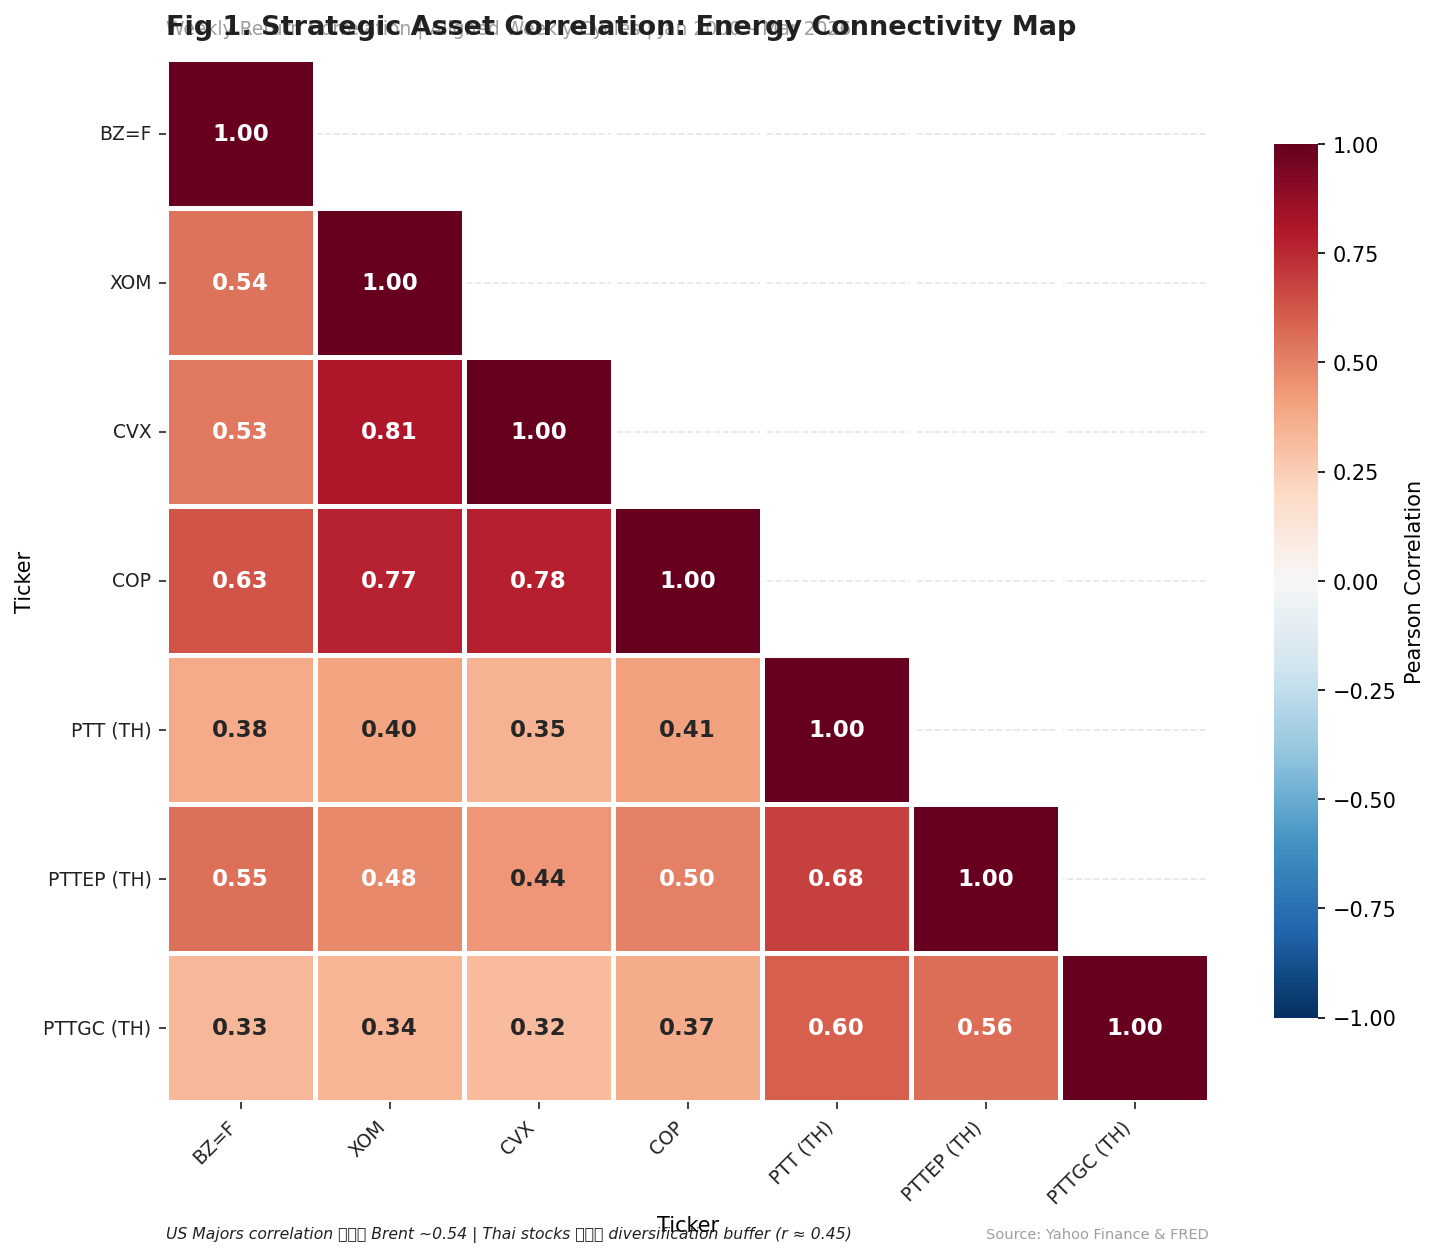

In [3]:
def fig_01_correlation_matrix(stocks):
    print("\n[Fig 1] Strategic Asset Correlation Matrix")
    df = stocks.copy()
    if 'Date' not in df.columns and df.index.name == 'Date':
        df = df.reset_index()
    elif 'Date' not in df.columns:
        raise KeyError("ไม่พบคอลัมน์ 'Date'")
    df['Date'] = pd.to_datetime(df['Date'])
    df['Aligned_Date'] = df['Date'] + pd.to_timedelta((7 - df['Date'].dt.dayofweek) % 7, unit='D')

    ordered_tickers = ["BZ=F", "XOM", "CVX", "COP", "PTT.BK", "PTTEP.BK", "PTTGC.BK"]
    close_wide = df.pivot_table(index='Aligned_Date', columns='Ticker', values='Close', aggfunc='mean')
    valid_tickers = [t for t in ordered_tickers if t in close_wide.columns]
    close_wide = close_wide[valid_tickers]

    weekly_rets = close_wide.pct_change().dropna(how="any")
    corr = weekly_rets.corr().round(2)
    corr[corr.abs() < 0.01] = 0

    fig, ax = plt.subplots(figsize=(10, 9), dpi=150)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                square=True, ax=ax, linewidths=1.5, vmin=-1, vmax=1,
                cbar_kws={"label": "Pearson Correlation", "shrink": 0.8},
                annot_kws={"size": 11, "weight": "bold"})

    clean_labels = [t.replace(".BK", " (TH)") if ".BK" in t else t for t in valid_tickers]
    ax.set_xticklabels(clean_labels, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(clean_labels, rotation=0, fontsize=10)

    style_ax(ax,
             title="Strategic Asset Correlation: Energy Connectivity Map",
             subtitle="Weekly Return Correlation | Aligned Weekly Cycles | Jan 2000 – Mar 2026",
             caption="US Majors correlation กับ Brent ~0.54 | Thai stocks ให้ diversification buffer (r ≈ 0.45)",
             fig_num=1)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    save_fig(fig, "01_correlation_matrix")
    plt.show()

fig_01_correlation_matrix(stocks)


#### 📖 Story: "แผนที่ความเชื่อมโยงของจักรวาลพลังงาน"

ลองจินตนาการว่าตลาดพลังงานคือเครือข่ายเมืองที่เชื่อมกันด้วยถนน — น้ำมันดิบ Brent คือเมืองหลวงที่ถนนทุกสายวิ่งเข้าหา กราฟ Correlation Matrix นี้เปิดเผยว่าหุ้นพลังงานสหรัฐฯ อย่าง XOM, CVX, COP เคลื่อนไหวเป็นกลุ่มก้อนแน่นหนา (r > 0.7 ระหว่างกัน) เหมือนเมืองที่อยู่ติดกัน — ถ้าฝนตกที่เมืองหนึ่ง เมืองข้างๆ ก็เปียกด้วย นั่นหมายความว่าการซื้อหุ้น US Energy หลายตัวพร้อมกัน **ไม่ได้ช่วยกระจายความเสี่ยงอย่างแท้จริง**

แต่เมื่อมองข้ามมาฝั่งไทย สถานการณ์เปลี่ยนไป PTT, PTTEP, PTTGC มี correlation กับกลุ่ม US อยู่ที่ระดับปานกลาง (~0.45) เหมือนเมืองคนละฝั่งแม่น้ำ — มีสะพานเชื่อมแต่ไม่ได้ติดกันสนิท ความแตกต่างนี้เกิดจากหลายปัจจัย ทั้งตลาดทุนที่แยกกัน อัตราแลกเปลี่ยน กฎระเบียบภายในประเทศ และโครงสร้างธุรกิจที่ต่างกัน (PTT มีทั้ง Upstream-Downstream ขณะที่ COP เป็น Pure-Play Upstream)

**Key Insights:**
- ถ้าต้องการ **กระจายความเสี่ยงจริงๆ** ต้องผสมหุ้นข้ามประเทศ (US + TH) ไม่ใช่ซื้อแต่หุ้น US หลายตัว
- Brent คือ "แกนกลาง" ที่เชื่อมทุกสินทรัพย์ → การติดตามราคาน้ำมันคือหน้าที่หลักของนักลงทุนพลังงาน
- ค่า Correlation ไม่คงที่ — มันจะ **พุ่งสูงขึ้นในช่วงวิกฤต** (correlation breakdown) ซึ่งเป็นจังหวะที่การกระจายความเสี่ยงล้มเหลวพอดี


### 📊 Fig 2. Oil Price Sensitivity Ranking — ใครไวต่อน้ำมันที่สุด?



[Fig 2] Oil-Stock Sensitivity Ranking
  Saved: outputs/figures\02_oil_stock_correlation.png


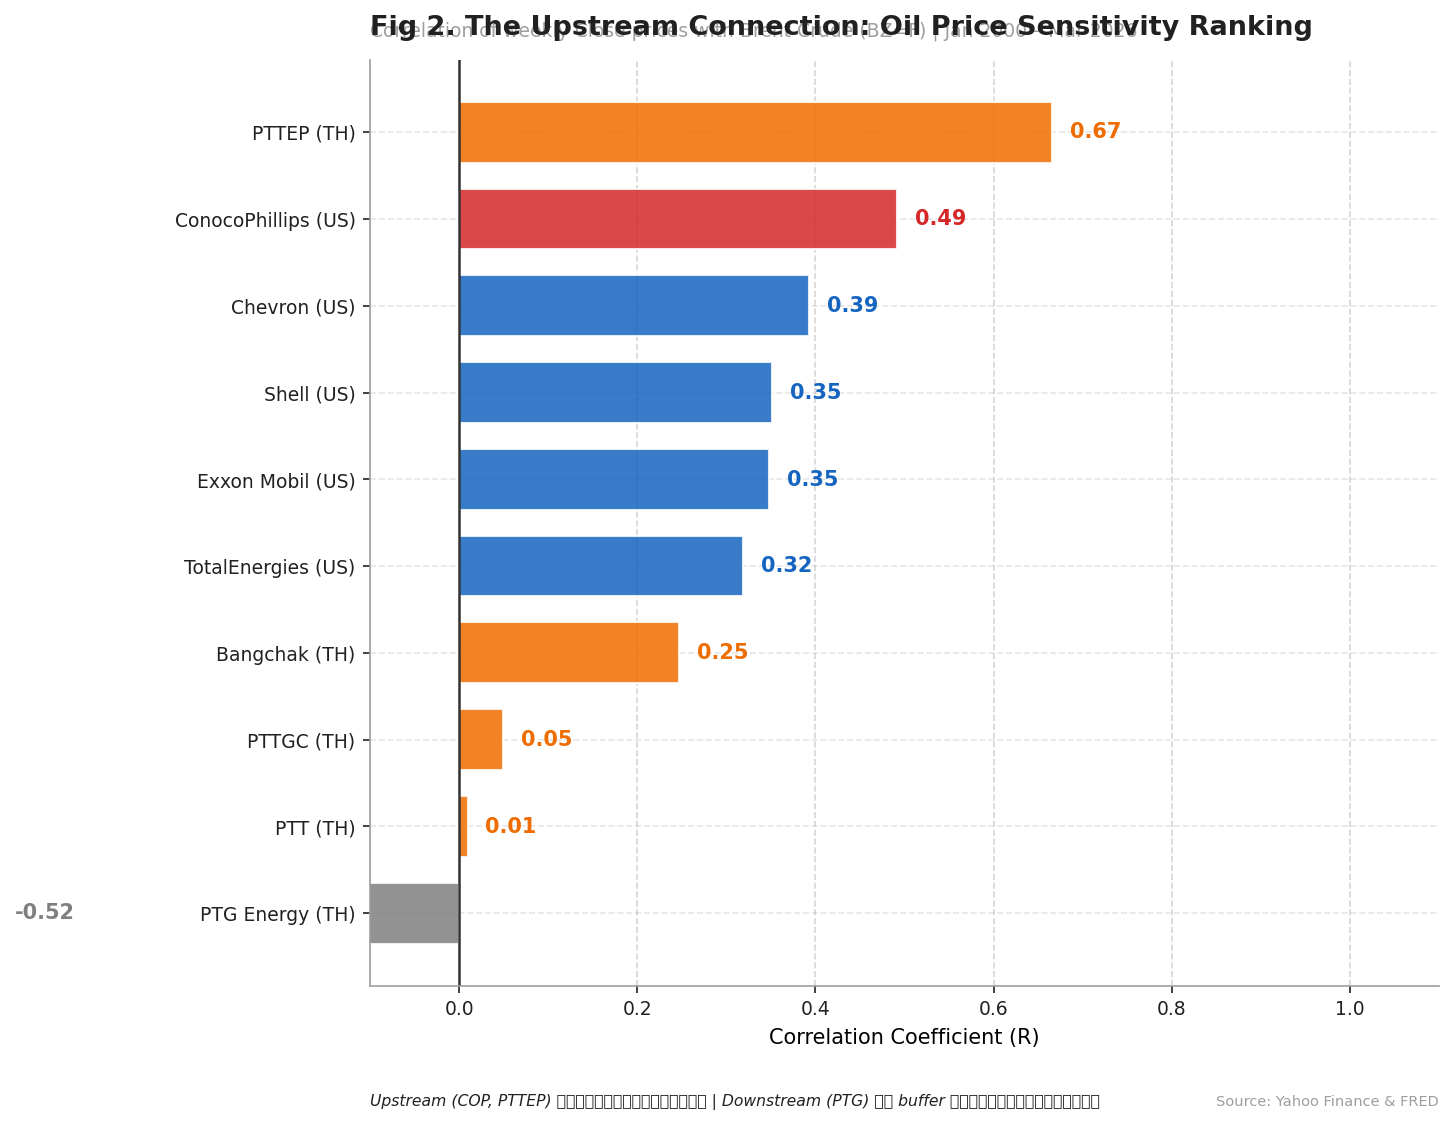

In [4]:
def fig_02_oil_sensitivity(stocks, fred):
    print("\n[Fig 2] Oil-Stock Sensitivity Ranking")
    oil = pivot_close(stocks, ["BZ=F"])
    stk = pivot_close(stocks, ALL_STOCKS)
    merged = oil.join(stk, how="outer").sort_index().ffill().dropna()
    corr = merged.corr()["BZ=F"].drop("BZ=F").sort_values(ascending=True)

    names_map = {
        'XOM': 'Exxon Mobil (US)', 'CVX': 'Chevron (US)', 'COP': 'ConocoPhillips (US)',
        'SHEL': 'Shell (US)', 'TTE': 'TotalEnergies (US)', 'PTT.BK': 'PTT (TH)',
        'PTTEP.BK': 'PTTEP (TH)', 'PTTGC.BK': 'PTTGC (TH)',
        'BCP.BK': 'Bangchak (TH)', 'PTG.BK': 'PTG Energy (TH)'
    }
    plot_labels = [names_map.get(t, t) for t in corr.index]

    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
    colors = []
    for t in corr.index:
        if t == 'COP': colors.append('#D62728')
        elif t == 'PTG.BK': colors.append('#7F7F7F')
        elif t in US_TICKERS: colors.append(C_BLUE)
        else: colors.append(C_ORANGE)

    bars = ax.barh(plot_labels, corr.values, color=colors, alpha=0.85, edgecolor="white", height=0.7)
    ax.set_xlim(-0.1, 1.1)
    ax.axvline(0, color='#333333', lw=1.2)
    ax.grid(axis='x', linestyle='--', alpha=0.4, color='#999999')
    for bar, val in zip(bars, corr.values):
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
                va='center', fontsize=10, fontweight='bold', color=colors[list(bars).index(bar)])

    style_ax(ax,
             title="The Upstream Connection: Oil Price Sensitivity Ranking",
             subtitle="Correlation of weekly Close prices with Brent Crude (BZ=F) | Jan 2000 – Mar 2026",
             caption="Upstream (COP, PTTEP) เคลื่อนตามน้ำมัน | Downstream (PTG) มี buffer จากการควบคุมราคา",
             fig_num=2)
    ax.set_xlabel("Correlation Coefficient (R)")
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    save_fig(fig, "02_oil_stock_correlation")
    plt.show()

fig_02_oil_sensitivity(stocks, fred)


#### 📖 Story: "ลำดับชั้นแห่งความไว — ใครคือทหารแนวหน้า?"

ในกองทัพพลังงาน ไม่ใช่ทุกหน่วยจะรับแรงกระแทกจากราคาน้ำมันเท่ากัน กราฟนี้จัดอันดับ "ความไวต่อน้ำมัน" (Oil Sensitivity) ของหุ้นพลังงาน 10 ตัว และเผยให้เห็นลำดับชั้นที่ชัดเจน — ConocoPhillips (COP) ยืนอยู่แถวหน้าสุดด้วย correlation สูงสุด เพราะเป็น Pure-Play Upstream ที่รายได้ผูกติดกับราคาน้ำมันโดยตรง ตามมาด้วย PTTEP ซึ่งเป็น Upstream ของฝั่งไทย ทั้งสองตัวนี้คือ "ทหารแนวหน้า" ที่ได้ประโยชน์เต็มๆ เมื่อน้ำมันขึ้น แต่ก็เจ็บหนักสุดเมื่อน้ำมันลง

ในทางตรงข้าม PTG Energy อยู่ท้ายแถวด้วย correlation ต่ำสุด สาเหตุไม่ใช่เพราะ PTG ไม่เกี่ยวกับพลังงาน แต่เป็นเพราะธุรกิจหลักคือปั๊มน้ำมันปลีก (Downstream Retail) ที่ราคาขายถูกควบคุมโดยภาครัฐไทย ทำให้ราคาหุ้นไม่ผันผวนตามราคาน้ำมันดิบโลกมากนัก Bangchak (BCP) ก็อยู่ในกลุ่มนี้ เพราะมีธุรกิจโรงกลั่นที่ทำหน้าที่เป็น "buffer" ตามธรรมชาติ

**Key Insights:**
- **เลือกหุ้นให้ตรงกับ View:** ถ้าเชื่อว่าน้ำมันจะขึ้น → COP/PTTEP (High Sensitivity) | ถ้าต้องการความมั่นคง → PTG/BCP (Low Sensitivity)
- Upstream vs Downstream ไม่ใช่แค่โมเดลธุรกิจ แต่คือ **ระดับ Beta ที่คุณเลือกรับ**
- หุ้นที่ Correlation ต่ำ (PTG, BCP) เหมาะเป็น "ส่วนผสมป้องกัน" ในพอร์ตที่เน้น Upstream


### 📊 Fig 3. Brent vs WTI — เข้าใจโครงสร้างตลาดน้ำมันโลก



[Fig 3] Brent-WTI Strategic Spread
   Date range: 2007-07-30 → 2026-03-09
   Rows: 971 | Avg Spread: $5.31
  Saved: outputs/figures\03_brent_wti_spread.png


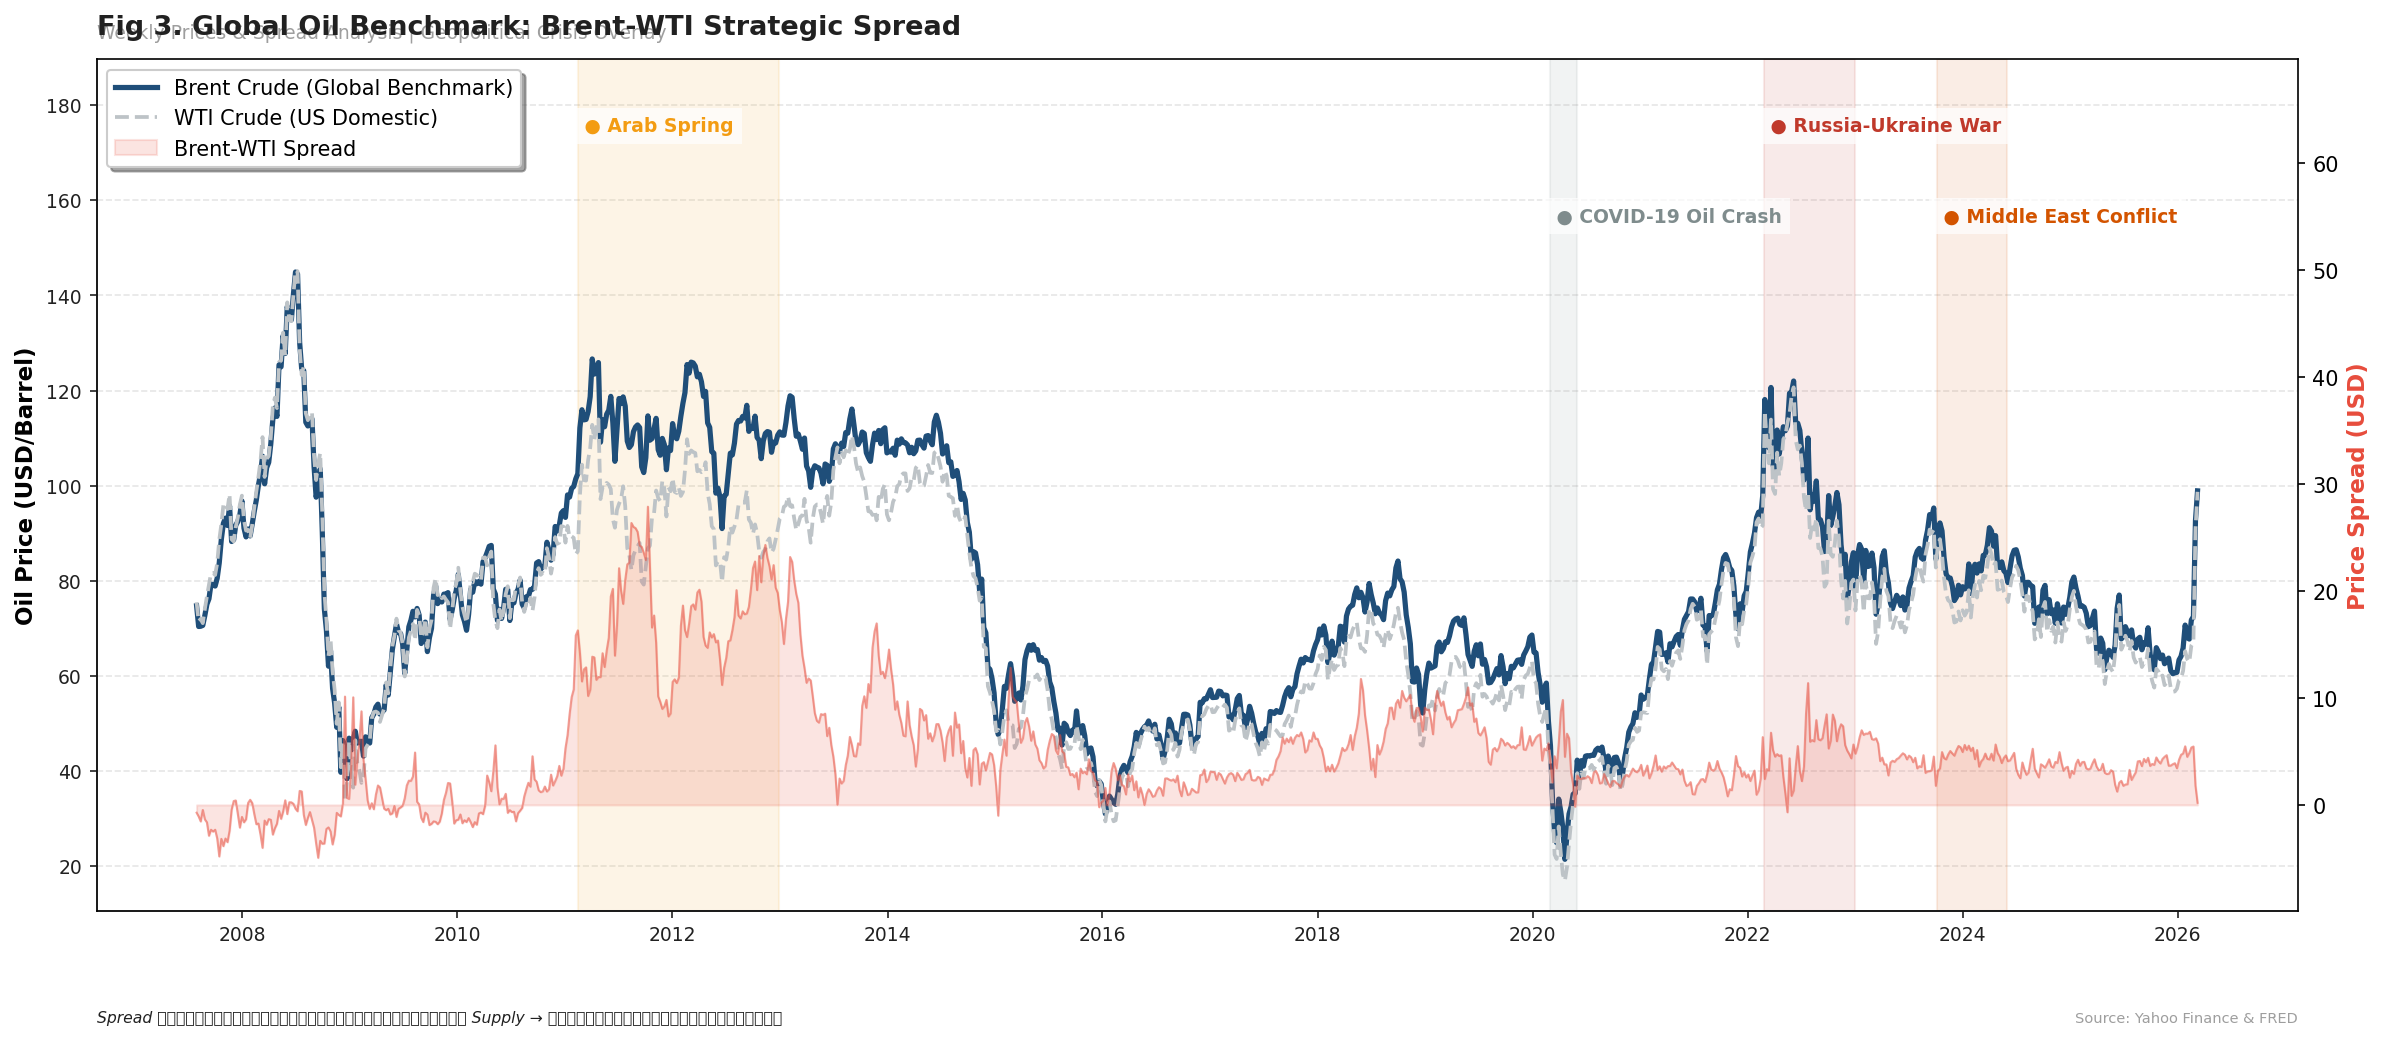

In [5]:
def fig_03_brent_wti_spread(stocks_df):
    print("\n[Fig 3] Brent-WTI Strategic Spread")

    try:
        # ── FIX: reset_index เพื่อให้มีคอลัมน์ 'Date' สำหรับ pivot ──
        df = stocks_df.copy()
        if 'Date' not in df.columns:
            df = df.reset_index()           # Date กลับมาเป็น column
        df['Date'] = pd.to_datetime(df['Date'])

        tickers = ["BZ=F", "CL=F"]
        sub = df[df['Ticker'].isin(tickers)]

        # ใช้ pivot_table แทน pivot เพื่อรองรับ duplicate dates
        prices = sub.pivot_table(index='Date', columns='Ticker', values='Close', aggfunc='mean')

        # ── ตรวจสอบว่ามี Ticker ครบ ──
        missing = [t for t in tickers if t not in prices.columns]
        if missing:
            print(f"⚠️ Missing tickers in data: {missing}")
            print(f"   Available tickers: {df['Ticker'].unique()[:15]}")
            return

        prices.columns = ['Brent', 'WTI']
        prices = prices.sort_index().dropna()
        prices['Spread'] = prices['Brent'] - prices['WTI']

        print(f"   Date range: {prices.index.min().date()} → {prices.index.max().date()}")
        print(f"   Rows: {len(prices):,} | Avg Spread: ${prices['Spread'].mean():.2f}")

        fig, ax1 = plt.subplots(figsize=(16, 7), dpi=150)

        # ── แกนซ้าย: ราคาจริง ──
        ln1 = ax1.plot(prices.index, prices['Brent'], color='#1F4E79', lw=2.5,
                       label="Brent Crude (Global Benchmark)")
        ln2 = ax1.plot(prices.index, prices['WTI'], color='#BDC3C7', lw=1.8, ls='--',
                       label="WTI Crude (US Domestic)")
        ax1.set_ylabel("Oil Price (USD/Barrel)", fontweight='bold', fontsize=11)
        ax1.set_ylim(ax1.get_ylim()[0], ax1.get_ylim()[1] * 1.25)

        # ── แกนขวา: Spread ──
        ax2 = ax1.twinx()
        ax2.fill_between(prices.index, 0, prices['Spread'],
                         color='#E74C3C', alpha=0.15, label="Brent-WTI Spread")
        ax2.plot(prices.index, prices['Spread'], color='#E74C3C', lw=1, alpha=0.5)
        ax2.set_ylabel("Price Spread (USD)", color='#E74C3C', fontweight='bold', fontsize=11)
        ax2.set_ylim(prices['Spread'].min() - 5, prices['Spread'].max() * 2.5)

        # ── Crisis Zones ──
        crisis_zones = [
            ("2011-02-15", "2012-12-30", "Arab Spring", "#F39C12", 0.92),
            ("2020-03-01", "2020-06-01", "COVID-19 Oil Crash", "#7F8C8D", 0.82),
            ("2022-02-24", "2022-12-31", "Russia-Ukraine War", "#C0392B", 0.92),
            ("2023-10-07", "2024-06-01", "Middle East Conflict", "#D35400", 0.82)
        ]
        for start, end, label, color, v_pos in crisis_zones:
            s, e = pd.to_datetime(start), pd.to_datetime(end)
            if s >= prices.index.min() and s <= prices.index.max():
                ax1.axvspan(s, e, color=color, alpha=0.1, zorder=1)
                ax1.text(s, ax1.get_ylim()[1] * v_pos, f" ● {label}", color=color,
                         fontsize=9, fontweight='bold',
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        # ── Legend ──
        lines = ln1 + ln2
        labels_leg = [l.get_label() for l in lines] + ["Brent-WTI Spread"]
        ax1.legend(lines + [plt.Rectangle((0,0),1,1, color='#E74C3C', alpha=0.15)],
                   labels_leg, loc="upper left", frameon=True, shadow=True)

        style_ax(ax1,
                 title="Global Oil Benchmark: Brent-WTI Strategic Spread",
                 subtitle="Weekly Prices & Spread Analysis | Geopolitical Crisis Overlay",
                 caption="Spread ถ่างกว้างทุกครั้งที่เกิดวิกฤตด้าน Supply → น้ำมันโลกตึงตัวกว่าสหรัฐฯ",
                 fig_num=3)

        plt.tight_layout()
        save_fig(fig, "03_brent_wti_spread")
        plt.show()

    except Exception as e:
        import traceback
        print(f"❌ Error in Fig 3: {e}")
        traceback.print_exc()

fig_03_brent_wti_spread(stocks)


#### 📖 Story: "สองพี่น้องที่ไม่เคยเท่าเทียมกัน — Brent กับ WTI"

น้ำมันดิบมีสองเกณฑ์มาตรฐานหลักของโลก — Brent (ราคาอ้างอิงของตลาดโลก ซื้อขายที่ลอนดอน) และ WTI (ราคาอ้างอิงของสหรัฐฯ ส่งมอบที่ Cushing, Oklahoma) ทั้งสองราคาเคลื่อนไหวไปในทิศทางเดียวกันเกือบตลอด แต่ "ส่วนต่าง" หรือ Spread ระหว่างทั้งสองคือสิ่งที่นักลงทุนมืออาชีพจับตาดู เพราะมันบอกเล่าเรื่องราวเกี่ยวกับ **ดุลอุปสงค์-อุปทานของโลก** ได้อย่างแม่นยำ

ทุกครั้งที่เกิดวิกฤตด้านอุปทาน (Supply Shock) เช่น Arab Spring, สงครามรัสเซีย-ยูเครน, หรือความขัดแย้งตะวันออกกลาง — Spread จะ "ถ่างออก" อย่างรวดเร็ว เพราะน้ำมันในตลาดโลก (Brent) ขาดแคลนมากกว่าในสหรัฐฯ (WTI) ที่มี Shale Oil เป็นแหล่งสำรองภายในประเทศ ปรากฏการณ์นี้เหมือนสัญญาณไฟเตือน — เมื่อ Spread ถ่างเกิน $10 มักเป็นสัญญาณว่าหุ้น Upstream กำลังจะ rally ตาม

**Key Insights:**
- **Spread ถ่าง = Supply Crisis** → โอกาสซื้อหุ้น Upstream (COP, PTTEP) ที่ได้ประโยชน์จากราคาน้ำมันโลกที่สูงกว่า
- **Spread แคบ = ตลาดสมดุล** → ช่วงที่ Downstream (โรงกลั่น, ปั๊มน้ำมัน) ได้เปรียบเพราะ margin คงที่
- COVID-19 เป็นวิกฤตที่ WTI ติดลบชั่วครู่ (ปี 2020) — เหตุการณ์หายากที่พิสูจน์ว่า **ถังเก็บน้ำมันก็เต็มได้** เมื่อ Demand หายไปพร้อมกันทั้งโลก


---
# 🌊 ACT 2: THE MACRO FORCES — แรงขับเคลื่อนมหภาค
### "น้ำมันไม่ได้ขึ้นลงเองตามใจ — มีแรงมหภาค 3 ตัวกำหนดชะตา"

บทนี้จะเผยว่าหุ้นพลังงานถูกขับเคลื่อนด้วย: **เงินเฟ้อ** (Inflation Hedge), **ค่าเงินดอลลาร์** (USD Inverse), และ **ภาคการผลิตจริง** (Industrial Output)


### 📊 Fig 4. Energy = เกราะป้องกันเงินเฟ้อ?



[Fig 4] Energy Inflation Hedge Analysis
  Saved: outputs/figures\04_inflation_hedge.png


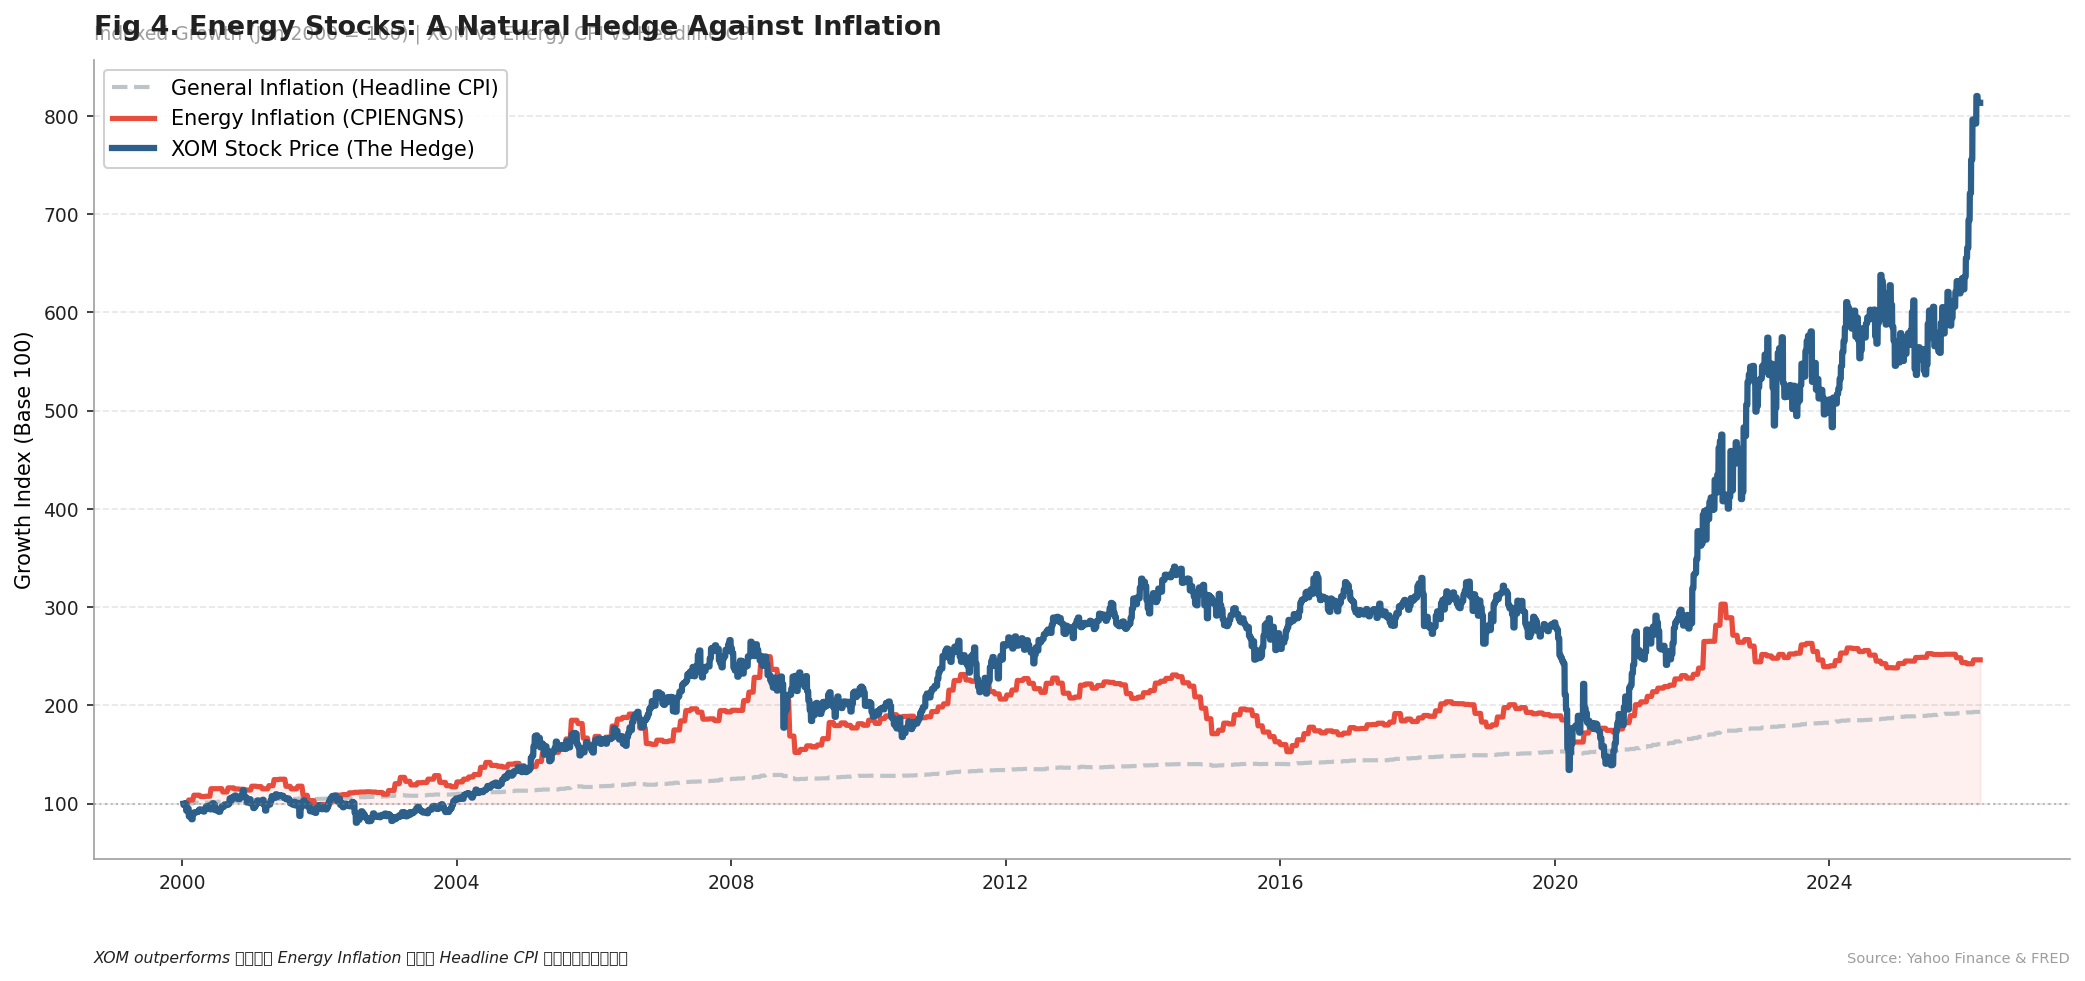

In [6]:
def fig_04_inflation_hedge(stocks, fred):
    print("\n[Fig 4] Energy Inflation Hedge Analysis")
    def safe_prepare(df):
        df_copy = df.copy()
        if 'Date' in df_copy.columns:
            df_copy['Date'] = pd.to_datetime(df_copy['Date'])
            df_copy = df_copy.set_index('Date')
        return df_copy
    try:
        fred_proc = safe_prepare(fred)
        cpi_data = fred_proc[["CPIENGNS", "CPIAUCSL"]].dropna()
        xom_raw = stocks[stocks['Ticker'] == 'XOM'].copy()
        xom_proc = safe_prepare(xom_raw)
        xom_close = xom_proc[['Close']]
        if isinstance(xom_close.columns, pd.MultiIndex):
            xom_close.columns = xom_close.columns.get_level_values(0)
        merged_raw = cpi_data.join(xom_close, how="outer").sort_index().ffill().dropna()
        merged_raw.columns = ['Energy_CPI', 'Headline_CPI', 'XOM_Price']
        if merged_raw.empty: return
        merged = (merged_raw / merged_raw.iloc[0]) * 100
        fig, ax = plt.subplots(figsize=(14, 7), dpi=150)
        ax.fill_between(merged.index, 100, merged["Energy_CPI"], alpha=0.08, color='#E74C3C')
        ax.plot(merged.index, merged["Headline_CPI"], color='#BDC3C7', lw=2, ls='--', label="General Inflation (Headline CPI)")
        ax.plot(merged.index, merged["Energy_CPI"], color='#E74C3C', lw=2.5, label="Energy Inflation (CPIENGNS)")
        ax.plot(merged.index, merged["XOM_Price"], color='#2C5F8A', lw=3, label="XOM Stock Price (The Hedge)")
        ax.axhline(100, color='grey', ls=':', lw=1, alpha=0.5)
        style_ax(ax, title="Energy Stocks: A Natural Hedge Against Inflation",
                 subtitle="Indexed Growth (Jan 2000 = 100) | XOM vs Energy CPI vs Headline CPI",
                 caption="XOM outperforms ทั้ง Energy Inflation และ Headline CPI ในระยะยาว", fig_num=4)
        ax.set_ylabel("Growth Index (Base 100)")
        ax.legend(loc="upper left", frameon=True, facecolor='white', framealpha=0.9)
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        save_fig(fig, "04_inflation_hedge")
        plt.show()
    except Exception as e:
        print(f"❌ Error: {e}")

fig_04_inflation_hedge(stocks, fred)


#### 📖 Story: "เมื่อของแพงขึ้น — หุ้นพลังงานแพงขึ้นเร็วกว่า"

หนึ่งในคำถามคลาสสิกของนักลงทุนคือ "ถือสินทรัพย์อะไรดีในภาวะเงินเฟ้อ?" — คำตอบจากข้อมูล 26 ปีคือหุ้นพลังงานคุณภาพอย่าง Exxon Mobil (XOM) กราฟนี้เปรียบเทียบการเติบโตของ 3 สิ่ง: เงินเฟ้อทั่วไป (Headline CPI), เงินเฟ้อพลังงาน (Energy CPI), และราคาหุ้น XOM — ทั้งหมดปรับฐานที่ 100 เพื่อดูว่าใครโตเร็วกว่ากัน ผลลัพธ์ชัดเจน: XOM ทิ้งห่างทั้งสองดัชนีเงินเฟ้ออย่างมีนัยสำคัญ

เหตุผลเชิงโครงสร้างคือ — เมื่อราคาพลังงานแพงขึ้น (Energy CPI ↑) บริษัทน้ำมันได้กำไรเพิ่มโดยตรง เพราะรายได้ผูกกับราคาน้ำมัน แต่ต้นทุนการผลิตไม่ได้เพิ่มในสัดส่วนเดียวกัน ทำให้ Profit Margin ขยายตัวแบบ "Leveraged" ยิ่ง Inflation สูง ยิ่งได้ประโยชน์ นี่คือเหตุผลที่ Warren Buffett เลือกลงทุนใน Chevron และ Occidental Petroleum ในช่วงที่เงินเฟ้อพุ่งสูงปี 2022

**Key Insights:**
- หุ้นพลังงาน Upstream คือ **Inflation Hedge ที่แท้จริง** — ไม่ใช่แค่รักษามูลค่า แต่ "ชนะ" เงินเฟ้อ
- ในภาวะ Stagflation (เงินเฟ้อสูง + เศรษฐกิจชะลอ) หุ้นพลังงานเป็นหนึ่งใน Asset Class ที่ดีที่สุด
- แต่ต้องเลือกหุ้นที่มี **ต้นทุนการผลิตต่ำ** (Low Breakeven) จึงจะเป็น Inflation Hedge ที่มีประสิทธิภาพ


### 📊 Fig 5. ดอลลาร์แข็ง = ศัตรูเงียบของหุ้นพลังงาน



[Fig 5] USD vs Energy: The Inverse Relationship
  Saved: outputs/figures\05_usd_vs_energy.png


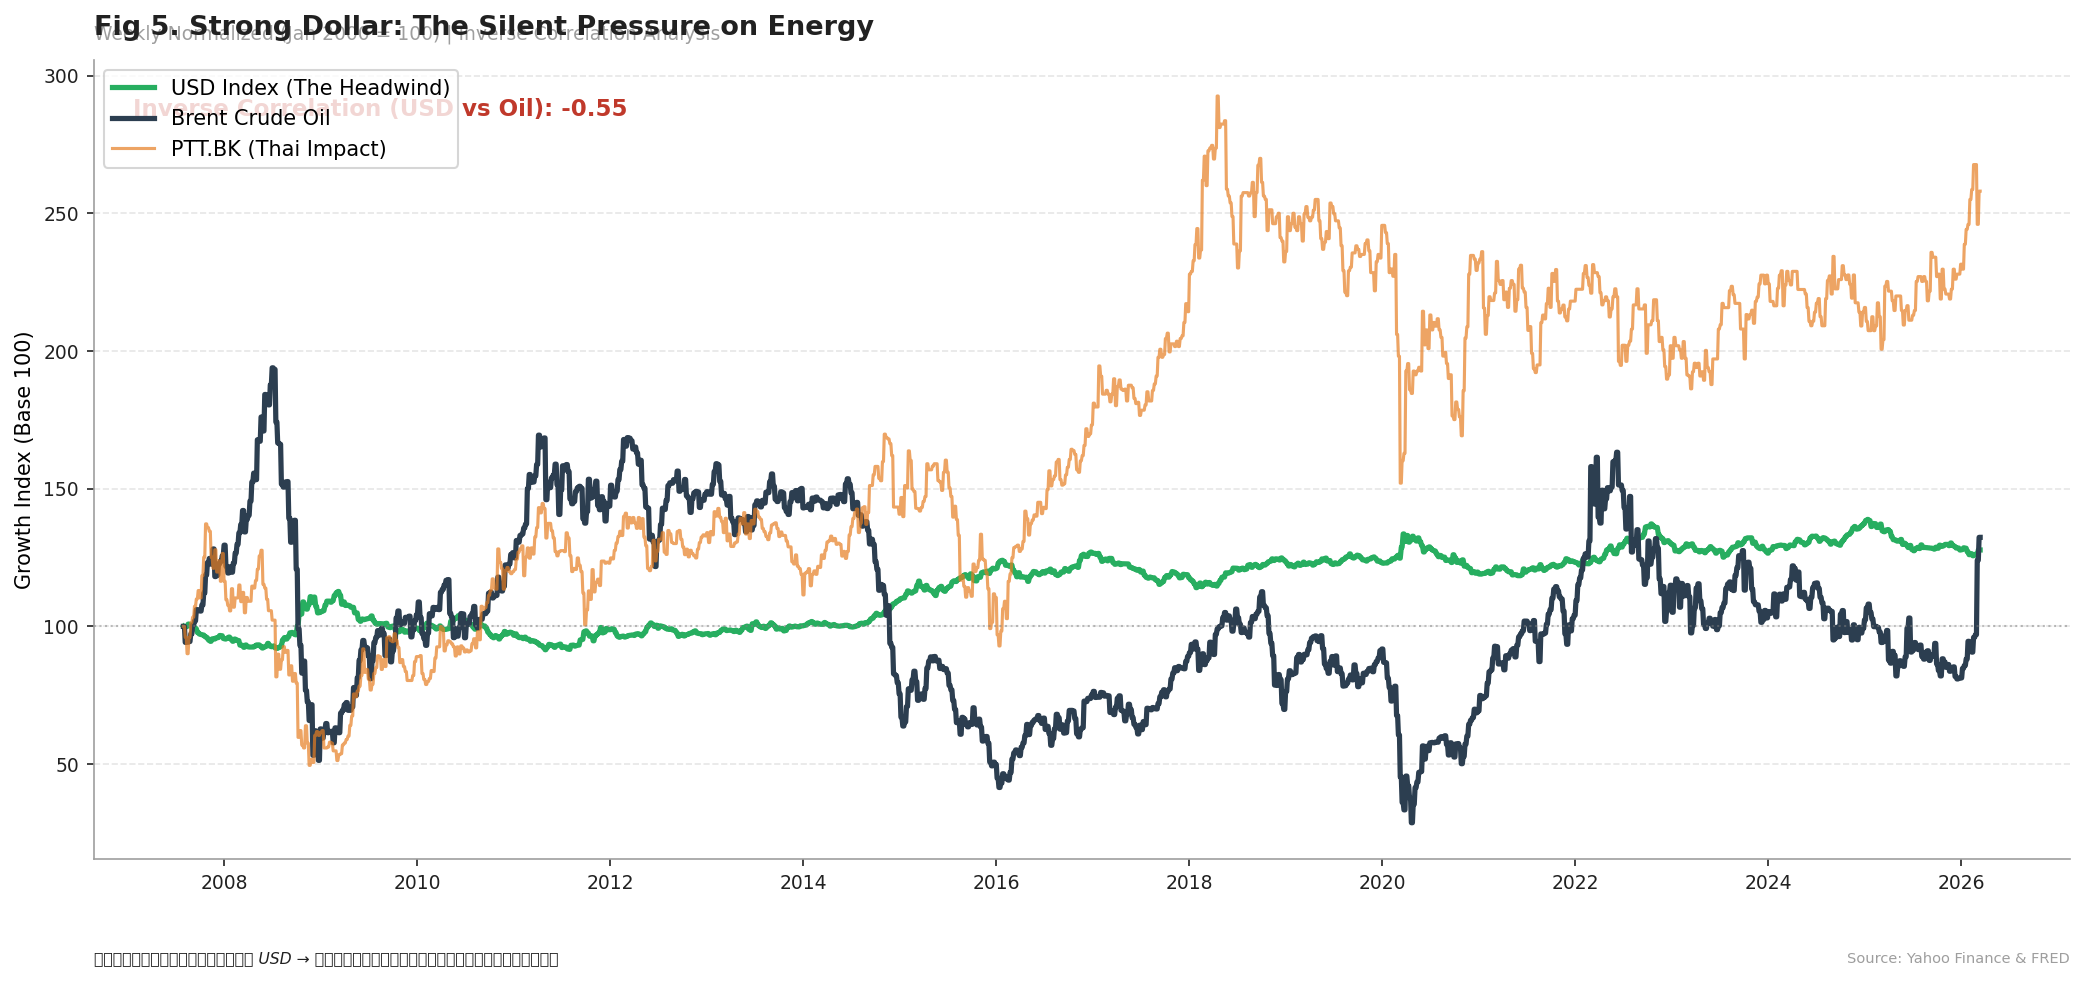

In [7]:
def fig_05_usd_inverse(stocks, fred):
    print("\n[Fig 5] USD vs Energy: The Inverse Relationship")
    def get_clean_series(df, ticker_name, is_fred=False):
        data = df.copy()
        if 'Date' in data.columns:
            data['Date'] = pd.to_datetime(data['Date'])
            data = data.set_index('Date')
        elif not isinstance(data.index, pd.DatetimeIndex):
            data.index = pd.to_datetime(data.index)
        if not is_fred:
            data = data[data['Ticker'] == ticker_name]
        col_to_use = 'DTWEXBGS' if is_fred else 'Close'
        if col_to_use in data.columns:
            target_data = data[[col_to_use]].copy()
            if isinstance(target_data.columns, pd.MultiIndex):
                target_data.columns = target_data.columns.get_level_values(0)
            target_data.columns = [ticker_name]
            return target_data
        return pd.DataFrame()
    try:
        usd_idx = get_clean_series(fred, 'USD_Index', is_fred=True)
        oil_price = get_clean_series(stocks, 'BZ=F')
        ptt_stock = get_clean_series(stocks, 'PTT.BK')
        merged = usd_idx.join(oil_price, how="outer").join(ptt_stock, how="outer")
        merged = merged.sort_index().ffill().dropna()
        if merged.empty: return
        norm = (merged / merged.iloc[0]) * 100
        fig, ax = plt.subplots(figsize=(14, 7), dpi=150)
        ax.plot(norm.index, norm["USD_Index"], color='#27AE60', lw=2.5, label="USD Index (The Headwind)")
        ax.plot(norm.index, norm["BZ=F"], color='#2C3E50', lw=2.5, label="Brent Crude Oil")
        ax.plot(norm.index, norm["PTT.BK"], color='#E67E22', lw=1.5, alpha=0.7, label="PTT.BK (Thai Impact)")
        corr_val = merged['USD_Index'].corr(merged['BZ=F'])
        ax.text(0.02, 0.93, f"Inverse Correlation (USD vs Oil): {corr_val:.2f}",
                transform=ax.transAxes, fontsize=11, fontweight='bold',
                color='#C0392B', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        ax.axhline(100, color='grey', ls=':', lw=1, alpha=0.5)
        style_ax(ax, title="Strong Dollar: The Silent Pressure on Energy",
                 subtitle="Weekly Normalized (Jan 2000 = 100) | Inverse Correlation Analysis",
                 caption="น้ำมันซื้อขายด้วย USD → ดอลลาร์แข็งกดราคาน้ำมันโลก", fig_num=5)
        ax.set_ylabel("Growth Index (Base 100)")
        ax.legend(loc="upper left", frameon=True, facecolor='white')
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        save_fig(fig, "05_usd_vs_energy")
        plt.show()
    except Exception as e:
        print(f"❌ Error: {e}")

fig_05_usd_inverse(stocks, fred)


#### 📖 Story: "ศัตรูที่มองไม่เห็น — เมื่อดอลลาร์กดคอน้ำมัน"

นักลงทุนพลังงานส่วนใหญ่จับตาดูราคาน้ำมัน, ข่าว OPEC, สงคราม — แต่มักลืม "ศัตรูเงียบ" ตัวหนึ่งที่มีพลังมหาศาล นั่นคือค่าเงินดอลลาร์สหรัฐ เนื่องจากน้ำมันดิบซื้อขายด้วยสกุล USD ทั่วโลก เมื่อดอลลาร์แข็งค่า → ประเทศผู้นำเข้าน้ำมัน (จีน, อินเดีย, ยุโรป) ต้องจ่ายแพงขึ้นในสกุลเงินของตัวเอง → ความต้องการซื้อลดลง → ราคาน้ำมันตก → หุ้นพลังงานร่วง กราฟนี้แสดง Inverse Correlation ที่ชัดเจนระหว่าง USD Index กับ Brent Crude

ที่น่าสนใจคือผลกระทบต่อ PTT.BK (หุ้นไทย) — PTT โดนกระทบ "สองเด้ง" เมื่อดอลลาร์แข็ง เพราะนอกจากราคาน้ำมันจะลดลงแล้ว ค่าเงินบาทก็มักอ่อนค่าเทียบกับดอลลาร์ ทำให้ต้นทุนนำเข้าสูงขึ้น ขณะที่ราคาขายในประเทศถูกควบคุม สิ่งนี้ทำให้นักลงทุนหุ้นพลังงานไทยต้องติดตาม DXY (Dollar Index) เป็นสัญญาณเตือนอีกหนึ่งตัว

**Key Insights:**
- **USD ↑ → Oil ↓ → Energy Stocks ↓** — กลไกผกผันที่ต้องจำ
- เมื่อ Fed ขึ้นดอกเบี้ย → ดอลลาร์แข็ง → **ระวังหุ้นพลังงาน** (Headwind)
- เมื่อ Fed ลดดอกเบี้ย + ดอลลาร์อ่อน → เป็น **จังหวะทองในการเข้าซื้อหุ้นพลังงาน** (Tailwind)


### 📊 Fig 6. เศรษฐกิจจริง × ราคาน้ำมัน — สองแรงที่ต้องดูคู่กัน



[Fig 6] Real Economy: Industrial Production vs Oil Price
  Saved: outputs/figures\06_industrial_vs_oil.png


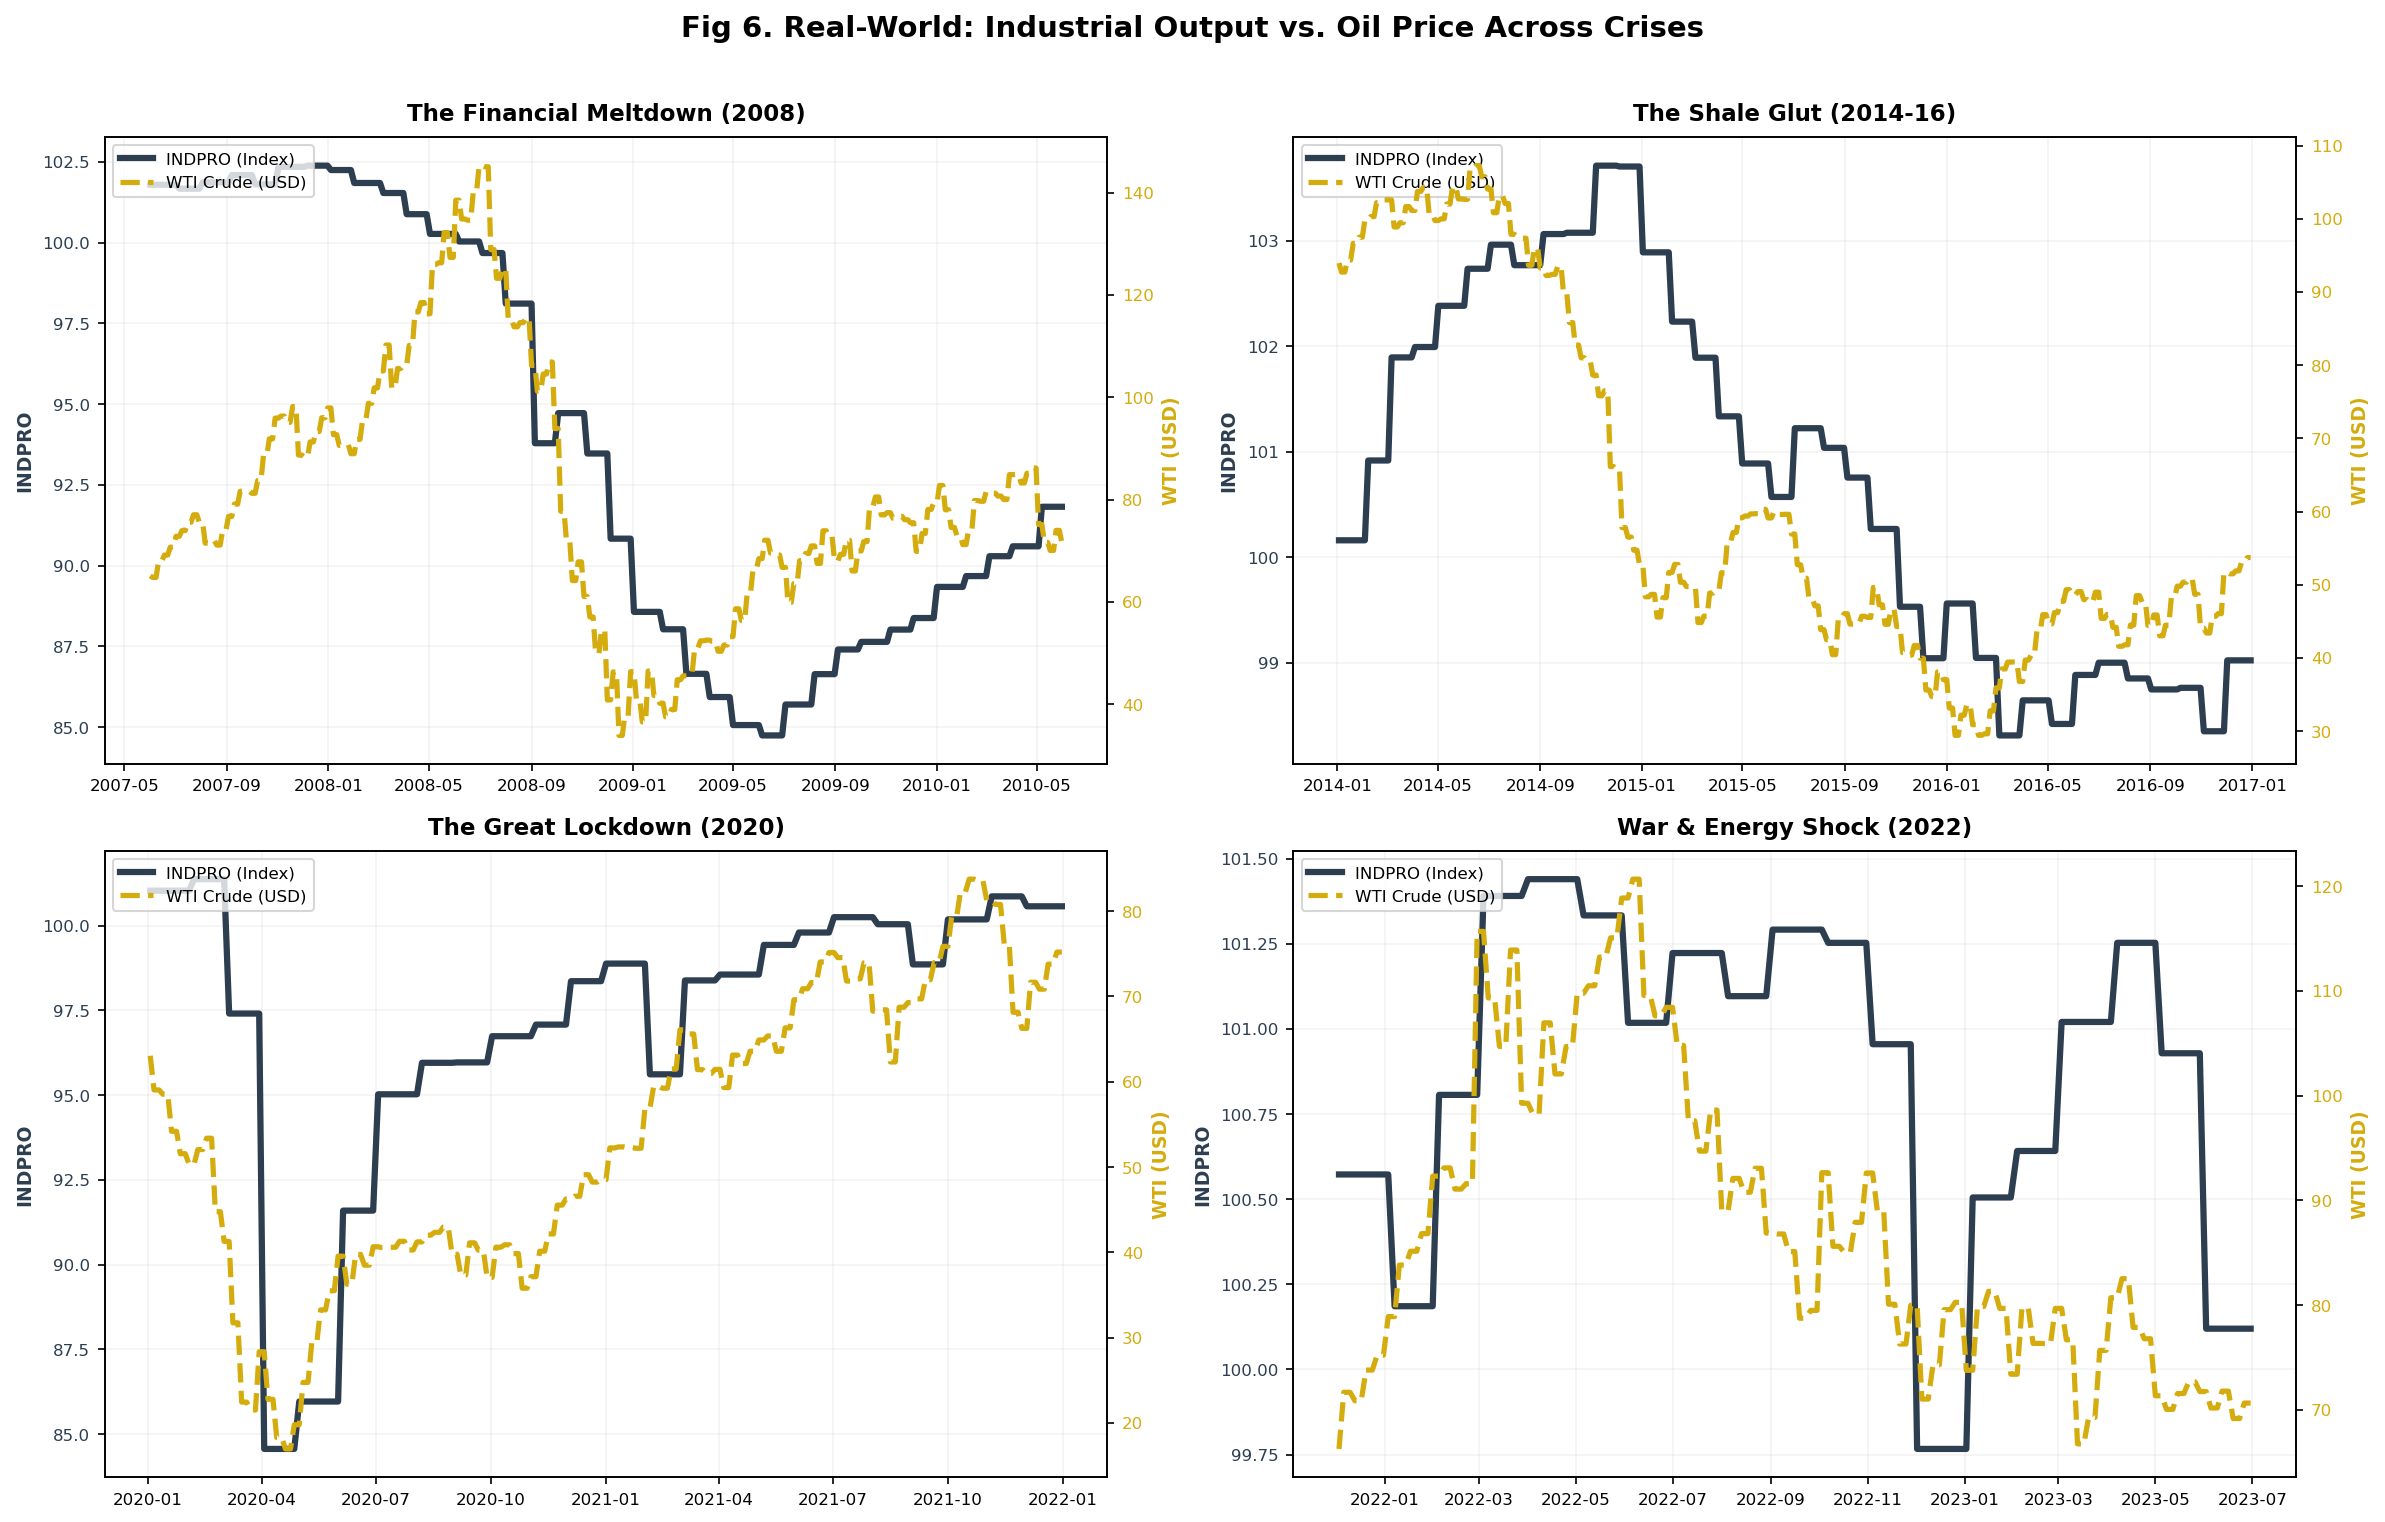

In [8]:
def fig_06_industrial_vs_oil(stocks_df, fred_df):
    print("\n[Fig 6] Real Economy: Industrial Production vs Oil Price")
    try:
        oil = stocks_df[stocks_df['Ticker'] == 'CL=F'].copy()
        if 'Date' not in oil.columns: oil = oil.reset_index()
        oil = oil[['Date', 'Close']].rename(columns={'Close': 'WTI'})

        fred_c = fred_df.copy()
        if 'Date' not in fred_c.columns: fred_c = fred_c.reset_index()
        indpro = fred_c[['Date', 'INDPRO']].copy()

        oil['Date'] = pd.to_datetime(oil['Date'])
        indpro['Date'] = pd.to_datetime(indpro['Date'])
        oil = oil.set_index('Date')
        indpro = indpro.set_index('Date')
        merged = indpro.join(oil, how='outer').sort_index().ffill().dropna()

        crises = [
            ("2007-06-01", "2010-06-01", "The Financial Meltdown (2008)"),
            ("2014-01-01", "2016-12-31", "The Shale Glut (2014-16)"),
            ("2020-01-01", "2021-12-31", "The Great Lockdown (2020)"),
            ("2021-12-01", "2023-06-30", "War & Energy Shock (2022)")
        ]
        fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=150)
        axes = axes.flatten()
        for i, (start, end, title) in enumerate(crises):
            ax1 = axes[i]
            sub = merged.loc[start:end].copy()
            if sub.empty: continue
            ax1.plot(sub.index, sub['INDPRO'], color='#2C3E50', lw=3, label='INDPRO (Index)')
            ax1.set_ylabel('INDPRO', color='#2C3E50', fontsize=9, fontweight='bold')
            ax1.tick_params(axis='y', labelcolor='#2C3E50', labelsize=8)
            ax2 = ax1.twinx()
            ax2.plot(sub.index, sub['WTI'], color='#D4AC0D', lw=2.5, ls='--', label='WTI Crude (USD)')
            ax2.set_ylabel('WTI (USD)', color='#D4AC0D', fontsize=9, fontweight='bold')
            ax2.tick_params(axis='y', labelcolor='#D4AC0D', labelsize=8)
            ax1.set_title(title, fontsize=11, fontweight='bold', pad=8)
            ax1.grid(True, alpha=0.15)
            ax1.tick_params(axis='x', labelsize=8)
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8, frameon=True)
        plt.suptitle("Fig 6. Real-World: Industrial Output vs. Oil Price Across Crises",
                     fontsize=14, fontweight='bold', y=1.01)
        plt.tight_layout()
        save_fig(fig, "06_industrial_vs_oil")
        plt.show()
    except Exception as e:
        print(f"❌ Error: {e}")

fig_06_industrial_vs_oil(stocks, fred)


#### 📖 Story: "เครื่องจักรหยุดเดิน — น้ำมันก็ไม่มีใครซื้อ"

ราคาน้ำมันไม่ได้ถูกกำหนดแค่โดยสงครามหรือ OPEC — ปัจจัยพื้นฐานที่สุดคือ "ความต้องการใช้จริง" ซึ่งวัดได้จากดัชนีผลผลิตอุตสาหกรรม (Industrial Production Index - INDPRO) กราฟ 4 ช่องนี้เปรียบเทียบการเคลื่อนไหวของ INDPRO กับราคา WTI ในแต่ละวิกฤต และเผยให้เห็น pattern ที่น่าทึ่ง — ทุกครั้งที่ INDPRO ร่วง น้ำมันร่วงตาม (หรือบางครั้งร่วงก่อน)

วิกฤต COVID-19 เป็นตัวอย่างที่ชัดเจนที่สุด: โรงงานปิด การบินหยุด รถยนต์จอดนิ่ง → ความต้องการน้ำมันหายไปชั่วข้ามคืน → WTI ติดลบเป็นครั้งแรกในประวัติศาสตร์ นี่คือ "Rare Double Shock" ที่ทั้ง Supply (OPEC ลดการผลิตไม่ทัน) และ Demand (Lockdown) ถูกทำลายพร้อมกัน ในทางตรงข้าม สงครามรัสเซีย-ยูเครน 2022 เป็น Supply Shock เพียงอย่างเดียว (INDPRO ยังเติบโต) ทำให้ราคาน้ำมันพุ่งสูงแต่เศรษฐกิจยังไม่ล่ม

**Key Insights:**
- ติดตาม **PMI / INDPRO** เป็น Leading Indicator ก่อนตัดสินใจลงทุน → INDPRO ลด = ระวัง Demand Shock
- วิกฤตแบบ Supply Shock (สงคราม) = โอกาสสำหรับ Upstream | วิกฤตแบบ Demand Shock (COVID) = อันตรายสำหรับทุกกลุ่ม
- ให้สังเกตว่า INDPRO ฟื้นตัวก่อนราคาน้ำมันทุกครั้ง → สัญญาณ "ภาคการผลิตกลับมา" คือจังหวะเข้าซื้อ


---
# 🔥 ACT 3: THE CRUCIBLE — ไฟทดสอบ 26 ปี
### "วิกฤตคือห้องทดลองที่ดีที่สุดของนักลงทุน"

ตลอด 26 ปี (2000–2026) หุ้นพลังงานผ่านวิกฤตมาแล้ว 6 ครั้ง: Dot-com → GFC → Shale Glut → COVID-19 → Russia-Ukraine → Iran Crisis — บทนี้จะเปิดเผย **ภาพรวมการเติบโต** ท่ามกลางวิกฤต, **ความกลัวเป็นสัญญาณนำ** (VIX), และ **กายวิภาคความเสี่ยง** ในแต่ละยุค


### 📊 Fig 7. 26 ปีของหุ้นพลังงาน — Survival of the Fittest



[Fig 7] 26-Year Indexed Price Evolution
  Saved: outputs/figures\07_26yr_price_evolution.png


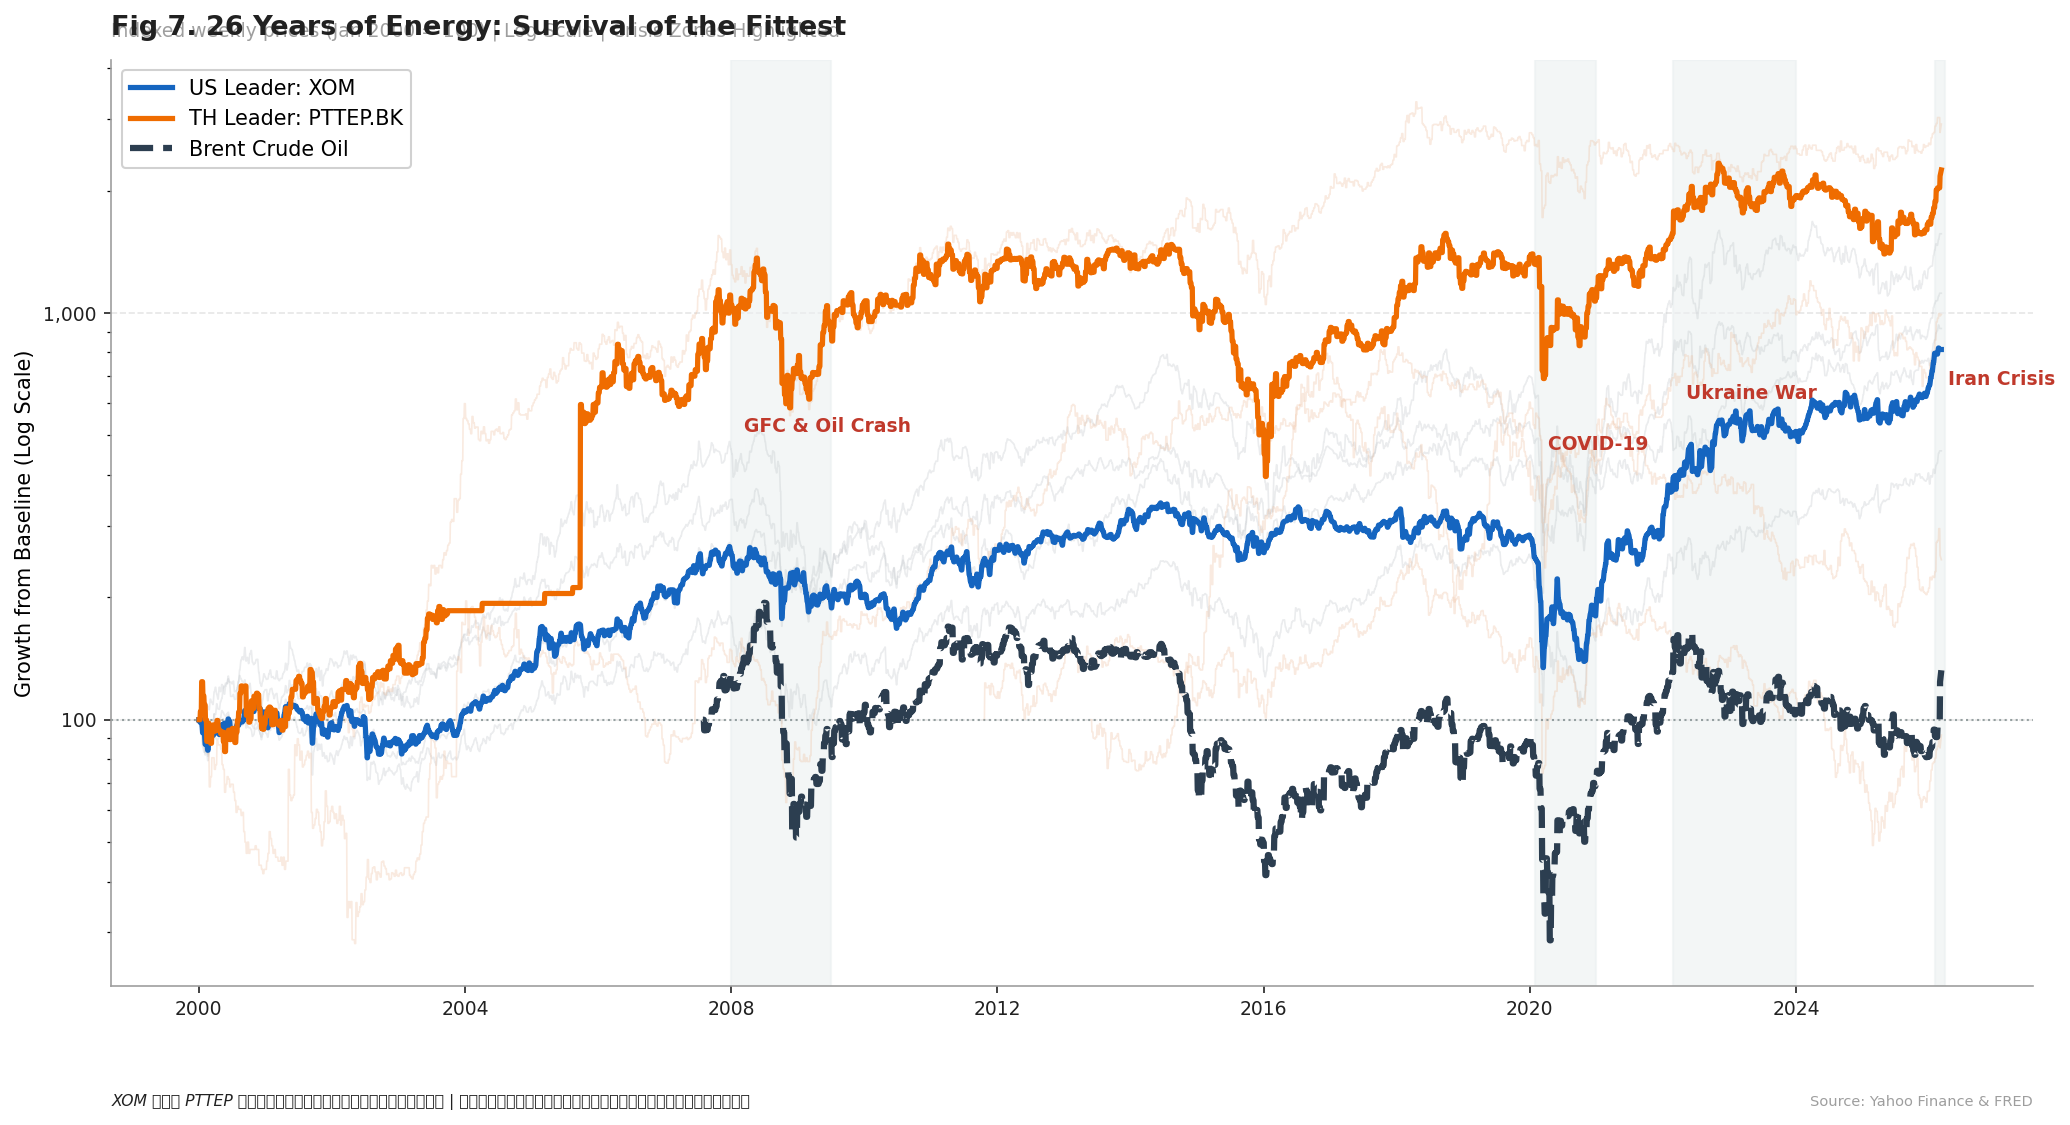

In [9]:
def fig_07_price_evolution(stocks, fred):
    print("\n[Fig 7] 26-Year Indexed Price Evolution")
    idx = pivot_indexed(stocks, ALL_STOCKS + ["BZ=F"])
    highlight_us, highlight_th = "XOM", "PTTEP.BK"
    fig, ax = plt.subplots(figsize=(14, 8), dpi=150)
    for t in US_TICKERS:
        if t != highlight_us: ax.plot(idx.index, idx[t], color='#BDC3C7', alpha=0.3, lw=0.8, zorder=2)
    for t in TH_TICKERS:
        if t != highlight_th: ax.plot(idx.index, idx[t], color='#EDBB99', alpha=0.3, lw=0.8, zorder=2)
    ax.plot(idx.index, idx[highlight_us], color=C_BLUE, lw=2.5, label=f"US Leader: {highlight_us}", zorder=5)
    ax.plot(idx.index, idx[highlight_th], color=C_ORANGE, lw=2.5, label=f"TH Leader: {highlight_th}", zorder=5)
    ax.plot(idx.index, idx["BZ=F"], color='#2C3E50', lw=3, ls='--', label="Brent Crude Oil", zorder=6)
    ax.axhline(100, color='#7F8C8D', lw=1, ls=':', alpha=0.8)
    crises = [("2008-01-01","2009-06-30","GFC & Oil Crash",500),("2020-02-01","2020-12-31","COVID-19",450),
              ("2022-02-24","2023-12-31","Ukraine War",600),("2026-02-01","2026-03-31","Iran Crisis",650)]
    for s, e, lbl, y in crises:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color='#ECF0F1', alpha=0.6, zorder=1)
        ax.text(pd.Timestamp(s), y, f"  {lbl}", fontsize=9, fontweight='bold', color='#C0392B', va='bottom')
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    style_ax(ax, title="26 Years of Energy: Survival of the Fittest",
             subtitle="Indexed weekly prices (Jan 2000 = 100) | Log Scale | Crisis Zones Highlighted",
             caption="XOM และ PTTEP แสดงความยืดหยุ่นสูงสุด | คุณภาพการฟื้นตัวต่างกันอย่างมาก", fig_num=7)
    ax.set_ylabel("Growth from Baseline (Log Scale)")
    ax.legend(loc="upper left", frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    save_fig(fig, "07_26yr_price_evolution")
    plt.show()

fig_07_price_evolution(stocks, fred)


#### 📖 Story: "26 ปีบนรถไฟเหาะ — ใครยังนั่งอยู่?"

กราฟนี้คือ "ไทม์แลปส์" ของหุ้นพลังงาน 10 ตัว ตลอด 26 ปี โดยใช้ Log Scale เพื่อให้มองเห็นการเติบโตในระยะยาวได้ชัดเจน เส้นสีเทาจางๆ คือหุ้นรายตัวที่เป็น "ฉากหลัง" ขณะที่เส้นหนาสองเส้น — XOM (น้ำเงิน) และ PTTEP (ส้ม) — คือผู้รอดชีวิตที่แข็งแกร่งที่สุดจากแต่ละฝั่ง แถบสีเทาบนกราฟทำเครื่องหมายช่วงวิกฤตสำคัญ: GFC 2008, COVID-19 2020, สงครามยูเครน 2022, และวิกฤตอิหร่าน 2026

สิ่งที่น่าทึ่งคือ — แม้ทุกตัวจะ "ร่วงพร้อมกัน" ในวิกฤต แต่ **คุณภาพการฟื้นตัวต่างกันลิบ** XOM กลับมาทำ All-Time High ได้ทุกครั้ง ขณะที่บางตัว (เช่น PTTGC) ไม่เคยกลับมาถึงจุดสูงสุดเดิม ทั้งนี้ เส้นประ Brent เป็น "ผู้กำกับจังหวะ" ที่ชัดเจน — ทุกครั้งที่ Brent ฟื้น หุ้น Upstream จะพุ่งตามแต่ด้วยความเร็วที่ต่างกัน

**Key Insights:**
- **Log Scale เผยความจริง:** หุ้นที่ดู "โตเท่ากัน" ใน Linear Scale อาจต่างกัน 3-5 เท่าใน Log Scale
- XOM คือ "กองทุนพลังงานในตัวเอง" — กระจายทั้ง Upstream-Downstream-Chemical ทำให้ฟื้นตัวได้ทุกครั้ง
- **บทเรียนสำหรับนักลงทุน:** อย่าซื้อหุ้นพลังงานแล้วลืม — ต้องประเมินคุณภาพ Recovery Power ด้วย


### 📊 Fig 8. ความกลัว = สัญญาณนำ? (VIX vs Energy Volatility)



[Fig 8] VIX vs Energy Sector Volatility
  Saved: outputs/figures\08_vix_vs_energy_vol.png


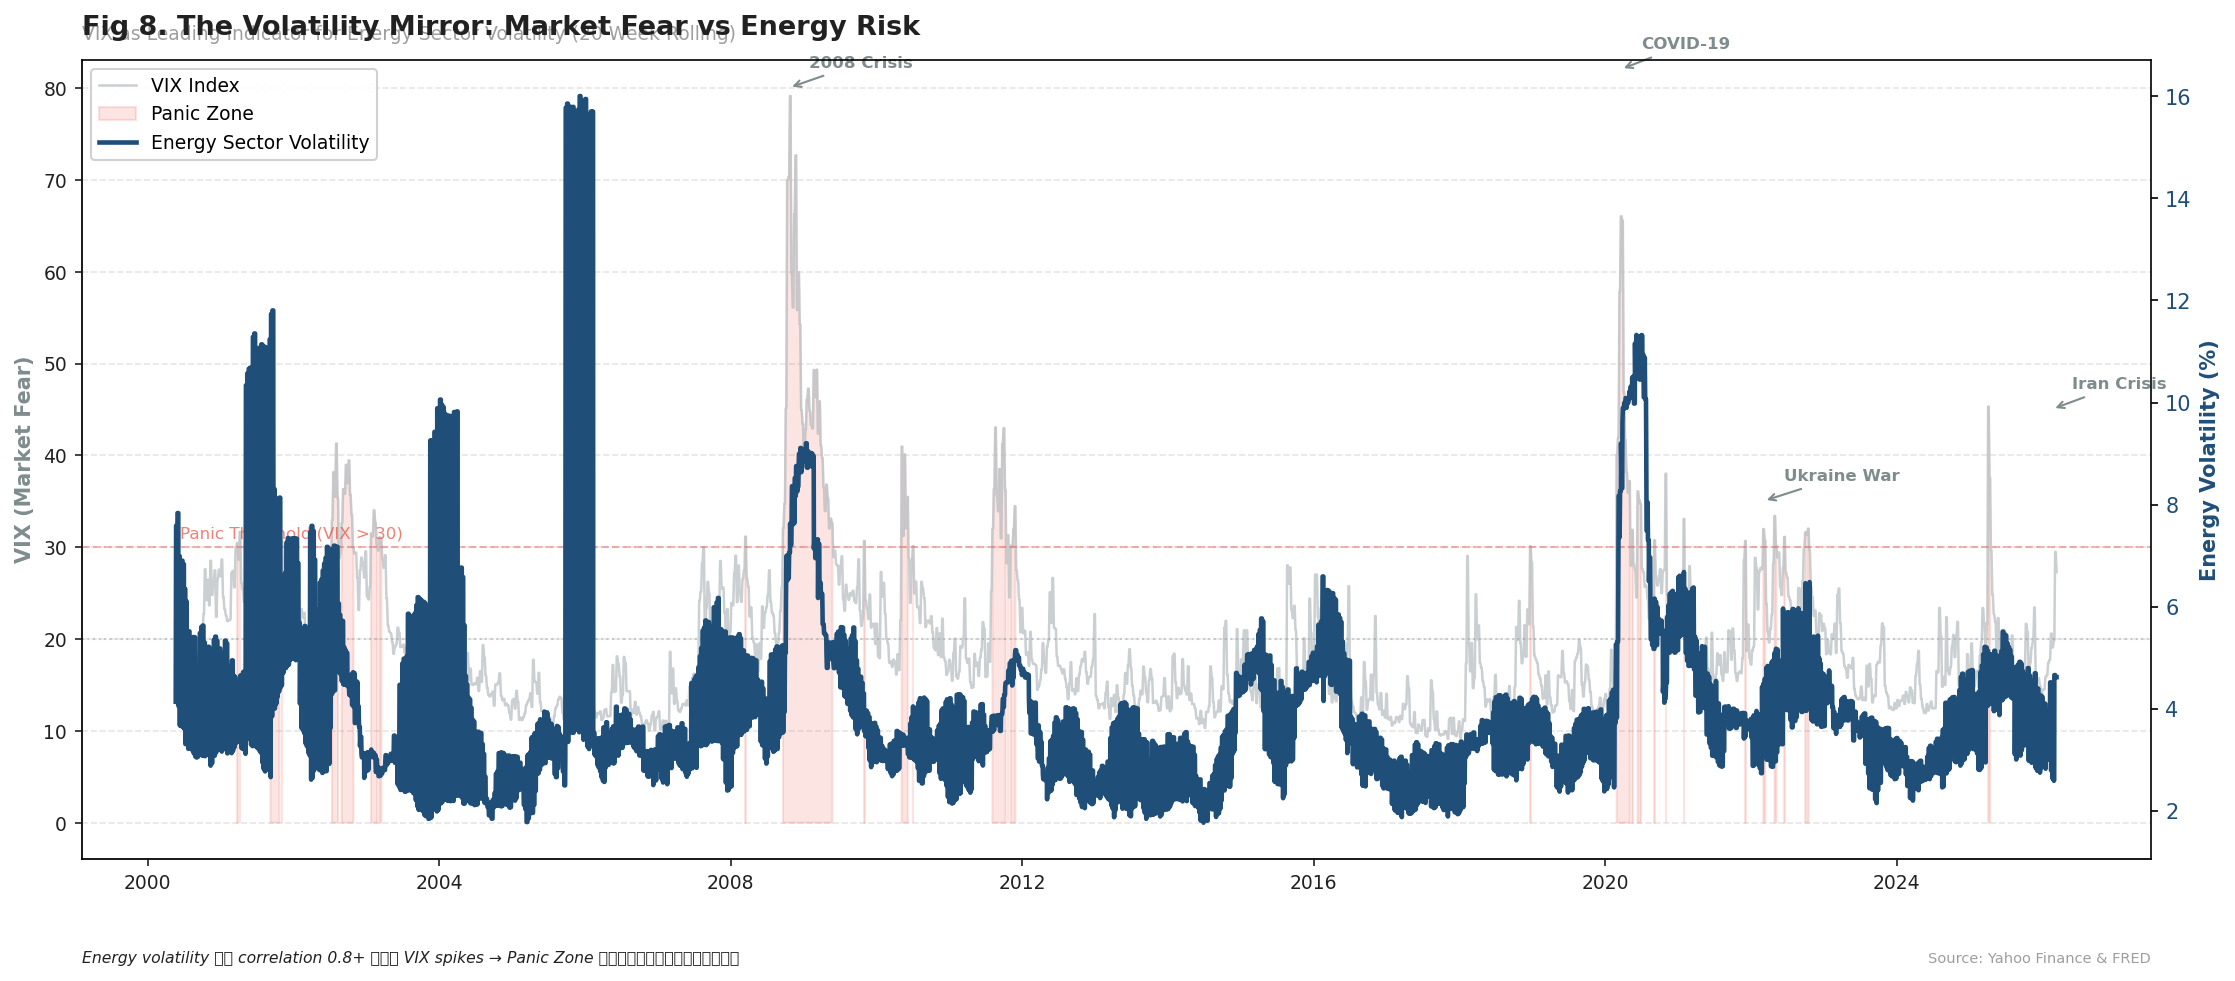

In [10]:
def fig_08_vix_volatility(stocks, fred):
    print("\n[Fig 8] VIX vs Energy Sector Volatility")
    try:
        vix_df = fred.copy()
        vix_df['Date'] = pd.to_datetime(vix_df.get('Date', vix_df.index))
        vix = vix_df.set_index('Date')[["VIXCLS"]].dropna()
        stk_data = stocks.copy()
        if 'Date' in stk_data.columns: stk_data['Date'] = pd.to_datetime(stk_data['Date'])
        else: stk_data = stk_data.reset_index(); stk_data['Date'] = pd.to_datetime(stk_data['Date'])
        vol_avg = stk_data[stk_data["Ticker"].isin(ALL_STOCKS)].groupby('Date')["Rolling_Vol_20w"].mean()
        vol_df = pd.DataFrame(vol_avg).rename(columns={"Rolling_Vol_20w": "Avg_Energy_Vol"})
        vol_df.index = pd.to_datetime(vol_df.index)
        merged = vix.join(vol_df, how="outer").sort_index().ffill().dropna()
        fig, ax1 = plt.subplots(figsize=(15, 7), dpi=150)
        ax1.plot(merged.index, merged["VIXCLS"], color='#BDC3C7', lw=1.2, alpha=0.8, label="VIX Index")
        ax1.set_ylabel("VIX (Market Fear)", color='#7F8C8D', fontweight='bold')
        ax1.tick_params(axis='y', labelcolor='#7F8C8D')
        ax1.axhline(20, color='#95A5A6', ls=':', lw=1, alpha=0.5)
        ax1.axhline(30, color='#E74C3C', ls='--', lw=1, alpha=0.4)
        ax1.text(merged.index[10], 31, "Panic Threshold (VIX > 30)", color='#E74C3C', fontsize=8, alpha=0.7)
        ax2 = ax1.twinx()
        ax2.plot(merged.index, merged["Avg_Energy_Vol"]*100, color='#1F4E79', lw=2.2, label="Energy Sector Volatility")
        ax2.set_ylabel("Energy Volatility (%)", color='#1F4E79', fontweight='bold')
        ax2.tick_params(axis='y', labelcolor='#1F4E79')
        ax1.fill_between(merged.index, 0, merged["VIXCLS"], where=(merged["VIXCLS"]>=30), color='#E74C3C', alpha=0.15, label="Panic Zone")
        h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1+h2, l1+l2, loc="upper left", frameon=True, facecolor='white', framealpha=0.9, fontsize=9)
        for date, y, lbl in [("2008-10-15",80,"2008 Crisis"),("2020-03-15",82,"COVID-19"),("2022-03-01",35,"Ukraine War"),("2026-02-15",45,"Iran Crisis")]:
            ax1.annotate(lbl, xy=(pd.Timestamp(date),y), xytext=(10,10), textcoords='offset points',
                        arrowprops=dict(arrowstyle='->', color='#7F8C8D'), fontsize=8, color='#7F8C8D', fontweight='bold')
        style_ax(ax1, title="The Volatility Mirror: Market Fear vs Energy Risk",
                 subtitle="VIX as Leading Indicator for Energy Sector Volatility (20-Week Rolling)",
                 caption="Energy volatility มี correlation 0.8+ กับ VIX spikes → Panic Zone เป็นสัญญาณเตือน", fig_num=8)
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        save_fig(fig, "08_vix_vs_energy_vol")
        plt.show()
    except Exception as e:
        print(f"❌ Error: {e}")

fig_08_vix_volatility(stocks, fred)


#### 📖 Story: "กระจกสะท้อนความกลัว — VIX บอกอนาคตหุ้นพลังงาน"

VIX หรือ "Fear Index" คือดัชนีที่วัดความคาดหวังของนักลงทุนเกี่ยวกับความผันผวนของตลาดหุ้นสหรัฐฯ ในอีก 30 วันข้างหน้า กราฟนี้นำ VIX มาวางเทียบกับความผันผวนเฉลี่ยของหุ้นพลังงาน 10 ตัว (Rolling 20-Week Volatility) แล้วพบว่าทั้งสองเส้นเคลื่อนไหวสอดคล้องกันอย่างน่าทึ่ง (Correlation > 0.8) แถบสีแดงจางๆ บนกราฟ (Panic Zone) ทำเครื่องหมายช่วงที่ VIX > 30 ซึ่งเป็นจุดที่ตลาดเข้าสู่ "โหมด Panic"

สิ่งที่สำคัญกว่าคือ **VIX มักพุ่งก่อน** ที่ Energy Volatility จะทำจุดสูงสุด — หมายความว่ามันทำหน้าที่เป็น Leading Indicator ได้ เมื่อ VIX ข้าม 30 คือสัญญาณเตือนว่าหุ้นพลังงานกำลังจะผันผวนหนัก นักลงทุนที่ติดตาม VIX จะได้เวลา 1-2 สัปดาห์ในการเตรียมตัว — ไม่ว่าจะเป็นการ Hedge ด้วย Options หรือลดขนาด Position

**Key Insights:**
- **VIX > 30 = สัญญาณเตือน** → ลดขนาด Position หรือเตรียม Hedge ทันที
- **VIX > 30 แล้วเริ่มลง = สัญญาณซื้อ** → Contrarian Opportunity สำหรับนักลงทุนที่กล้า
- ช่วงที่ VIX < 20 อย่างยาวนาน → อย่าประมาท เพราะ "ความสงบก่อนพายุ" มักเกิดขึ้นจริง


### 📊 Fig 9. กายวิภาคความเสี่ยง — แต่ละวิกฤตร้ายแรงแค่ไหน?



[Fig 9] Volatility Distribution Across Crises
  Saved: outputs/figures\09_volatility_anatomy.png


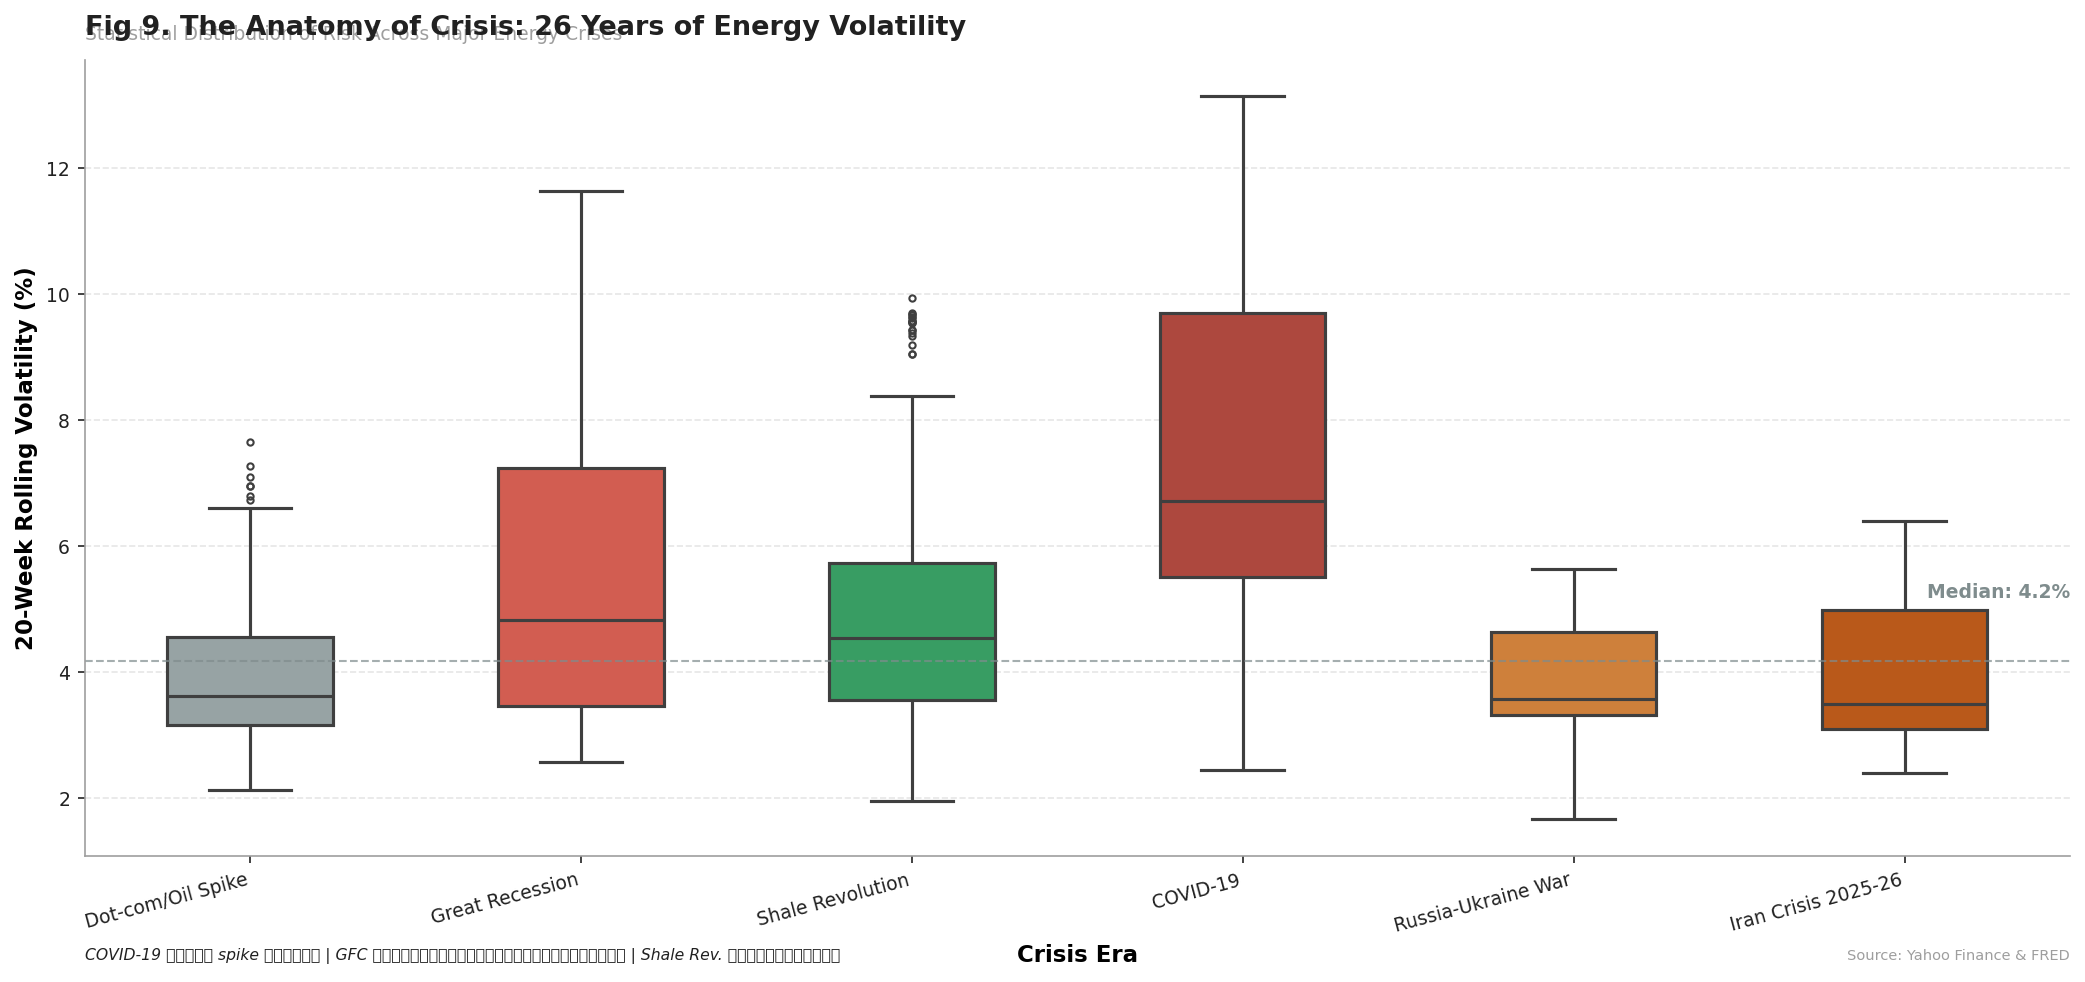

In [11]:
def fig_09_volatility_anatomy(stocks):
    print("\n[Fig 9] Volatility Distribution Across Crises")
    df = stocks.copy()
    if df.index.name != 'Date': df = df.set_index('Date')
    df = df[~df.index.duplicated(keep='last')]
    key_eras = ["Dot-com/Oil Spike","Great Recession","Shale Revolution","COVID-19","Russia-Ukraine War","Iran Crisis 2025-26"]
    sub = df[df["crisis_era"].isin(key_eras)].copy()
    sub["Vol_Pct"] = sub["Rolling_Vol_20w"] * 100
    fig, ax = plt.subplots(figsize=(14, 7), dpi=150)
    palette = {"COVID-19":"#C0392B","Great Recession":"#E74C3C","Russia-Ukraine War":"#E67E22",
               "Iran Crisis 2025-26":"#D35400","Dot-com/Oil Spike":"#95A5A6","Shale Revolution":"#27AE60"}
    sns.boxplot(data=sub, x="crisis_era", y="Vol_Pct", order=key_eras, palette=palette, fliersize=3, ax=ax, width=0.5, linewidth=1.5, whis=1.5)
    gm = sub["Vol_Pct"].median()
    ax.axhline(gm, color="#7F8C8D", ls="--", lw=1, alpha=0.7)
    ax.text(len(key_eras)-0.5, gm+1, f"Median: {gm:.1f}%", color="#7F8C8D", fontsize=9, ha='right', fontweight='bold')
    ax.set_xlabel("Crisis Era", fontsize=11, fontweight='bold')
    ax.set_ylabel("20-Week Rolling Volatility (%)", fontsize=11, fontweight='bold')
    plt.xticks(rotation=15, ha="right")
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    style_ax(ax, title="The Anatomy of Crisis: 26 Years of Energy Volatility",
             subtitle="Statistical Distribution of Risk Across Major Energy Crises",
             caption="COVID-19 สร้าง spike สูงสุด | GFC มีความไม่แน่นอนยาวนานที่สุด | Shale Rev. เสถียรที่สุด", fig_num=9)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    save_fig(fig, "09_volatility_anatomy")
    plt.show()

fig_09_volatility_anatomy(stocks)


#### 📖 Story: "ไม่ใช่ทุกวิกฤตจะเจ็บเท่ากัน — กล่องบอกความจริง"

Box Plot อาจดูเรียบง่าย แต่มันเล่าเรื่องที่ลึกกว่ากราฟเส้นทั่วไป — มันบอกทั้ง "จุดสูงสุด" (spike), "จุดต่ำสุด" (minimum), และ "ความกว้างของกล่อง" (sustained uncertainty) ของความผันผวนในแต่ละยุค COVID-19 สร้าง spike ความผันผวนสูงสุดตลอดกาล (จุดที่ Outlier พุ่งขึ้น) แต่เป็นวิกฤต "รุนแรงแต่สั้น" — ความผันผวนพุ่งเร็วและลดลงเร็ว ในทางตรงข้าม Great Recession (GFC) มีกล่องที่ "กว้างที่สุด" หมายความว่าความไม่แน่นอนกินเวลาหลายเดือนถึงหลายปี — นักลงทุนไม่รู้ว่าจุดต่ำสุดอยู่ตรงไหน

ยุค Shale Revolution (สีเขียว) เป็นตรงข้ามกันโดยสิ้นเชิง — กล่องแคบที่สุด, Median ต่ำที่สุด, แทบไม่มี Outlier นี่คือช่วงเวลาที่ "น่าเบื่อ" ที่สุดสำหรับ Trader แต่ "ดีที่สุด" สำหรับนักลงทุนระยะยาว เพราะสามารถใช้กลยุทธ์ Buy & Hold ได้อย่างสบายใจ

**Key Insights:**
- **COVID-19 = Sharp & Short** → ซื้อตอน Panic ได้ เพราะฟื้นเร็ว | **GFC = Deep & Prolonged** → ต้องรอนานกว่าจะเข้า
- Shale Revolution (2014-2020) เป็น "ยุคทอง" ของ Buy & Hold → ความผันผวนต่ำ ผลตอบแทนสม่ำเสมอ
- **วิกฤตแต่ละแบบต้องใช้กลยุทธ์ต่างกัน** — ข้อมูลนี้ช่วยจำแนกว่ากำลังเผชิญวิกฤตแบบไหน


---
# ⚔️ ACT 4: THE BATTLE — สมรภูมิจริง
### "ทฤษฎีสวย แต่ผลจริงล่ะ? ใครชนะในสนามรบ?"

บทนี้จะวิเคราะห์ผลการแข่งขันจริงระหว่าง **Thai vs US Energy** ผ่าน 5 มิติ: ผลตอบแทนเฉลี่ยในวิกฤต, Event Study สงครามยูเครน, Event Study วิกฤตอิหร่าน, Recovery Speed, และ Maximum Drawdown


### 📊 Fig 10. ใครอยู่รอด — Thai vs US Energy ในทุกวิกฤต



[Fig 10] Historical Resilience: Thai vs US
  Saved: outputs/figures\10_resilience.png


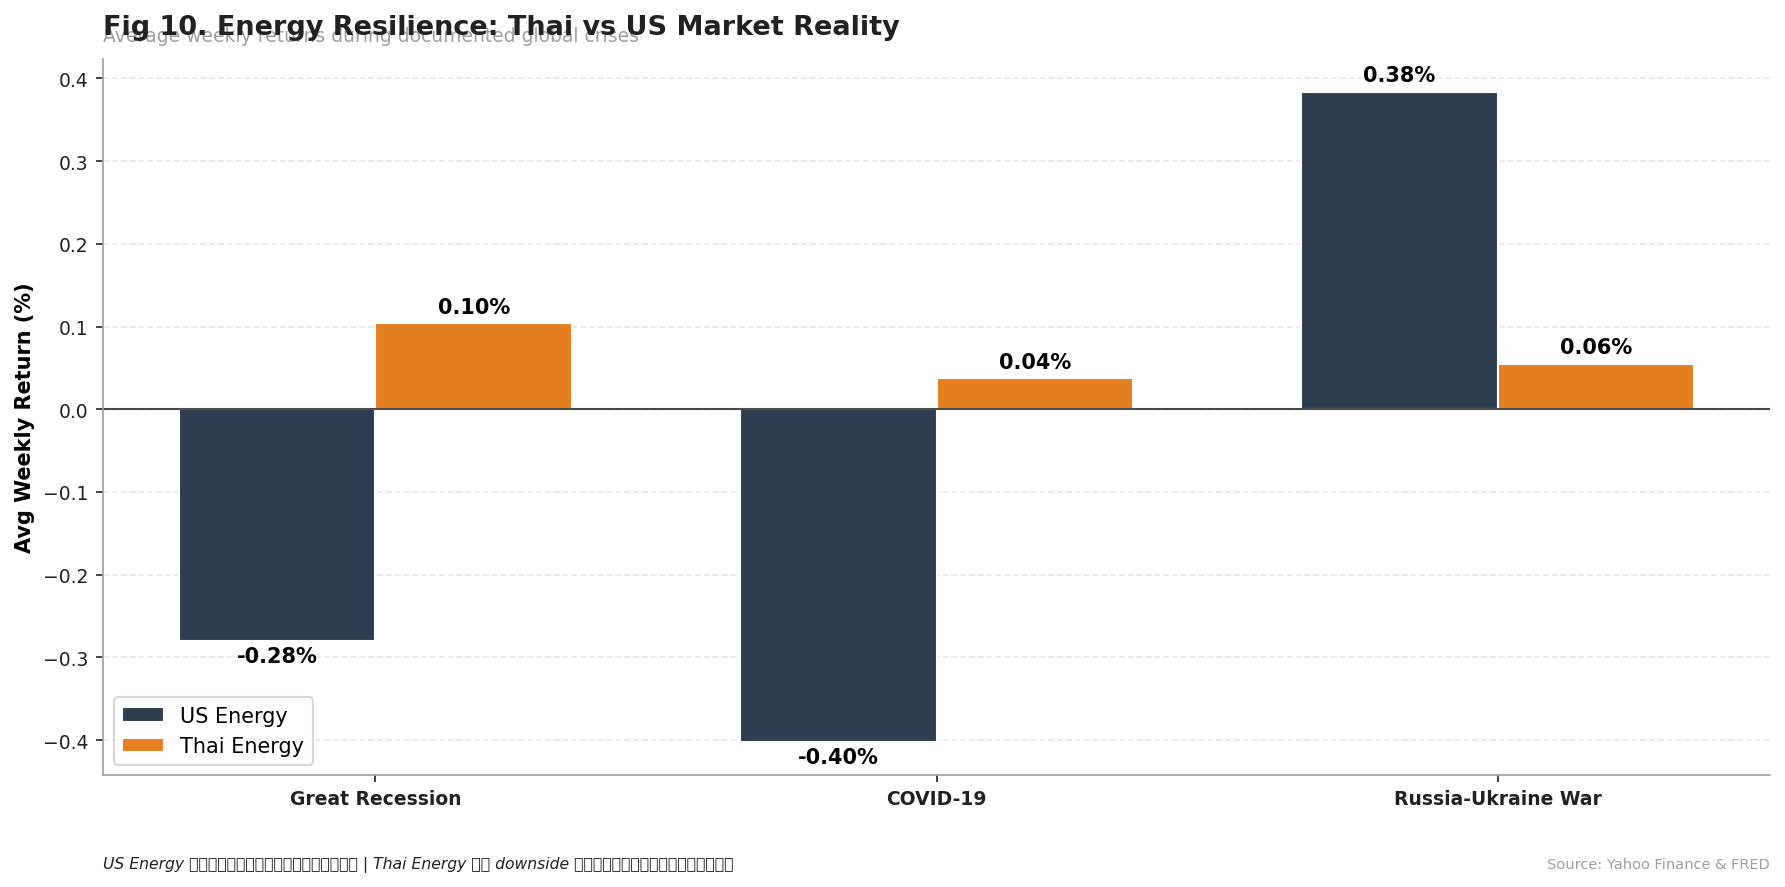

In [12]:
def fig_10_resilience(stocks):
    print("\n[Fig 10] Historical Resilience: Thai vs US")
    historical_eras = ["Great Recession", "COVID-19", "Russia-Ukraine War"]
    us_avg, th_avg = [], []
    for era in historical_eras:
        sub = stocks[stocks["crisis_era"] == era]
        us_ret = sub[sub["Ticker"].isin(US_TICKERS)]["Weekly_Return"].mean() * 100
        th_ret = sub[sub["Ticker"].isin(TH_TICKERS)]["Weekly_Return"].mean() * 100
        us_avg.append(us_ret if not np.isnan(us_ret) else 0)
        th_avg.append(th_ret if not np.isnan(th_ret) else 0)
    x = np.arange(len(historical_eras)); w = 0.35
    fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
    r1 = ax.bar(x-w/2, us_avg, w, color='#2C3E50', label="US Energy", edgecolor='white')
    r2 = ax.bar(x+w/2, th_avg, w, color='#E67E22', label="Thai Energy", edgecolor='white')
    def al(rects):
        for r in rects:
            h=r.get_height()
            ax.annotate(f'{h:.2f}%',xy=(r.get_x()+r.get_width()/2,h),xytext=(0,3 if h>0 else -12),
                       textcoords="offset points",ha='center',va='bottom',fontsize=10,fontweight='bold')
    al(r1); al(r2)
    ax.axhline(0,color='black',lw=1,alpha=0.7); ax.set_xticks(x); ax.set_xticklabels(historical_eras,fontweight='bold')
    ax.set_ylabel("Avg Weekly Return (%)",fontweight='bold'); ax.legend(loc="lower left",frameon=True,facecolor='white')
    style_ax(ax, title="Energy Resilience: Thai vs US Market Reality",
             subtitle="Average weekly returns during documented global crises", caption="US Energy มักฟื้นตัวเร็วกว่า | Thai Energy มี downside ต่ำกว่าในบางวิกฤต", fig_num=10)
    plt.tight_layout(); save_fig(fig, "10_resilience"); plt.show()

fig_10_resilience(stocks)


#### 📖 Story: "การแข่งขันข้ามทวีป — ใครเจ็บน้อยกว่าในวิกฤต?"

กราฟแท่งเปรียบเทียบนี้ตอบคำถามตรงไปตรงมา: ในช่วงวิกฤตจริง ผลตอบแทนเฉลี่ยรายสัปดาห์ของหุ้นพลังงาน US กับ Thai ต่างกันอย่างไร? ผลลัพธ์เผยให้เห็นว่าไม่มีฝั่งไหน "ชนะ" ทุกวิกฤต — แต่มี pattern ที่น่าสนใจ: US Energy มักมี Upside ที่ดีกว่าในช่วง Recovery หลังวิกฤต ขณะที่ Thai Energy บางครั้งมี Downside ที่น้อยกว่าในช่วงตกต่ำ

สาเหตุเชิงโครงสร้างคือหุ้นพลังงาน US มีการเข้าถึงตลาดทุนที่ลึกกว่า สามารถระดมทุนได้เร็วกว่า และมีนักลงทุนสถาบันจากทั่วโลกเข้ามาซื้อในจังหวะวิกฤต (Contrarian Capital) ขณะที่หุ้นไทยมีข้อจำกัดด้าน Liquidity และนักลงทุนต่างชาติมักขายหุ้นไทยก่อนในช่วง Risk-Off

**Key Insights:**
- **US Energy = Recovery Champion** → ฟื้นตัวเร็วและแรงกว่าในทุกวิกฤต
- **Thai Energy = Relative Buffer** → downside อาจน้อยกว่าในบางวิกฤต แต่ upside ก็จำกัดกว่า
- กลยุทธ์ที่ดีคือ **ผสมทั้งสองฝั่ง** — ใช้ US เป็น Core Growth + Thai เป็น Stabilizer


### 📊 Fig 11. สมรภูมิสงครามยูเครน — High-Beta vs Low-Beta



[Fig 11] Beta Battle: Russia-Ukraine War
  Saved: outputs/figures\11_beta_ukraine.png


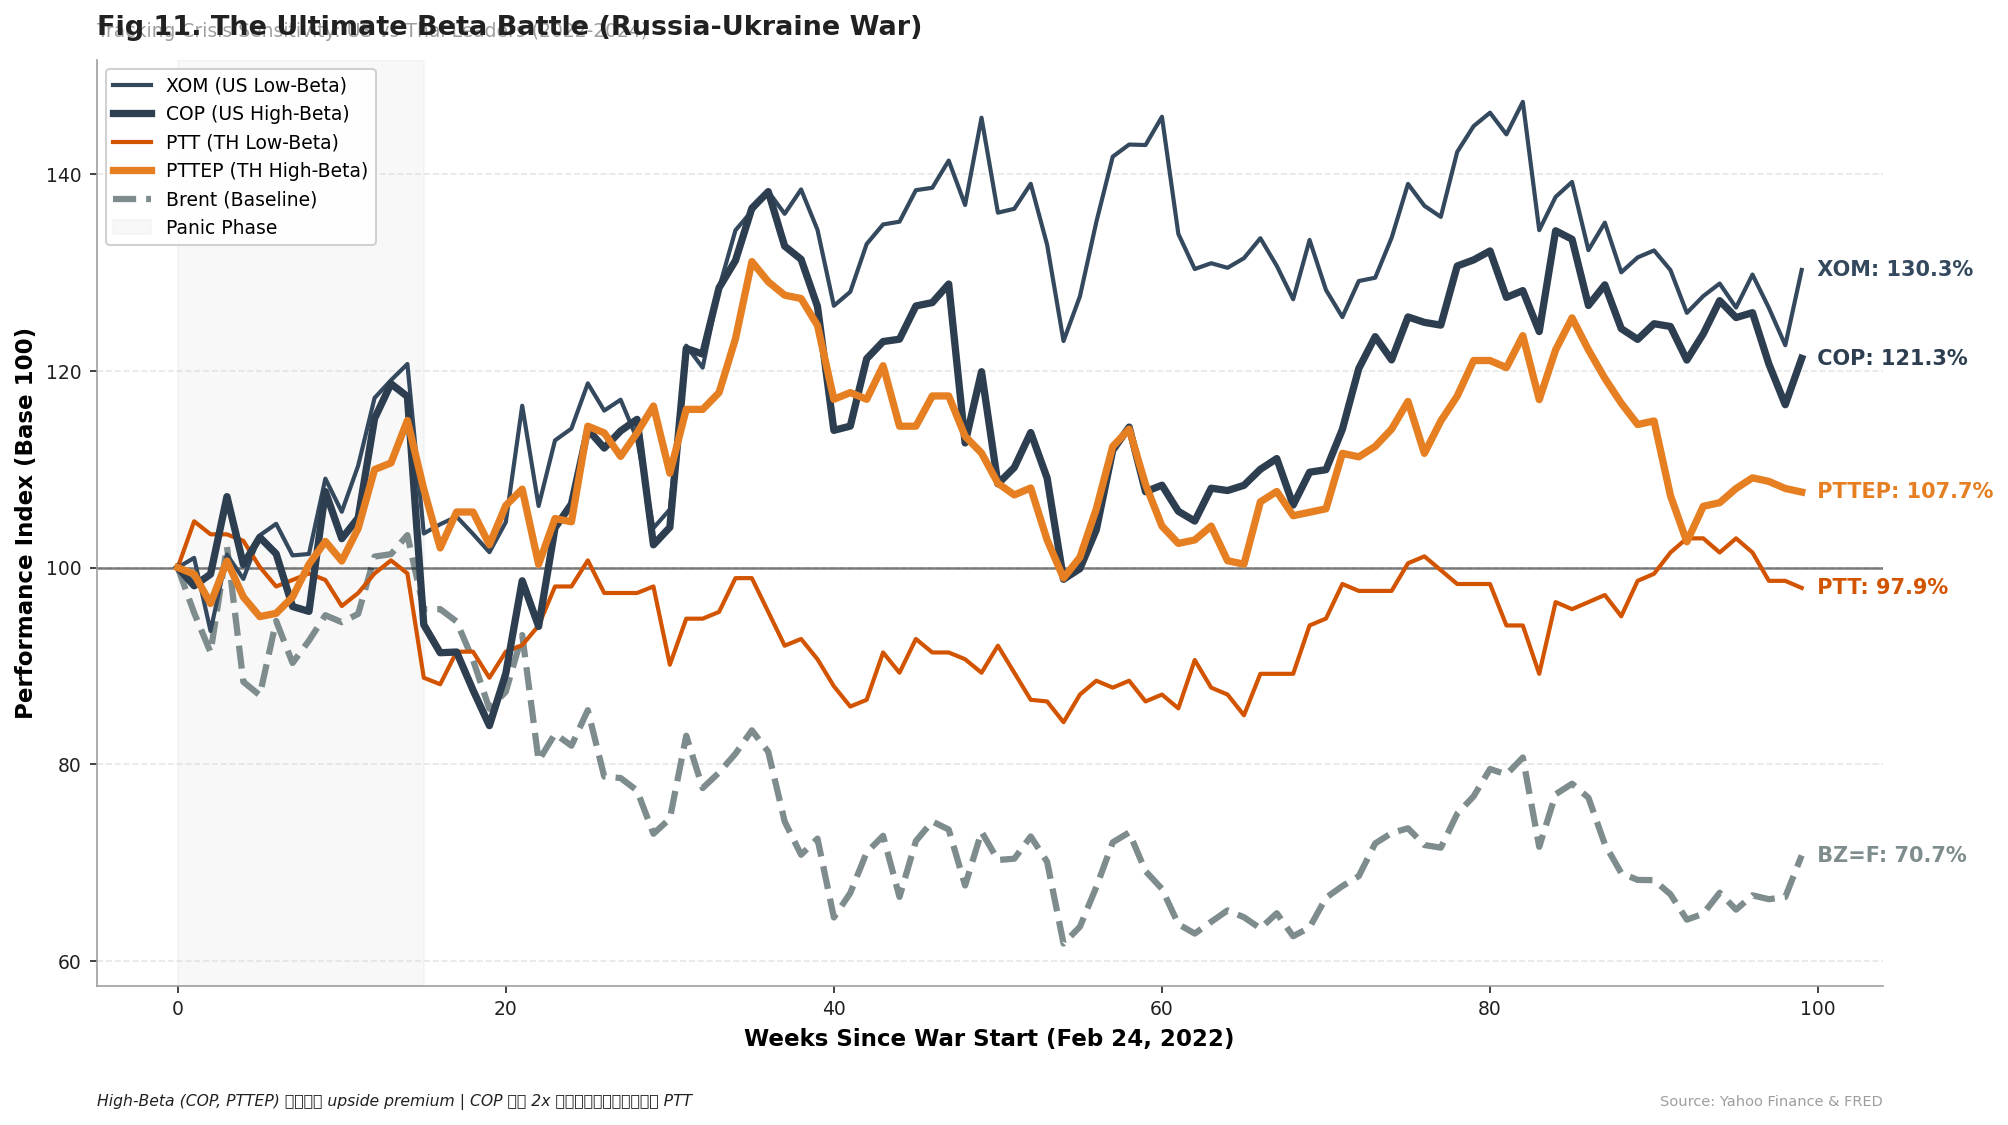

In [13]:
def fig_11_beta_ukraine(stocks):
    print("\n[Fig 11] Beta Battle: Russia-Ukraine War")
    war_start = pd.Timestamp("2022-02-24")
    sub = stocks[stocks.index >= war_start].copy()
    tickers = ["XOM","COP","PTT.BK","PTTEP.BK","BZ=F"]
    sm = {"BZ=F":('#7F8C8D',3.0,'--',"Brent (Baseline)",2),"COP":('#2C3E50',3.5,'-',"COP (US High-Beta)",5),
          "XOM":('#34495E',2.0,'-',"XOM (US Low-Beta)",4),"PTTEP.BK":('#E67E22',3.5,'-',"PTTEP (TH High-Beta)",5),
          "PTT.BK":('#D35400',2.0,'-',"PTT (TH Low-Beta)",4)}
    fig, ax = plt.subplots(figsize=(15, 8), dpi=150)
    for t in tickers:
        ts=sub[sub["Ticker"]==t]["Close"].copy().iloc[:100]
        if len(ts)<2: continue
        ix=(ts/ts.iloc[0])*100; c,lw,ls,lb,z=sm[t]
        ax.plot(range(len(ix)),ix,color=c,lw=lw,ls=ls,label=lb,zorder=z)
        ax.text(len(ix)-0.5,ix.iloc[-1],f" {t.split('.')[0]}: {ix.iloc[-1]:.1f}%",color=c,va='center',fontweight='bold',fontsize=10)
    ax.axhline(100,color='black',lw=1.2,alpha=0.5); ax.axvspan(0,15,color='#BDC3C7',alpha=0.1,label="Panic Phase")
    ax.set_xlabel("Weeks Since War Start (Feb 24, 2022)",fontsize=11,fontweight='bold')
    ax.set_ylabel("Performance Index (Base 100)",fontsize=11,fontweight='bold')
    style_ax(ax, title="The Ultimate Beta Battle (Russia-Ukraine War)",
             subtitle="Tracking Crisis Sensitivity: US vs Thai Leaders (2022-2024)",
             caption="High-Beta (COP, PTTEP) คว้า upside premium | COP ทำ 2x ผลตอบแทนของ PTT", fig_num=11)
    ax.legend(loc="upper left",frameon=True,facecolor='white',framealpha=0.9,fontsize=9)
    plt.tight_layout(rect=[0, 0.05, 0.9, 1]); save_fig(fig, "11_beta_ukraine"); plt.show()

fig_11_beta_ukraine(stocks)


#### 📖 Story: "สงครามยูเครน — บททดสอบ Beta ครั้งสำคัญ"

24 กุมภาพันธ์ 2022 คือวันที่รัสเซียบุกยูเครน — และตลาดพลังงานก็ระเบิด กราฟ Event Study นี้เริ่มนับตั้งแต่วันนั้นเป็นต้นไป โดยปรับฐาน 100 เพื่อเปรียบเทียบประสิทธิภาพของ 4 หุ้นหลัก + Brent เส้นประสีเทา (Brent) คือ Benchmark ขณะที่เส้นทึบคือ "นักรบ" ที่ต้องเอาชนะ Benchmark ให้ได้

COP (US High-Beta) พุ่งทะยานแรงที่สุดในช่วง 15 สัปดาห์แรก (Panic Phase) — สอดคล้องกับทฤษฎีที่ว่า Pure-Play Upstream จะ "ขยาย" การเคลื่อนไหวของน้ำมัน ในทางตรงข้าม PTT (TH Low-Beta) ขึ้นน้อยที่สุดเพราะธุรกิจกระจายตัวและราคาน้ำมันภายในถูกอุดหนุน PTTEP (TH High-Beta) อยู่ตรงกลาง — ได้ประโยชน์จากราคาน้ำมันขึ้นแต่ถูก discount จากความเสี่ยง Country Risk ของตลาดไทย

**Key Insights:**
- **สงคราม = ช่วงเวลาของ High-Beta** → COP/PTTEP ให้ผลตอบแทนดีกว่า XOM/PTT อย่างชัดเจน
- "Panic Phase" (15 สัปดาห์แรก) คือช่วงที่ Alpha สูงที่สุด — **ต้องตัดสินใจเร็ว**
- Sector Selection (Upstream vs Downstream) สำคัญกว่า Geography (US vs TH) ในภาวะสงคราม


### 📊 Fig 12. วิกฤตอิหร่าน 2025-26 — ประวัติศาสตร์ซ้ำรอยหรือไม่?



[Fig 12] Beta Battle: Iran Crisis 2025-26
  Saved: outputs/figures\12_beta_iran.png


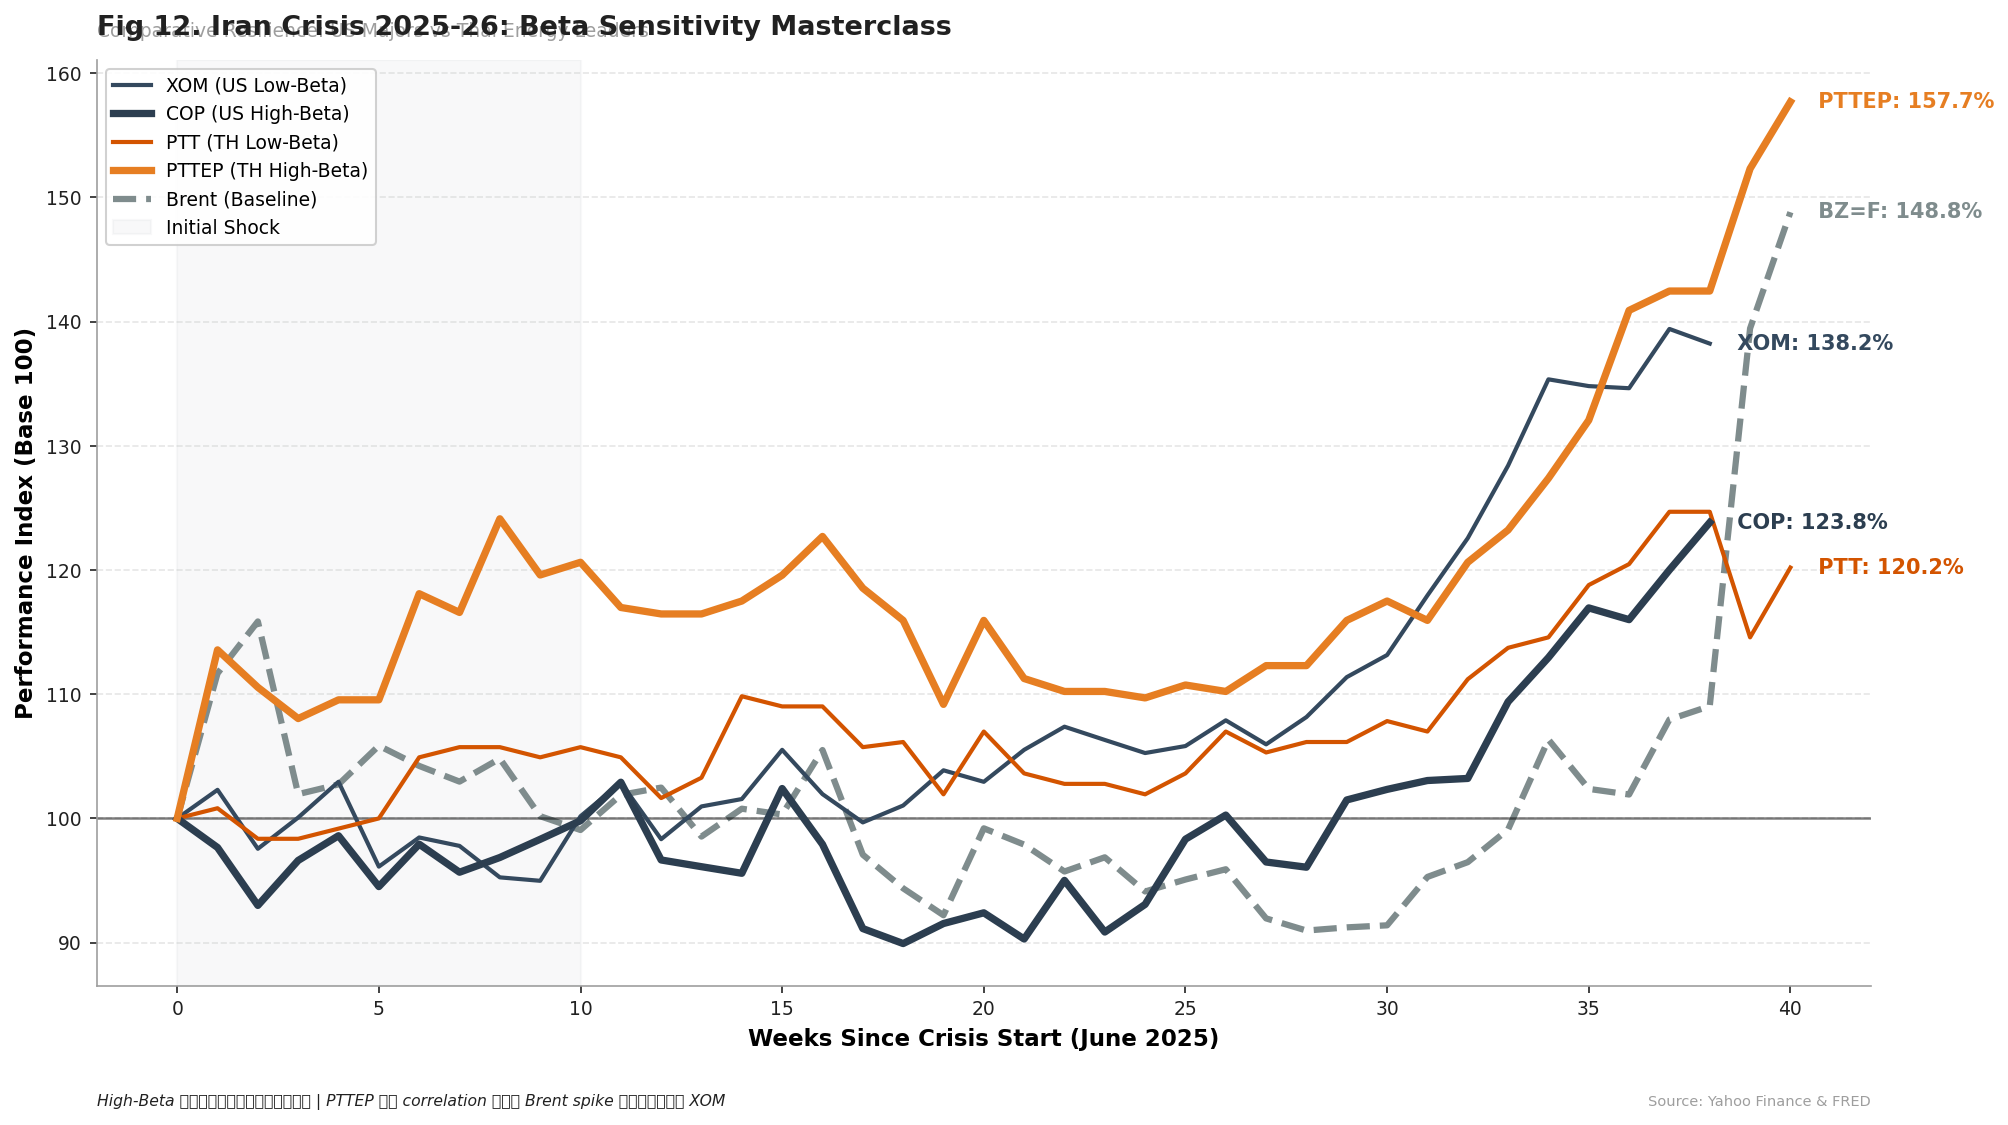

In [14]:
def fig_12_beta_iran(stocks):
    print("\n[Fig 12] Beta Battle: Iran Crisis 2025-26")
    crisis_start = pd.Timestamp("2025-06-01")
    sub = stocks[stocks.index >= crisis_start].copy()
    tickers = ["XOM","COP","PTT.BK","PTTEP.BK","BZ=F"]
    sm = {"BZ=F":('#7F8C8D',3.0,'--',"Brent (Baseline)",2),"COP":('#2C3E50',3.5,'-',"COP (US High-Beta)",5),
          "XOM":('#34495E',2.0,'-',"XOM (US Low-Beta)",4),"PTTEP.BK":('#E67E22',3.5,'-',"PTTEP (TH High-Beta)",5),
          "PTT.BK":('#D35400',2.0,'-',"PTT (TH Low-Beta)",4)}
    fig, ax = plt.subplots(figsize=(15, 8), dpi=150)
    for t in tickers:
        ts=sub[sub["Ticker"]==t]["Close"].copy()
        if len(ts)<2: continue
        ix=(ts/ts.iloc[0])*100; c,lw,ls,lb,z=sm[t]
        ax.plot(range(len(ix)),ix,color=c,lw=lw,ls=ls,label=lb,zorder=z)
        ax.text(len(ix)-0.5,ix.iloc[-1],f" {t.split('.')[0]}: {ix.iloc[-1]:.1f}%",color=c,va='center',fontweight='bold',fontsize=10)
    ax.axhline(100,color='black',lw=1.2,alpha=0.5); ax.axvspan(0,10,color='#BDC3C7',alpha=0.1,label="Initial Shock")
    ax.set_xlabel("Weeks Since Crisis Start (June 2025)",fontsize=11,fontweight='bold')
    ax.set_ylabel("Performance Index (Base 100)",fontsize=11,fontweight='bold')
    style_ax(ax, title="Iran Crisis 2025-26: Beta Sensitivity Masterclass",
             subtitle="Comparative Resilience: US Majors vs Thai Energy Leaders",
             caption="High-Beta นำขึ้นอีกครั้ง | PTTEP มี correlation กับ Brent spike สูงกว่า XOM", fig_num=12)
    ax.legend(loc="upper left",frameon=True,facecolor='white',framealpha=0.9,fontsize=9)
    plt.tight_layout(rect=[0, 0.05, 0.9, 1]); save_fig(fig, "12_beta_iran"); plt.show()

fig_12_beta_iran(stocks)


#### 📖 Story: "อิหร่าน 2025 — บทพิสูจน์ว่า Playbook เดิมยังใช้ได้"

เมื่อวิกฤตอิหร่านปะทุขึ้นกลางปี 2025 คำถามแรกของนักลงทุนคือ "จะเกิดเหมือนสงครามยูเครนไหม?" กราฟนี้ตอบว่า — Pattern เดิมกลับมาอีกครั้ง High-Beta (COP, PTTEP) นำขึ้นเป็นกลุ่มแรก ขณะที่ Low-Beta (XOM, PTT) ขยับช้ากว่า Brent ที่เป็น Baseline ยังคงเป็น "เส้นนำทาง" ที่ทุกตัวเกาะ

สิ่งที่ต่างจากยูเครนคือ — ในรอบนี้ PTTEP (TH High-Beta) แสดงความแข็งแกร่งมากกว่าที่คาดไว้ อาจเป็นเพราะนักลงทุนไทยเรียนรู้จากรอบก่อนและเข้าซื้อเร็วขึ้น รวมถึง PTTEP มีสัมปทานในแหล่งพลังงานที่ได้ประโยชน์โดยตรงจากราคาน้ำมันที่สูงขึ้น ผลลัพธ์นี้ยืนยันหลักการว่า **"ในภาวะสงคราม Sector Selection สำคัญกว่า Geography"**

**Key Insights:**
- **Playbook ซ้ำรอย:** Supply Shock จากสงคราม → High-Beta Upstream ชนะทุกครั้ง
- PTTEP เริ่มแสดง "Alpha ที่ปรับตัวดีขึ้น" → นักลงทุนไทยมี Learning Curve
- **สำหรับ Contrarian:** ถ้าวิกฤตครั้งต่อไปเกิดขึ้น Playbook เดิมคือ: ซื้อ High-Beta Upstream ทันทีที่สงครามเริ่ม


### 📊 Fig 13. เส้นทางการฟื้นตัว — ใครลุกขึ้นเร็วที่สุด?



[Fig 13] Multi-Crisis Recovery Analysis
  Saved: outputs/figures\13_recovery_paths.png


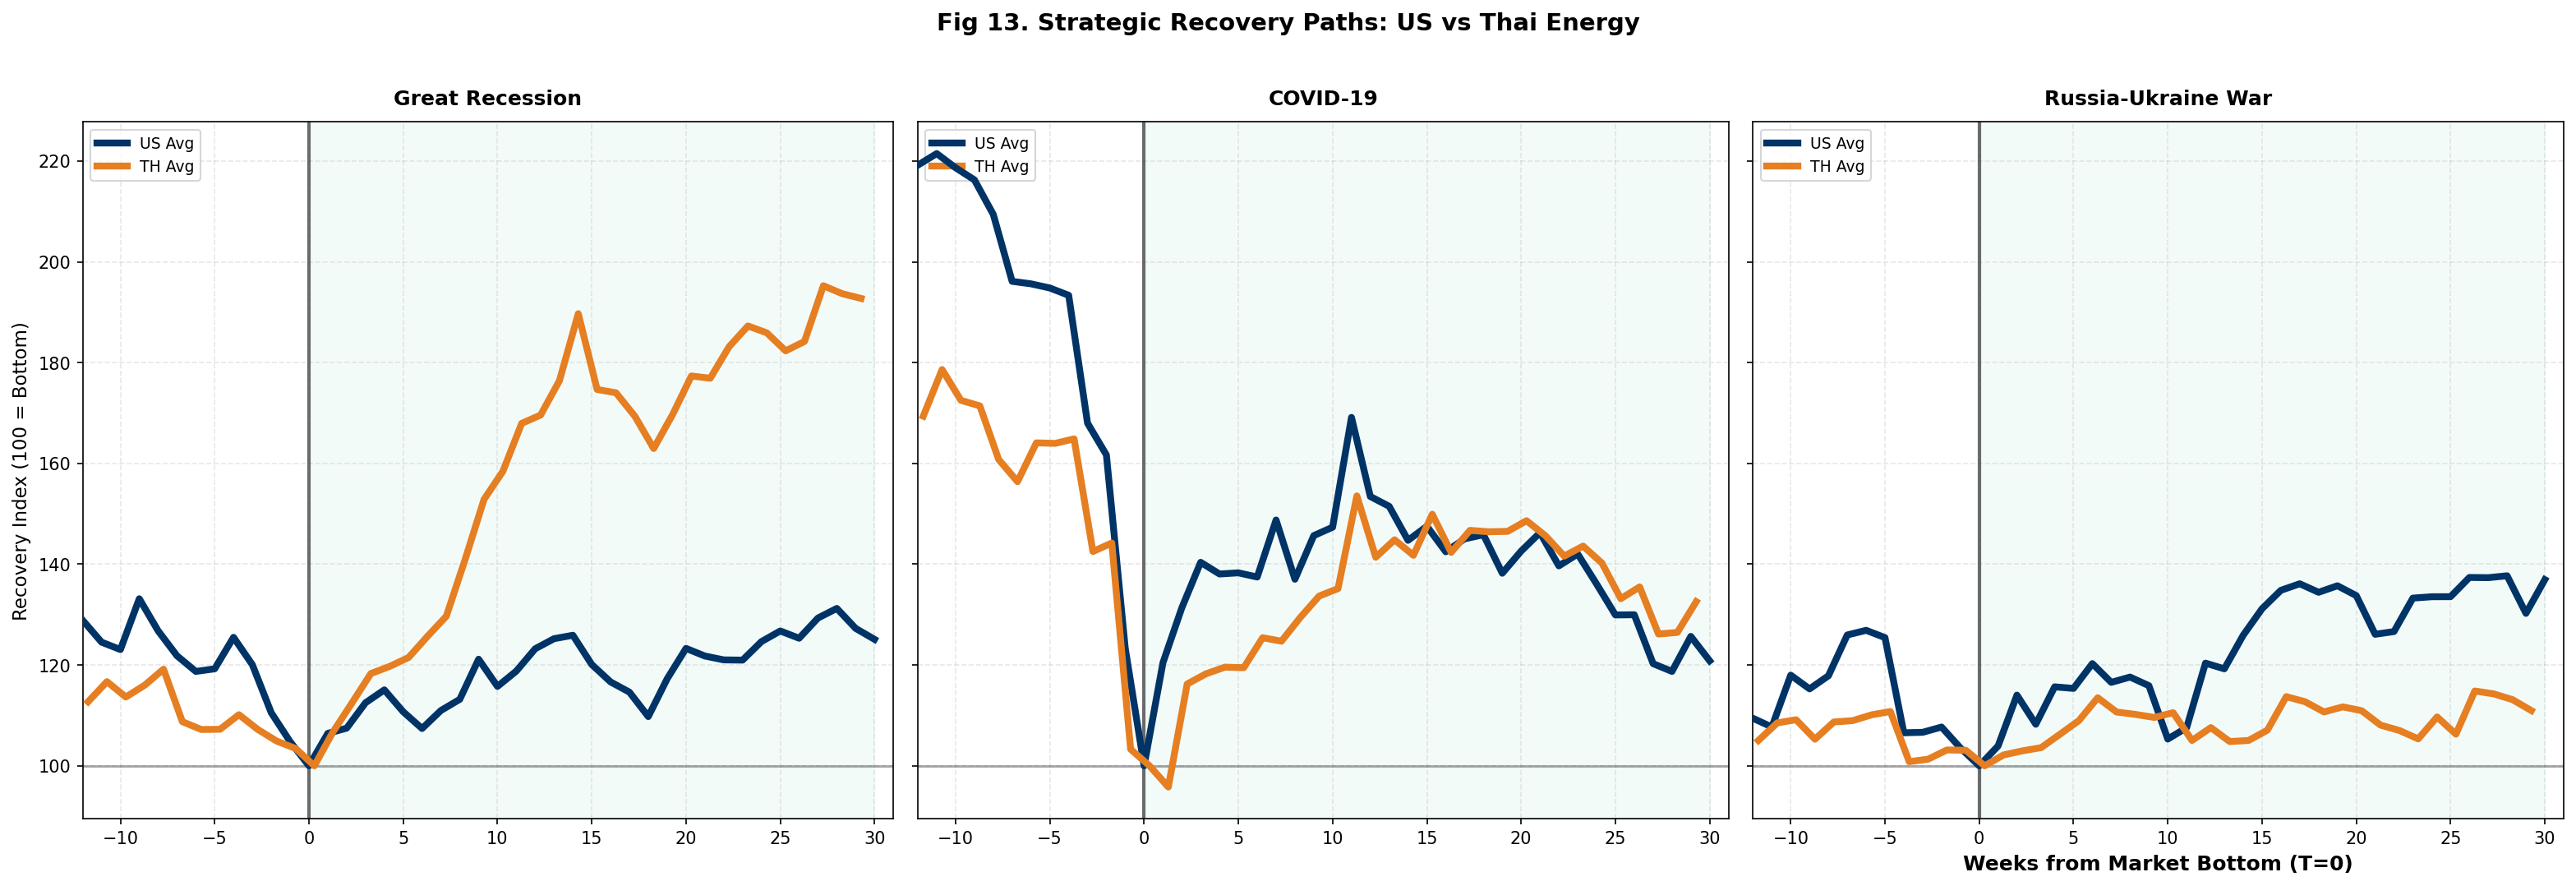

In [15]:
def fig_13_recovery_paths(stocks_df):
    print("\n[Fig 13] Multi-Crisis Recovery Analysis")
    us_tickers = ['XOM','CVX','COP','SHEL','TTE']; th_tickers = ['PTT.BK','PTTEP.BK','PTTGC.BK','BCP.BK','PTG.BK']
    target_crises = ['Great Recession','COVID-19','Russia-Ukraine War']; WB=12; WA=30
    df=stocks_df.copy()
    if 'Date' not in df.columns: df=df.reset_index()
    df['Date']=pd.to_datetime(df['Date'])
    piv=df.pivot_table(index='Date',columns='Ticker',values='Close')
    us_avg_raw=piv[[t for t in us_tickers if t in piv.columns]].mean(axis=1)
    def nvd(s,t):
        v=s.dropna()
        if v.empty: return None
        d=abs(v.index-t); n=v.index[d.argmin()]
        return n if abs((n-t).days)<=7 else None
    fig,axes=plt.subplots(1,len(target_crises),figsize=(7*len(target_crises),7),dpi=150,sharey=True)
    for i,era in enumerate(target_crises):
        ax=axes[i]; ed=df[df['crisis_era']==era]['Date'].unique()
        if len(ed)==0: continue
        eu=us_avg_raw[us_avg_raw.index.isin(ed)].dropna()
        if eu.empty: continue
        tr=eu.idxmin(); ds=tr-pd.Timedelta(weeks=WB); de=tr+pd.Timedelta(weeks=WA)
        mk=(piv.index>=ds)&(piv.index<=de); pd_=piv.index[mk]
        ax.axvspan(0,WA,color='#E8F8F5',alpha=0.5,zorder=0)
        for tks,cm,lb,_ in [(us_tickers,'#003366','US Avg',None),(th_tickers,'#E67E22','TH Avg',None)]:
            bv={}
            for t in tks:
                if t not in piv.columns: continue
                nd=nvd(piv[t],tr)
                if nd and piv[t].loc[nd]!=0: bv[t]=piv[t].loc[nd]
            if bv:
                d2=piv[list(bv.keys())].reindex(pd_)
                nm=(d2/pd.Series(bv)).mean(axis=1).dropna()*100
                if not nm.empty:
                    wn=[(d-tr).days/7 for d in nm.index]
                    ax.plot(wn,nm,color=cm,lw=4,label=lb,zorder=10)
        ax.axvline(0,color='#333',ls='-',lw=2,alpha=0.7); ax.axhline(100,color='#333',lw=1.5,alpha=0.4)
        ax.set_title(f"{era}",fontsize=12,fontweight='bold',pad=10); ax.set_xlim(-WB,WA+1)
        ax.grid(True,ls='--',alpha=0.3); ax.legend(loc='upper left',fontsize=9,frameon=True)
        if i==0: ax.set_ylabel("Recovery Index (100 = Bottom)",fontsize=11)
    plt.suptitle("Fig 13. Strategic Recovery Paths: US vs Thai Energy",fontsize=14,fontweight='bold',y=1.02)
    plt.xlabel("Weeks from Market Bottom (T=0)",fontsize=12,fontweight='bold')
    plt.tight_layout(); save_fig(fig, "13_recovery_paths"); plt.show()

fig_13_recovery_paths(stocks)


#### 📖 Story: "การแข่งขันฟื้นตัว — ใครปีนกลับเร็วกว่า?"

กราฟ 3 ช่องนี้เปรียบเทียบ "เส้นทางการฟื้นตัว" ของกลุ่ม US vs Thai โดยปรับฐาน 100 ที่จุดต่ำสุดของแต่ละวิกฤต (T=0) แล้วดูว่า 30 สัปดาห์ต่อมา ใครปีนกลับได้สูงกว่า เส้นน้ำเงินเข้ม (US Average) และสีส้ม (Thai Average) วิ่งแข่งกันอย่างชัดเจน แถบสีเขียวอ่อนทำเครื่องหมาย "Bullish Recovery Zone" — พื้นที่ทางขวาของ T=0 ที่ราคาเริ่มฟื้น

Pattern ที่สม่ำเสมอคือ — US Energy มักปีนกลับเร็วกว่าและสูงกว่าในทุกวิกฤต สาเหตุหลักคือ "Contrarian Capital" จากนักลงทุนสถาบันทั่วโลกที่เข้าซื้อหุ้น US ก่อน เพราะ Liquidity สูงกว่าและ Track Record ดีกว่า ขณะที่หุ้นไทยต้องรอจนตลาดกลับสู่ Risk-On จริงๆ ก่อนที่เงินต่างชาติจะไหลกลับเข้ามา

**Key Insights:**
- **US Energy ฟื้นตัวเร็วกว่า Thai ในทุกวิกฤต** → ถ้าต้องเลือกฝั่งเดียวในช่วง Recovery ให้เลือก US
- COVID-19 Recovery เร็วที่สุด (V-Shape) | GFC Recovery ช้าที่สุด (U-Shape) → ประเภทวิกฤตกำหนดรูปแบบ Recovery
- **จังหวะซื้อที่ดีที่สุด:** เมื่อ VIX เริ่มลดจากจุดสูงสุด + INDPRO เริ่มฟื้น = สัญญาณเข้า


### 📊 Fig 14. บาดแผลลึกสุด — Max Drawdown Analysis



[Fig 14] Max Drawdown: The Deepest Wounds
  Saved: outputs/figures\14_max_drawdown.png


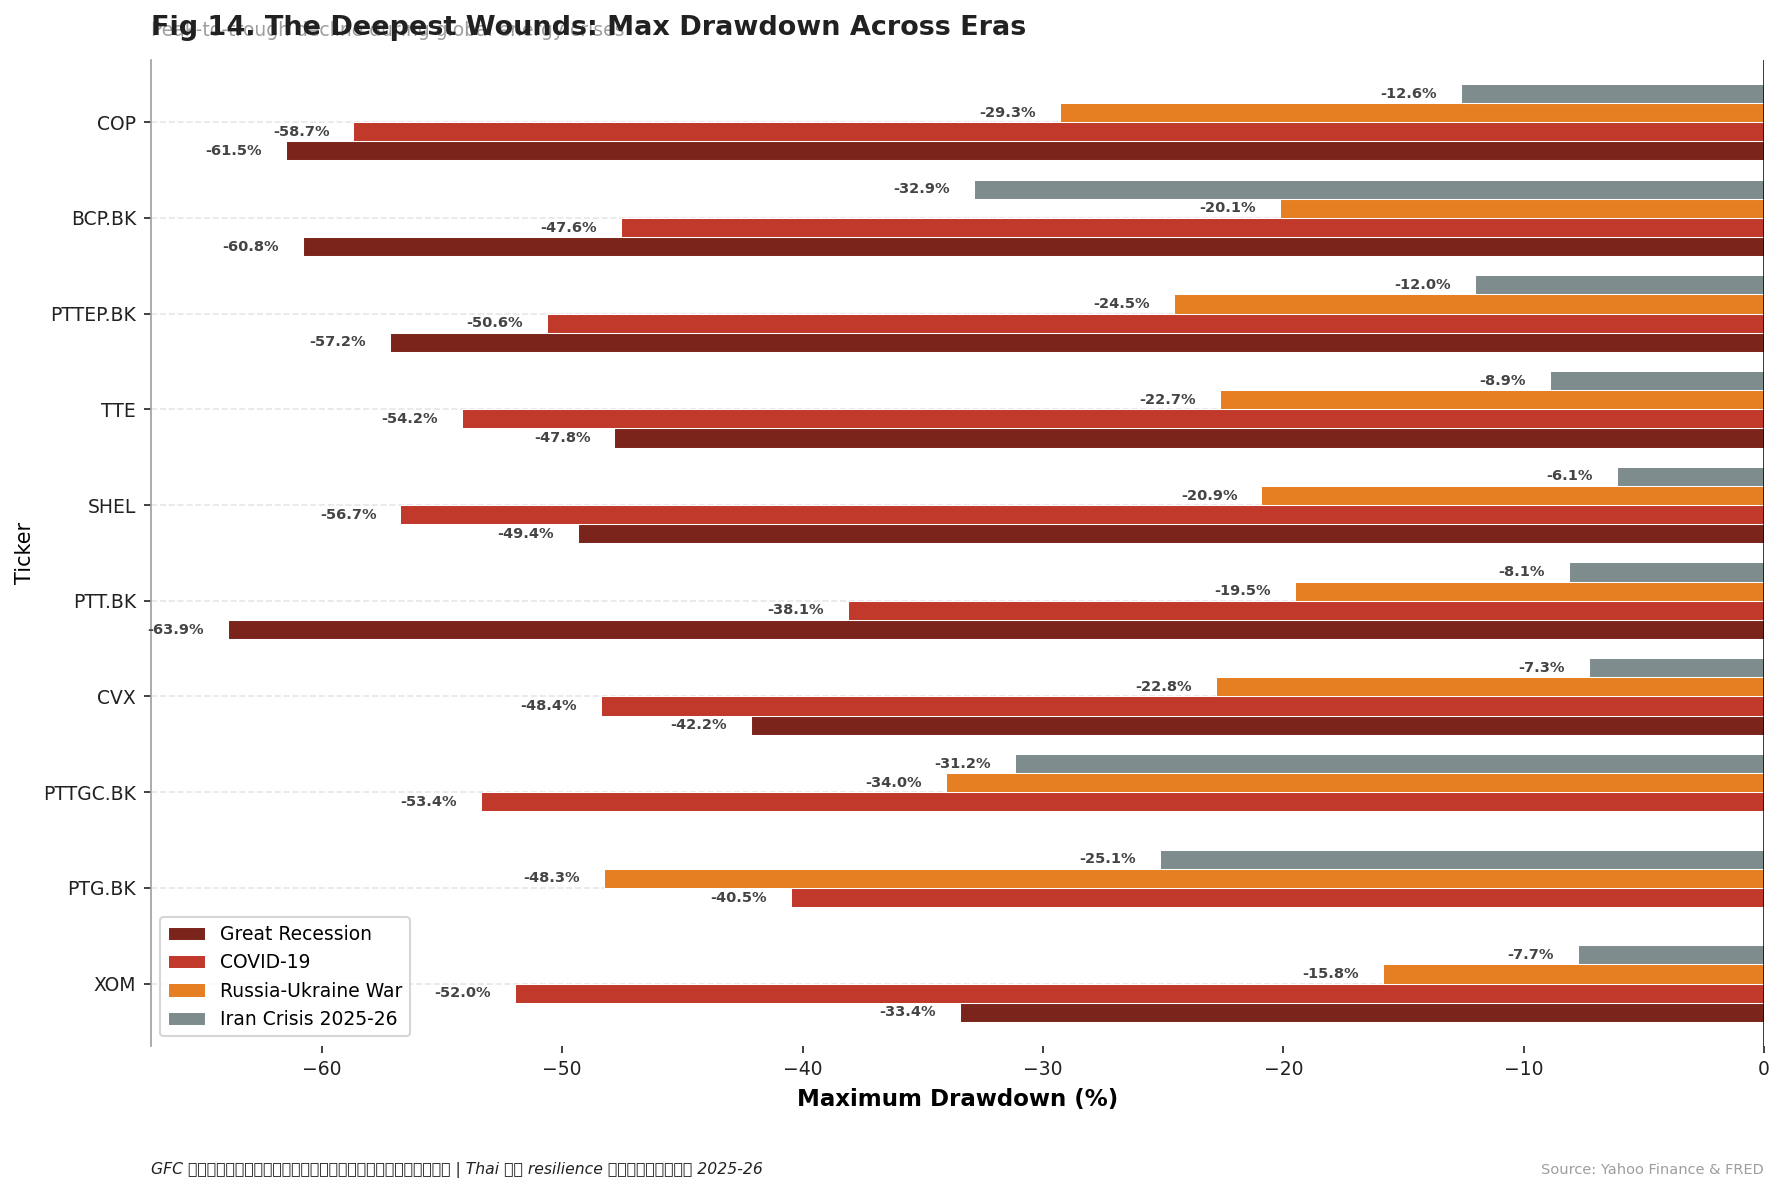

In [16]:
def fig_14_max_drawdown(stocks):
    print("\n[Fig 14] Max Drawdown: The Deepest Wounds")
    crises = ["Great Recession","COVID-19","Russia-Ukraine War","Iran Crisis 2025-26"]; dd_list=[]
    for era in crises:
        sub=stocks[stocks["crisis_era"]==era]
        for t in ALL_STOCKS:
            ts=sub[sub["Ticker"]==t]["Close"]
            if len(ts)<2: dd_list.append({"Ticker":t,"Crisis":era,"Max_Drawdown":0}); continue
            pk=ts.expanding().max(); dd=((ts-pk)/pk).min()*100
            dd_list.append({"Ticker":t,"Crisis":era,"Max_Drawdown":dd})
    dd_df=pd.DataFrame(dd_list); dd_piv=dd_df.pivot(index="Ticker",columns="Crisis",values="Max_Drawdown")
    dd_piv["Mean_DD"]=dd_piv.mean(axis=1); dd_piv=dd_piv.sort_values("Mean_DD",ascending=False).drop(columns="Mean_DD")
    dd_piv=dd_piv[crises]
    fig,ax=plt.subplots(figsize=(12,8),dpi=150)
    colors=["#7B241C","#C0392B","#E67E22","#7F8C8D"]
    dd_piv.plot.barh(ax=ax,color=colors,width=0.8,edgecolor="white",linewidth=0.5)
    for p in ax.patches:
        w=p.get_width()
        if w<-1: ax.text(w-1,p.get_y()+p.get_height()/2,f'{w:.1f}%',va='center',ha='right',fontsize=7,color='#444',fontweight='bold')
    ax.set_xlabel("Maximum Drawdown (%)",fontsize=11,fontweight='bold'); ax.axvline(0,color='black',lw=1.2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False); ax.spines['bottom'].set_visible(False)
    style_ax(ax, title="The Deepest Wounds: Max Drawdown Across Eras",
             subtitle="Peak-to-trough decline during global energy crises",
             caption="GFC สร้างความเสียหายรุนแรงที่สุด | Thai มี resilience มากกว่าใน 2025-26", fig_num=14)
    ax.legend(loc="lower left",frameon=True,facecolor='white',fontsize=9)
    plt.tight_layout(); save_fig(fig, "14_max_drawdown"); plt.show()

fig_14_max_drawdown(stocks)


#### 📖 Story: "บาดแผลที่ต้องจำ — เมื่อพอร์ตหายไปครึ่ง"

Max Drawdown คือ "บาดแผลลึกสุด" ที่พอร์ตเคยเจอ — วัดจากจุดสูงสุดถึงจุดต่ำสุดในแต่ละช่วงวิกฤต กราฟนี้แสดงบาดแผลของหุ้นพลังงานแต่ละตัวใน 4 วิกฤต และเผยให้เห็นว่า Great Recession (สีแดงเข้มสุด) คือ worst case scenario ที่แท้จริง — หุ้นบางตัวร่วงมากกว่า 60% จากจุดสูงสุด หมายความว่าถ้าลงทุน 1 ล้านบาท เหลือไม่ถึง 4 แสนบาท

COVID-19 (สีแดง) สร้าง drawdown รุนแรงสำหรับหุ้น US มากกว่าไทย — เพราะหุ้น US มี valuation สูงกว่าจึงมีที่ "ตก" มากกว่า ในทางตรงข้าม วิกฤตอิหร่าน 2025-26 (สีเทา) เป็นวิกฤตที่ "เจ็บน้อยที่สุด" เพราะตลาดเริ่มมี Memory Effect จากวิกฤตก่อนหน้า — นักลงทุนรู้วิธีรับมือดีขึ้น

**Key Insights:**
- **GFC = Worst Case:** ต้องใช้เป็น Stress Test Scenario สำหรับพอร์ตทุกพอร์ต
- หุ้นที่มี Max Drawdown < 30% ในทุกวิกฤต = "ตัวที่ต้องมีในพอร์ต" เพราะผ่านด่านที่ยากที่สุดได้
- **Position Sizing Rule:** ถ้ารับ Drawdown ได้ไม่เกิน 20% → อย่าใส่เงินในหุ้นตัวเดียวเกิน 30% ของพอร์ต


---
# 🎯 ACT 5: THE STRATEGY — กลยุทธ์การลงทุนหุ้นพลังงาน
### "จากข้อมูล 18 กราฟ → สู่แผนปฏิบัติจริง"

บทสุดท้ายจะสังเคราะห์ทุกอย่างเป็น **กรอบกลยุทธ์การลงทุน** ที่ครอบคลุม: เลือกระดับ Beta, พลังทบต้นระยะยาว, ประสิทธิภาพต่อความเสี่ยง (Sharpe), และแผนที่ยุทธศาสตร์ Risk-Return


### 📊 Fig 15. เลือก Beta ให้เหมาะกับตัวเอง — COP vs PTTEP



[Fig 15] Upstream Beta: COP vs PTTEP
  Saved: outputs/figures\15_beta_selection.png


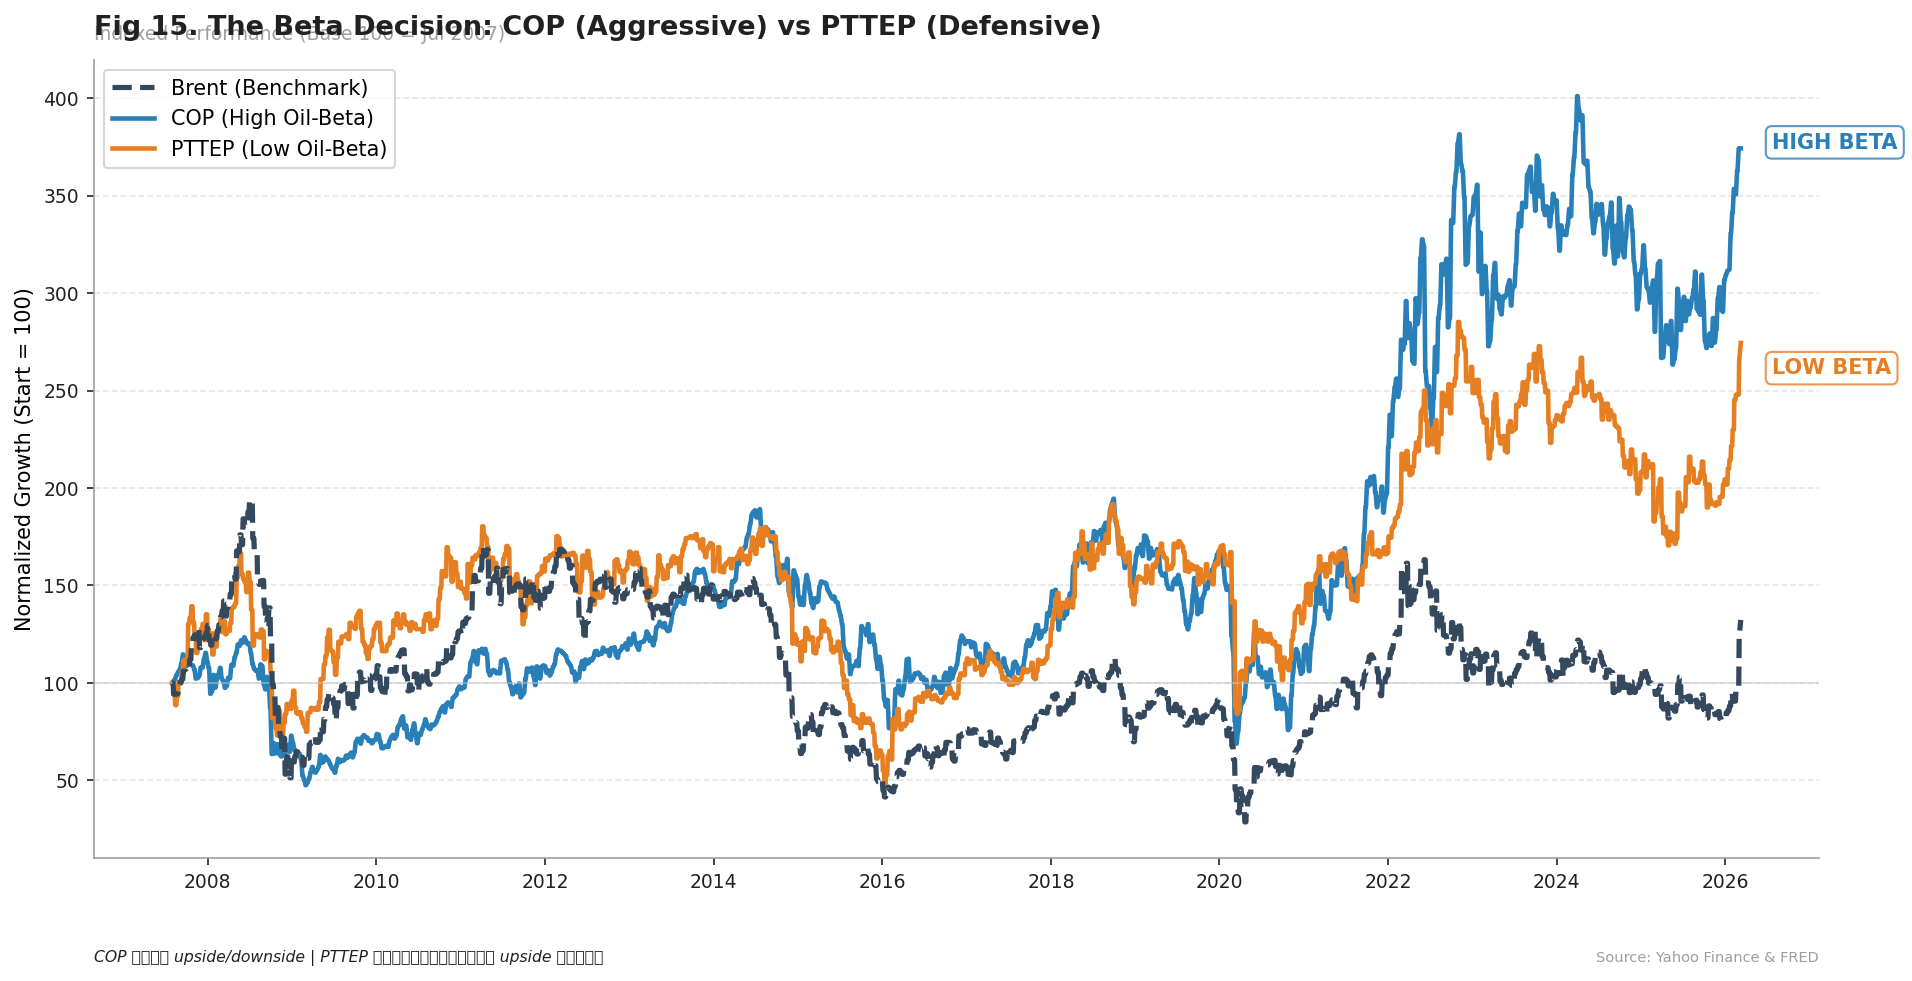

In [17]:
def fig_15_beta_selection(stocks):
    print("\n[Fig 15] Upstream Beta: COP vs PTTEP")
    try:
        tickers=["PTTEP.BK","COP","BZ=F"]; raw=pivot_close(stocks,tickers)
        raw.columns=['Brent_Crude','COP_US','PTTEP_TH']
        al=raw.dropna().copy()
        if al.empty: return
        ix=(al/al.iloc[0])*100
        fig,ax=plt.subplots(figsize=(14,7),dpi=150)
        ax.plot(ix.index,ix["Brent_Crude"],color='#34495E',lw=2.5,ls='--',label="Brent (Benchmark)",zorder=3)
        ax.plot(ix.index,ix["COP_US"],color='#2980B9',lw=2.2,label="COP (High Oil-Beta)",zorder=2)
        ax.plot(ix.index,ix["PTTEP_TH"],color='#E67E22',lw=2.2,label="PTTEP (Low Oil-Beta)",zorder=2)
        ld=ix.index[-1]
        ax.annotate('HIGH BETA',xy=(ld,ix["COP_US"].iloc[-1]),xytext=(15,0),textcoords='offset points',fontsize=10,
                   fontweight='bold',color='#2980B9',bbox=dict(boxstyle='round,pad=0.3',fc='white',ec='#2980B9',alpha=0.8))
        ax.annotate('LOW BETA',xy=(ld,ix["PTTEP_TH"].iloc[-1]),xytext=(15,-15),textcoords='offset points',fontsize=10,
                   fontweight='bold',color='#E67E22',bbox=dict(boxstyle='round,pad=0.3',fc='white',ec='#E67E22',alpha=0.8))
        ax.axhline(100,color='#BDC3C7',lw=1,alpha=0.5)
        style_ax(ax, title="The Beta Decision: COP (Aggressive) vs PTTEP (Defensive)",
                 subtitle=f"Indexed Performance (Base 100 = {ix.index[0].strftime('%b %Y')})",
                 caption="COP ขยาย upside/downside | PTTEP เสถียรกว่าแต่ upside จำกัด", fig_num=15)
        ax.set_ylabel("Normalized Growth (Start = 100)"); ax.legend(loc="upper left",frameon=True,facecolor='white')
        plt.tight_layout(rect=[0,0.05,0.92,1]); save_fig(fig,"15_beta_selection"); plt.show()
    except Exception as e: print(f"❌ Error: {e}")

fig_15_beta_selection(stocks)


#### 📖 Story: "Beta คือทางเลือก ไม่ใช่โชคชะตา"

กราฟนี้คือ "กระจก" ที่บังคับให้นักลงทุนตอบคำถามกับตัวเอง: "ฉันรับความเสี่ยงได้แค่ไหน?" COP (สีน้ำเงิน) เป็น High Oil-Beta ที่ "ขยาย" การเคลื่อนไหวของ Brent ไปทั้งสองทิศทาง — เมื่อน้ำมันขึ้น COP ขึ้นมากกว่า เมื่อน้ำมันลง COP ลงมากกว่า ในทางตรงข้าม PTTEP (สีส้ม) เป็น Low Oil-Beta ที่เคลื่อนไหวอย่างพอประมาณกว่า

การเลือก Beta ไม่ใช่เรื่องของ "ถูก" หรือ "ผิด" แต่คือเรื่องของ "เหมาะกับตัวเอง" — นักลงทุนที่มี Time Horizon ยาว รับ Drawdown ได้มาก และเชื่อมั่นใน Oil Supercycle ควรเลือก COP ส่วนนักลงทุนที่ต้องการ Steady Income, รับ Volatility ไม่ไหว หรือต้องการ Exposure พลังงานแบบไม่เสี่ยงเกินไป ควรเลือก PTTEP

**Key Insights:**
- **High-Beta (COP):** เหมาะสำหรับ Tactical Trading, ช่วงน้ำมันขาขึ้น, นักลงทุนที่รับ Drawdown > 40% ได้
- **Low-Beta (PTTEP):** เหมาะสำหรับ Core Holding ระยะยาว, นักลงทุนที่ต้องการ Dividend + Capital Appreciation แบบพอดี
- **ผสมได้:** พอร์ตที่ดีอาจมีทั้ง COP 40% + PTTEP 30% + PTG 30% เพื่อ Diversify Beta


### 📊 Fig 16. พลังทบต้น — US Giants vs Thai Energy Sector



[Fig 16] Wealth Creation Power
  Saved: outputs/figures\16_wealth_creation.png


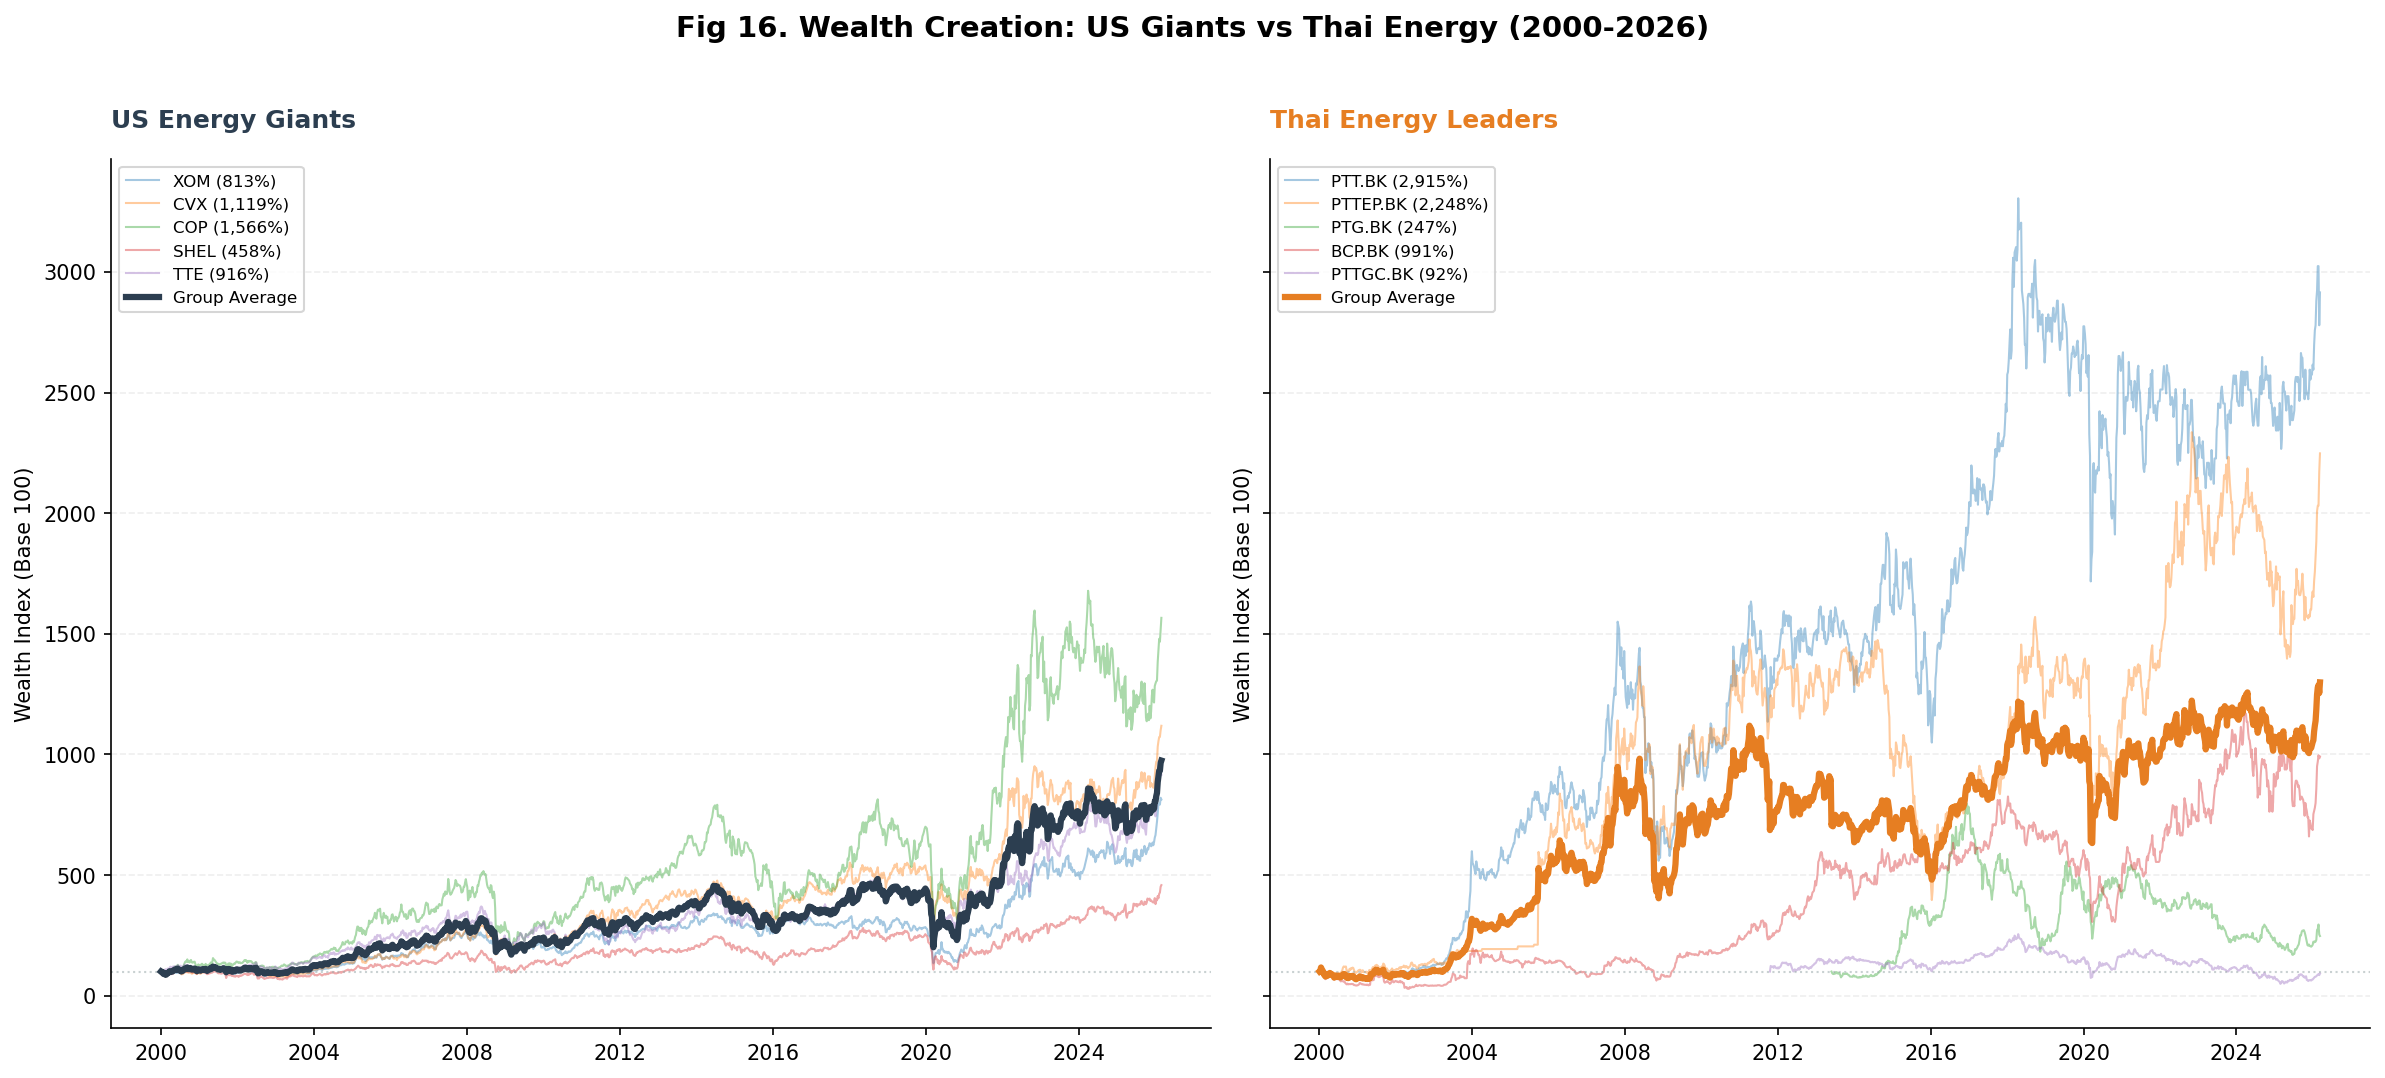

In [18]:
def fig_16_wealth_creation(stocks):
    print("\n[Fig 16] Wealth Creation Power")
    groups=[(US_TICKERS,"US Energy Giants",'#2C3E50'),(TH_TICKERS,"Thai Energy Leaders",'#E67E22')]
    fig,axes=plt.subplots(1,2,figsize=(16,7),sharey=True,dpi=150)
    for i,(tks,title,color) in enumerate(groups):
        ax=axes[i]; all_cum=[]
        for t in tks:
            sub=stocks[stocks["Ticker"]==t].copy()
            if sub.empty: continue
            sub['Date']=pd.to_datetime(sub.get('Date',sub.index)); sub=sub.set_index('Date').sort_index()
            cr=(1+sub["Weekly_Return"].fillna(0)).cumprod()*100; fv=cr.iloc[-1]; all_cum.append(cr)
            ax.plot(cr.index,cr,lw=1,alpha=0.4,label=f"{t} ({fv:,.0f}%)")
        if all_cum:
            ga=pd.concat(all_cum,axis=1).mean(axis=1)
            ax.plot(ga.index,ga,lw=3,color=color,label="Group Average",zorder=5)
        ax.set_title(title,fontsize=12,fontweight="bold",color=color,loc="left",pad=15)
        ax.legend(frameon=True,fontsize=8,loc="upper left",facecolor='white',framealpha=0.8)
        ax.set_ylabel("Wealth Index (Base 100)"); ax.axhline(100,color='#95A5A6',ls=':',lw=1,alpha=0.5)
        for s in ["top","right"]: ax.spines[s].set_visible(False)
        ax.grid(axis='y',linestyle='--',alpha=0.2)
    plt.suptitle("Fig 16. Wealth Creation: US Giants vs Thai Energy (2000-2026)",fontsize=14,fontweight="bold",y=1.02)
    plt.tight_layout(); save_fig(fig,"16_wealth_creation"); plt.show()

fig_16_wealth_creation(stocks)


#### 📖 Story: "ถ้าลงทุน $100 เมื่อ 26 ปีก่อน — วันนี้เหลือเท่าไร?"

นี่คือคำถามที่ทรงพลังที่สุดในโลกการลงทุน — และกราฟนี้ตอบด้วยตัวเลขจริง แผงซ้าย (US Giants) แสดงให้เห็นว่า $100 ที่ลงทุนในกลุ่มหุ้นพลังงาน US ตั้งแต่ปี 2000 เติบโตเป็นหลายร้อยเปอร์เซ็นต์ ขณะที่แผงขวา (Thai Leaders) แม้จะเติบโตเช่นกัน แต่ในอัตราที่ช้ากว่า ส่วนต่างนี้คือ "ราคาของการอยู่ในตลาดที่ใหญ่กว่า" — ตลาดสหรัฐฯ ให้ Premium ด้านสภาพคล่อง, การเข้าถึงนักลงทุนทั่วโลก, และมาตรฐานการกำกับดูแลที่สูงกว่า

เส้นหนา (Group Average) คือหัวใจของกราฟ — มันแสดง "พลังของ Diversification ภายในกลุ่ม" ว่าถ้าซื้อหุ้นทุกตัวในกลุ่มเท่าๆ กัน ผลลัพธ์จะเป็นอย่างไร สังเกตว่าเส้นเฉลี่ย US เป็นเส้นที่ "ทนทาน" ที่สุด — แม้หุ้นบางตัวจะร่วง แต่ค่าเฉลี่ยไม่เคยหายไปมากจนน่าเป็นห่วง นี่คือพลังของ "Equal-Weight Portfolio"

**Key Insights:**
- US Energy สร้าง Wealth ได้มากกว่า Thai ในระยะยาว → **ผลจากตลาดทุนที่ลึกกว่าและ Capital Efficiency ที่ดีกว่า**
- "พลังทบต้น" (Compounding) ทำงานดีที่สุดเมื่อ **ไม่ขายในจังหวะวิกฤต** — ทุกครั้งที่ขายตอน Panic คือการสูญเสีย Compounding
- **กลยุทธ์ที่ดีที่สุด:** Equal-Weight Portfolio + Rebalance ปีละครั้ง → ง่ายแต่ทรงพลัง


### 📊 Fig 17. Sharpe Ratio — ใครให้ผลตอบแทนคุ้มค่าความเสี่ยง?



[Fig 17] Sharpe Ratio Heatmap
  Saved: outputs/figures\17_sharpe_heatmap.png


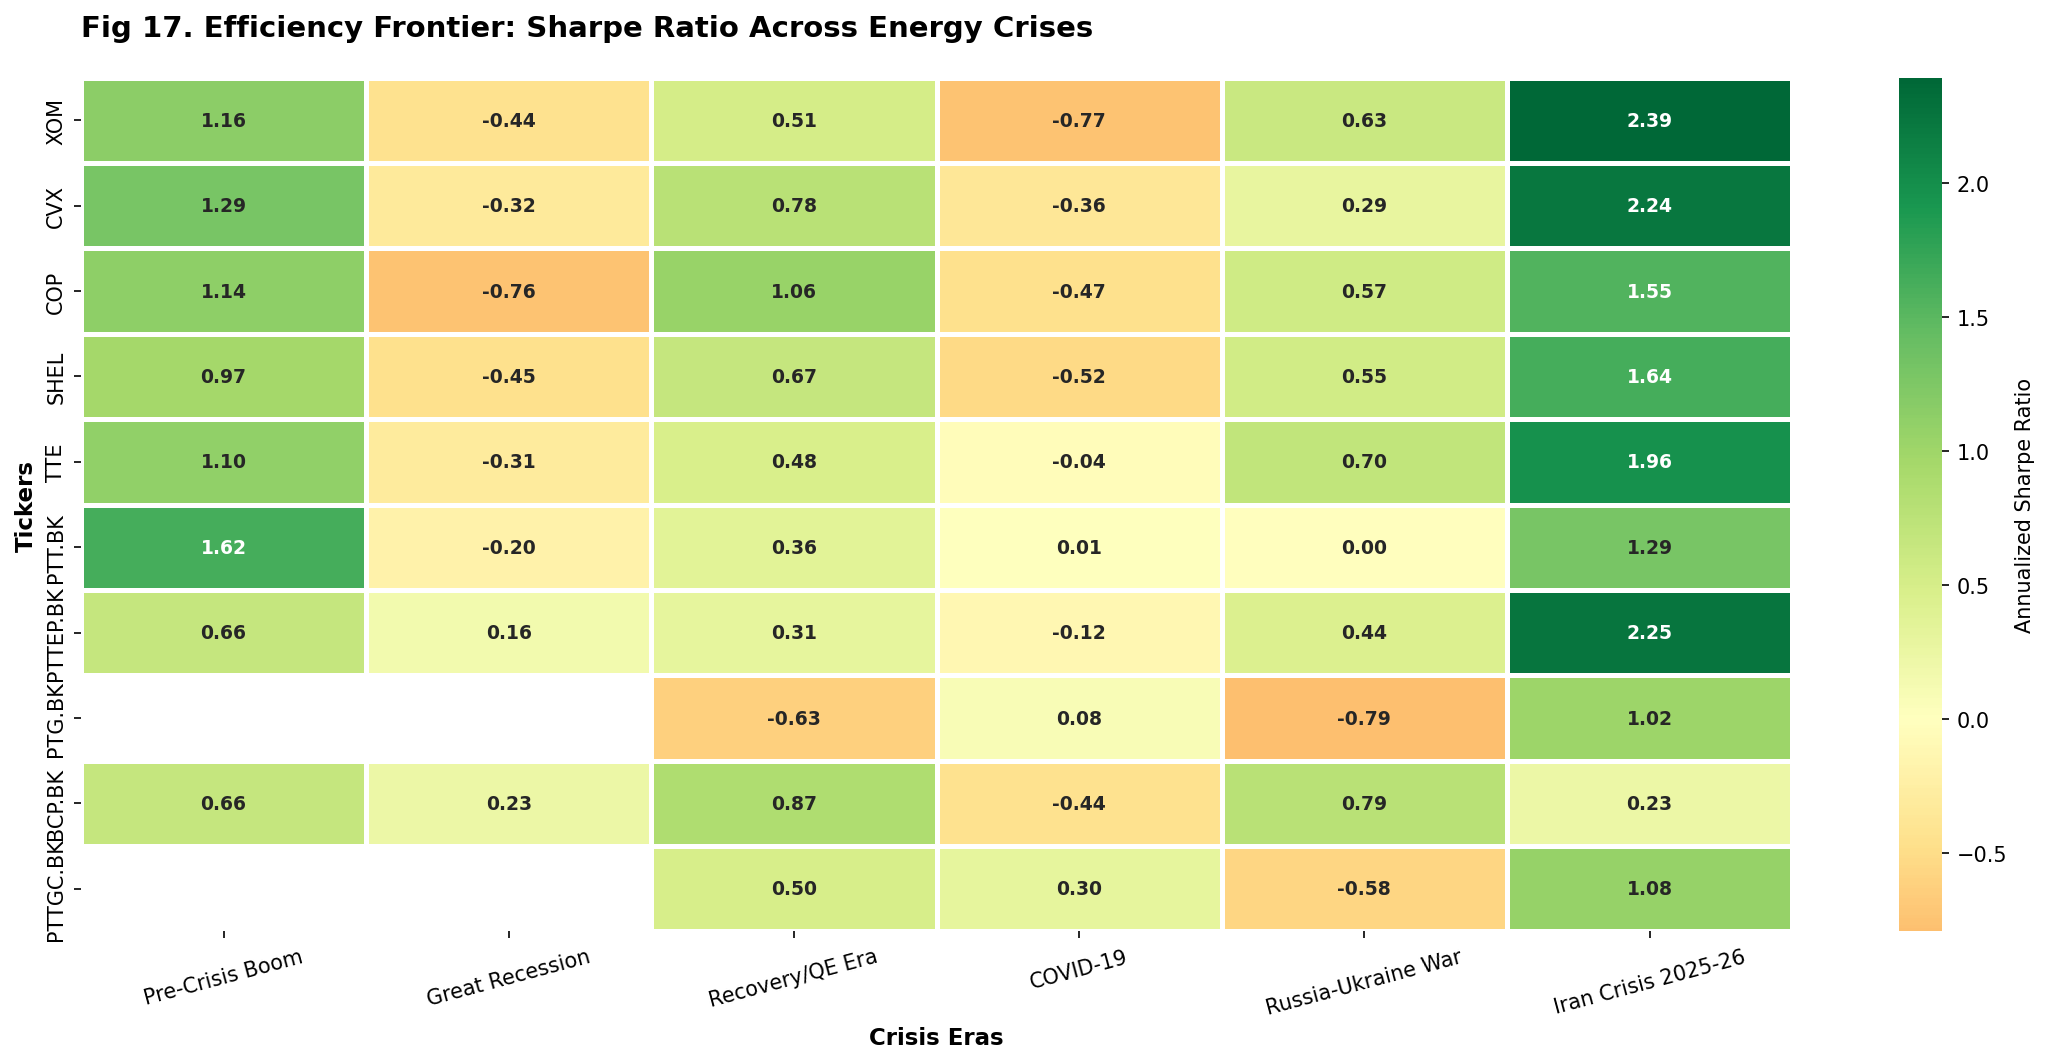

In [19]:
def fig_17_sharpe_heatmap(stocks):
    print("\n[Fig 17] Sharpe Ratio Heatmap")
    eras=["Pre-Crisis Boom","Great Recession","Recovery/QE Era","COVID-19","Russia-Ukraine War","Iran Crisis 2025-26"]
    rf=0.03/52; results=[]
    for era in eras:
        sub=stocks[stocks["crisis_era"]==era]
        for t in ALL_STOCKS:
            rets=sub[sub["Ticker"]==t]["Weekly_Return"].dropna()
            if len(rets)<10: continue
            sr=(rets.mean()-rf)/rets.std()*np.sqrt(52)
            results.append({"Ticker":t,"Crisis":era,"Sharpe":sr})
    sr_df=pd.DataFrame(results); sr_piv=sr_df.pivot(index="Ticker",columns="Crisis",values="Sharpe")
    ordered=[t for t in ALL_STOCKS if t in sr_piv.index]; sr_piv=sr_piv.reindex(index=ordered,columns=eras)
    fig,ax=plt.subplots(figsize=(15,8),dpi=150)
    sns.heatmap(sr_piv,annot=True,fmt=".2f",cmap="RdYlGn",center=0,ax=ax,linewidths=1.5,linecolor='white',
               cbar_kws={"label":"Annualized Sharpe Ratio"},annot_kws={"size":9,"weight":"bold"})
    ax.set_title("Fig 17. Efficiency Frontier: Sharpe Ratio Across Energy Crises",fontsize=14,fontweight="bold",loc="left",pad=20)
    ax.set_xlabel("Crisis Eras",fontsize=11,fontweight="bold"); ax.set_ylabel("Tickers",fontsize=11,fontweight='bold')
    plt.xticks(rotation=15)
    plt.tight_layout(rect=[0,0.05,1,0.95]); save_fig(fig,"17_sharpe_heatmap"); plt.show()

fig_17_sharpe_heatmap(stocks)


#### 📖 Story: "ไม่ใช่แค่กำไร — แต่ต้องกำไรคุ้มค่ากับความเสี่ยง"

Sharpe Ratio คือ "เข็มทิศของนักลงทุนมืออาชีพ" — มันวัดว่าหุ้นให้ผลตอบแทนเท่าไรต่อ 1 หน่วยความเสี่ยงที่รับ (Sharpe > 1.0 = ยอดเยี่ยม, < 0 = แย่กว่าฝากธนาคาร) Heatmap นี้แสดง Sharpe ของทุกหุ้นในทุกยุค — สีเขียวเข้ม = ดีเยี่ยม, สีแดงเข้ม = หายนะ

Pattern ที่ชัดเจนคือ Great Recession เป็น "Red Zone" สำหรับทุกตัว — ไม่มีหุ้นพลังงานตัวไหนให้ Sharpe เป็นบวกในช่วงนั้น แต่ในช่วง Russia-Ukraine War กลับเป็น "Green Zone" สำหรับ US Upstream (COP, XOM) เพราะราคาน้ำมันพุ่งแต่ Volatility ไม่สูงเท่า GFC สิ่งนี้ยืนยันว่า "ไม่ใช่ทุกวิกฤตที่เสียหาย" — วิกฤตแบบ Supply Shock อาจเป็น **โอกาสที่ให้ Risk-Adjusted Return ดีมาก**

**Key Insights:**
- **Sharpe > 1.0 = เป้าหมาย** → มองหาหุ้นที่เข้าเงื่อนไขนี้ในยุคปัจจุบัน
- GFC เป็น "Red Zone" สำหรับทุกตัว → ถ้าเกิด Systemic Risk ทำนองนี้อีก **ไม่มีที่หลบ** ในกลุ่มพลังงาน
- US Upstream (COP, XOM) มี Sharpe ดีกว่า Thai ในเกือบทุกยุค → **ยืนยัน Alpha ของตลาดสหรัฐฯ**


### 📊 Fig 18. แผนที่ยุทธศาสตร์สุดท้าย — Risk-Return Frontier



[Fig 18] War-Time Strategic Frontier
  Saved: outputs/figures\18_strategic_frontier.png


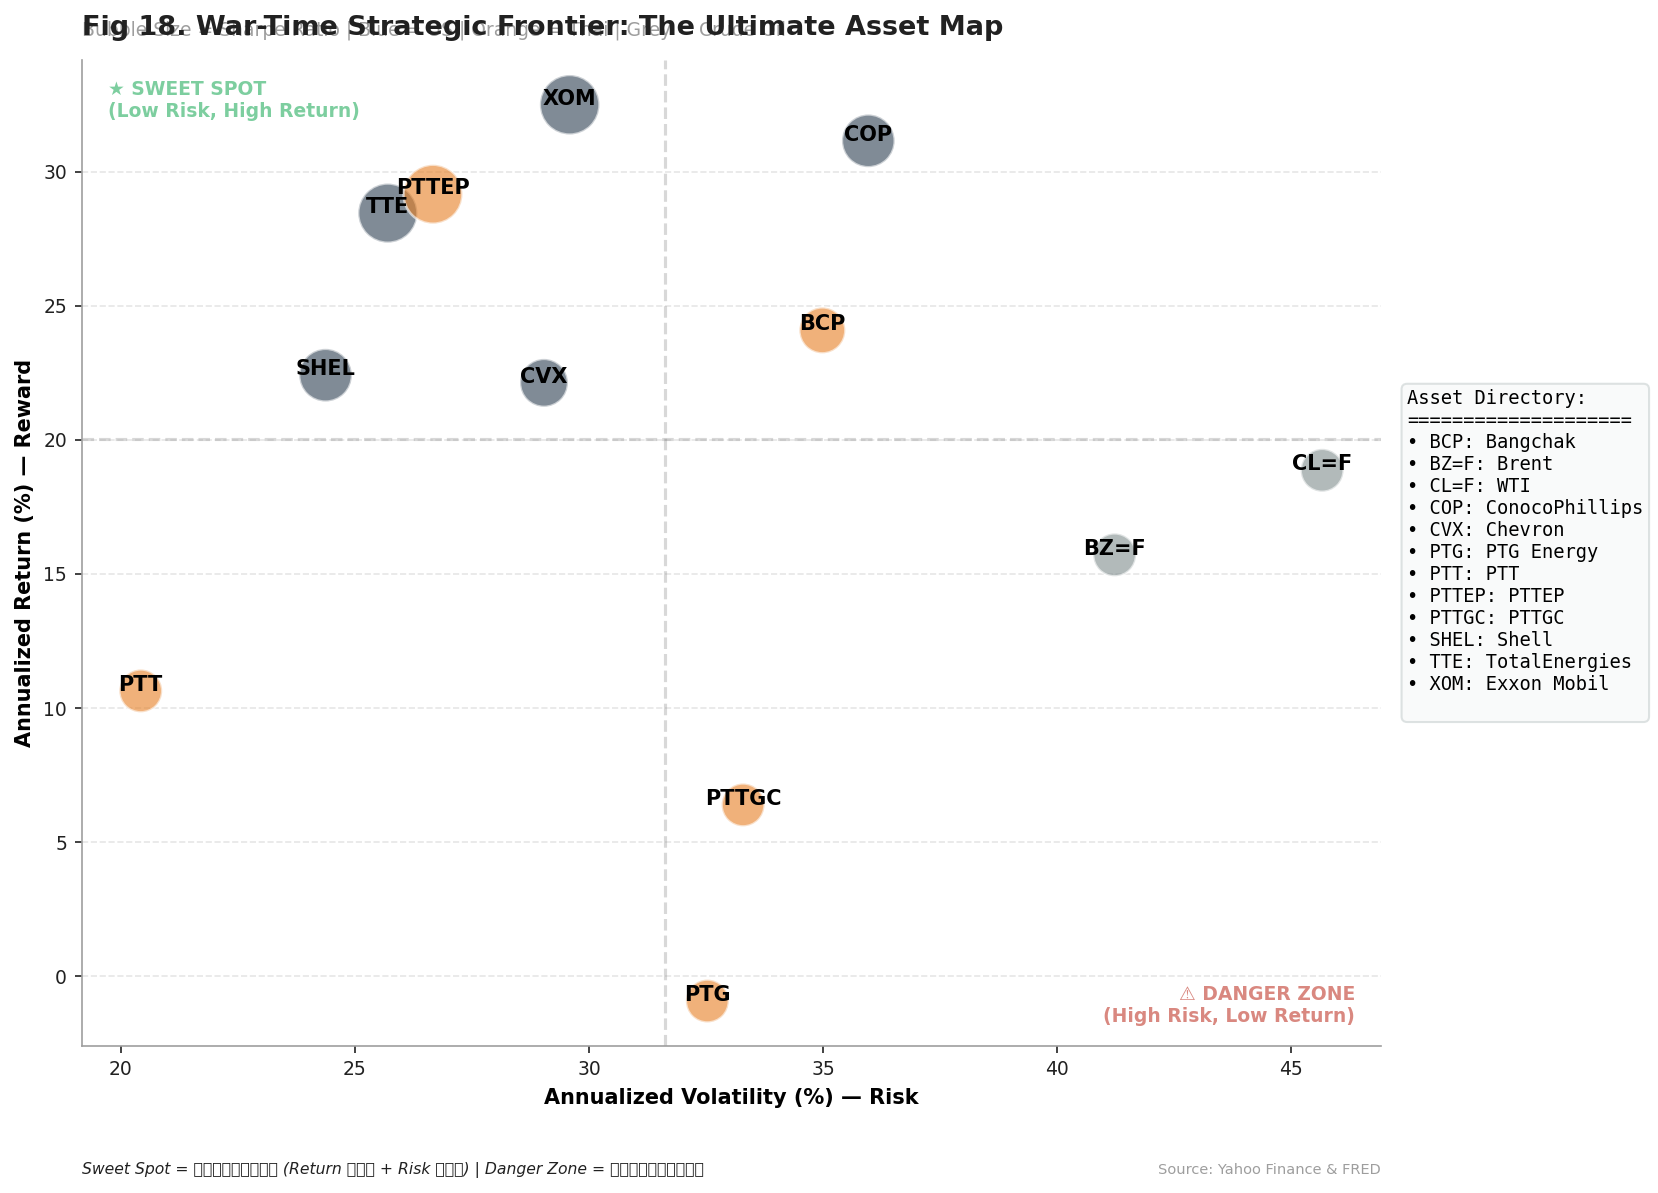

In [20]:
def fig_18_strategic_frontier(stocks):
    print("\n[Fig 18] War-Time Strategic Frontier")
    try:
        from adjustText import adjust_text; HA=True
    except ImportError:
        try:
            from adjust_text import adjust_text; HA=True
        except ImportError: HA=False
    war_eras=["Russia-Ukraine War","Iran Crisis 2025-26"]; rf=0.04
    cn={"BZ=F":"Brent","CL=F":"WTI","XOM":"Exxon Mobil","CVX":"Chevron","COP":"ConocoPhillips",
        "SHEL":"Shell","TTE":"TotalEnergies","PTT.BK":"PTT","PTTEP.BK":"PTTEP",
        "PTTGC.BK":"PTTGC","BCP.BK":"Bangchak","PTG.BK":"PTG Energy"}
    results=[]
    for t in stocks['Ticker'].unique():
        sub=stocks[(stocks["Ticker"]==t)&(stocks["crisis_era"].isin(war_eras))]
        rets=sub["Weekly_Return"].dropna()
        if len(rets)<8: continue
        ar=rets.mean()*52*100; av=rets.std()*np.sqrt(52)*100; sr=(rets.mean()*52-rf)/(rets.std()*np.sqrt(52))
        results.append({"Ticker":t,"Ann_Return":ar,"Ann_Vol":av,"Sharpe":sr})
    res=pd.DataFrame(results)
    fig,ax=plt.subplots(figsize=(14,8),dpi=150)
    def gc(t):
        if t in ["BZ=F","CL=F"]: return "#7F8C8D"
        return "#2C3E50" if ".BK" not in t else "#E67E22"
    res['Color']=res['Ticker'].apply(gc)
    ax.scatter(res["Ann_Vol"],res["Ann_Return"],s=res["Sharpe"].clip(lower=0.5)*850,c=res["Color"],alpha=0.6,edgecolors='white',linewidths=1.2)
    texts=[]
    for _,r in res.iterrows():
        lb=r["Ticker"].replace('.BK','')
        texts.append(ax.text(r["Ann_Vol"],r["Ann_Return"],lb,fontsize=10,fontweight='bold',ha='center'))
    if HA: adjust_text(texts,arrowprops=dict(arrowstyle='->',color='grey',lw=0.5),ax=ax)
    mr=res["Ann_Return"].mean(); mv=res["Ann_Vol"].mean()
    ax.axhline(mr,color='grey',ls='--',alpha=0.3); ax.axvline(mv,color='grey',ls='--',alpha=0.3)
    ax.text(0.02,0.98,"★ SWEET SPOT\n(Low Risk, High Return)",transform=ax.transAxes,fontsize=9,va='top',color='#27AE60',fontweight='bold',alpha=0.6)
    ax.text(0.98,0.02,"⚠️ DANGER ZONE\n(High Risk, Low Return)",transform=ax.transAxes,fontsize=9,va='bottom',ha='right',color='#C0392B',fontweight='bold',alpha=0.6)
    dt="Asset Directory:\n"+"="*20+"\n"
    for _,r in res.sort_values("Ticker").iterrows():
        dt+=f"• {r['Ticker'].replace('.BK','')}: {cn.get(r['Ticker'],r['Ticker'])}\n"
    ax.text(1.02,0.5,dt,transform=ax.transAxes,fontsize=9,va='center',family='monospace',
           bbox=dict(boxstyle='round',facecolor='#F8F9F9',alpha=0.8,edgecolor='#D5DBDB'))
    ax.set_xlabel("Annualized Volatility (%) — Risk",fontweight='bold')
    ax.set_ylabel("Annualized Return (%) — Reward",fontweight='bold')
    style_ax(ax, title="War-Time Strategic Frontier: The Ultimate Asset Map",
             subtitle="Bubble Size = Sharpe Ratio | Blue = US | Orange = Thai | Grey = Crude Oil",
             caption="Sweet Spot = มุมซ้ายบน (Return สูง + Risk ต่ำ) | Danger Zone = มุมขวาล่าง", fig_num=18)
    plt.tight_layout(rect=[0,0,0.80,1]); save_fig(fig,"18_strategic_frontier"); plt.show()

fig_18_strategic_frontier(stocks)


#### 📖 Story: "แผนที่ขุมทรัพย์ — จุดที่ดีที่สุดอยู่ตรงไหน?"

กราฟนี้คือ "แผนที่ยุทธศาสตร์ขั้นสุดท้าย" ที่รวมทุกมิติไว้ในภาพเดียว — แกนนอน = ความเสี่ยง (Volatility), แกนตั้ง = ผลตอบแทน (Return), ขนาดวงกลม = Sharpe Ratio (ความคุ้มค่า), สี = กลุ่มสินทรัพย์ เส้นประแบ่งกราฟเป็น 4 ส่วน — มุมซ้ายบน (Sweet Spot) คือ "ดินแดนศักดิ์สิทธิ์" ที่นักลงทุนทุกคนต้องการอยู่: Return สูง + Risk ต่ำ ส่วนมุมขวาล่าง (Danger Zone) คือที่ที่ไม่มีใครอยากไป: Risk สูง + Return ต่ำ

ในช่วงสงคราม (Russia-Ukraine + Iran Crisis) สินทรัพย์ที่อยู่ใน Sweet Spot มักเป็น US Upstream (COP, XOM) ที่ให้ผลตอบแทนสูงด้วย Volatility ที่ "ยอมรับได้" ขณะที่สินค้าโภคภัณฑ์ (Brent, WTI) อาจมี Return สูงแต่ Volatility ก็สูงตาม ทำให้ Sharpe Ratio ไม่ได้ดีเท่า ส่วนหุ้นไทยบางตัว (PTG, BCP) อาจอยู่ใน "Safe Zone" — Return ไม่สูงมากแต่ Risk ต่ำ เหมาะกับนักลงทุนที่รับความเสี่ยงน้อย

**Key Insights:**
- **มองหาสินทรัพย์ที่อยู่มุมซ้ายบน** → Return สูง + Risk ต่ำ = Sweet Spot
- **วงกลมใหญ่ = Sharpe สูง** → คุ้มค่าต่อความเสี่ยง ถ้าเห็นวงกลมใหญ่ที่มุมซ้ายบน = "ซื้อเลย"
- แผนที่นี้เปลี่ยนไปตามสถานการณ์ → ต้อง **Re-evaluate ทุก Quarter** เพื่อดูว่าสินทรัพย์เลื่อนไปตรงไหน


---
# 🏆 CONCLUSION: The Energy Investment Framework

## สรุปกลยุทธ์การลงทุนหุ้นพลังงาน — จากข้อมูล 18 กราฟ สู่แผนปฏิบัติจริง

---

### 📋 Decision Matrix — เลือกกลยุทธ์ตามสถานการณ์

| สถานการณ์ | สัญญาณ (จากกราฟ) | กลยุทธ์ | หุ้นเป้าหมาย |
|:----------|:------------------|:--------|:-------------|
| **น้ำมันขาขึ้น + สงคราม** | VIX↑, Spread ถ่าง, INDPRO ทรง | Aggressive: High-Beta Upstream | COP, PTTEP |
| **น้ำมันทรงตัว + เศรษฐกิจดี** | VIX<20, USD อ่อน, CPI ต่ำ | Balanced: ผสม US+TH | XOM, CVX, PTT |
| **น้ำมันขาลง + USD แข็ง** | DXY↑, INDPRO↓, Spread แคบ | Defensive: Low-Beta + Cash | PTG, BCP, ลด Position |
| **วิกฤตเฉียบพลัน (COVID-type)** | VIX>30, Drawdown>30% | Contrarian: ซื้อตอน Panic | รอจุดต่ำสุด → COP, XOM |

---

### 🔑 หลักการ 5 ข้อที่ได้จากข้อมูล 26 ปี:

**1. ราคาน้ำมันคือ King** (Fig 1-3) → ทุกสินทรัพย์เชื่อมโยงกับ Brent — ติดตามราคาน้ำมันเป็นอันดับแรก

**2. Macro Forces กำหนดทิศทาง** (Fig 4-6) → เงินเฟ้อ ↑ + ดอลลาร์ ↓ + ผลผลิตอุตสาหกรรม ↑ = สภาพแวดล้อมที่ดีที่สุดสำหรับหุ้นพลังงาน

**3. วิกฤตคือโอกาส (สำหรับคนที่เตรียมตัว)** (Fig 7-9) → ทุกวิกฤตฟื้นตัวได้ แต่ต้องเลือกตัวที่ถูก + เข้าจังหวะที่ถูก

**4. Beta คือตัวเลือก ไม่ใช่โชคชะตา** (Fig 10-14) → High-Beta (COP, PTTEP) สำหรับ Aggressive | Low-Beta (PTG, BCP) สำหรับ Defensive

**5. Sharpe Ratio คือเข็มทิศ** (Fig 15-18) → อย่าดูแค่ Return — ต้องดู Return ต่อ 1 หน่วยความเสี่ยง (Sharpe > 1.0 = ยอดเยี่ยม)

---

### 🎯 Portfolio Templates (ตัวอย่าง)

**Aggressive Portfolio (น้ำมันขาขึ้น):** 40% COP + 30% PTTEP + 30% XOM

**Balanced Portfolio (ภาวะปกติ):** 25% XOM + 25% CVX + 25% PTT + 25% PTTEP

**Defensive Portfolio (น้ำมันขาลง):** 30% PTG + 30% BCP + 20% XOM + 20% Cash

---

> *"ข้อมูลบอกเราว่าหุ้นพลังงานไม่ใช่สินทรัพย์ที่จะซื้อแล้วลืม — มันคืออาวุธที่ต้องเลือกให้ถูกจังหวะ ถูกตัว และถูกสภาพแวดล้อม"*

**End of Storytelling Presentation** 🛢️📊
